Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

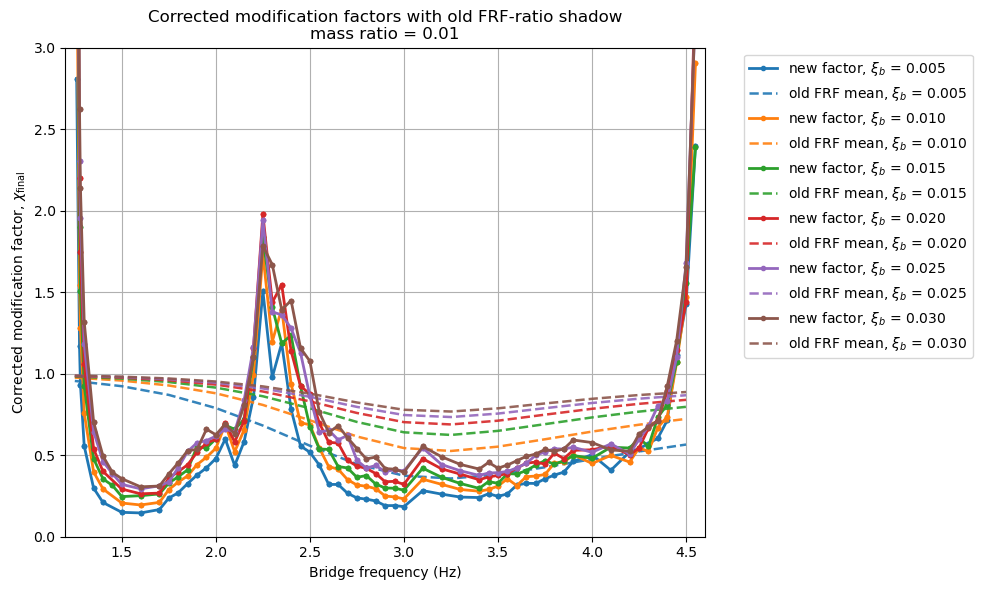

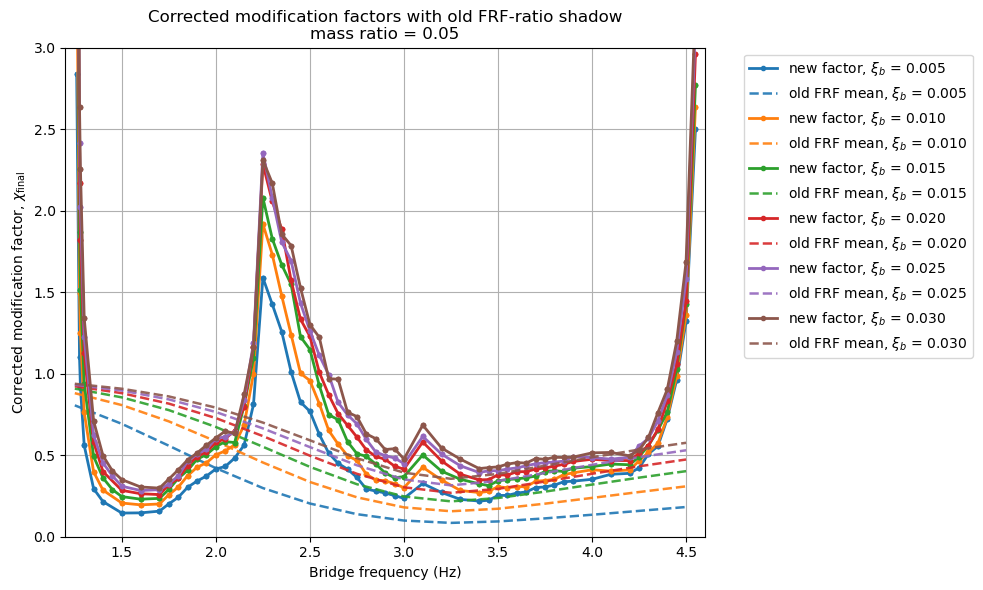

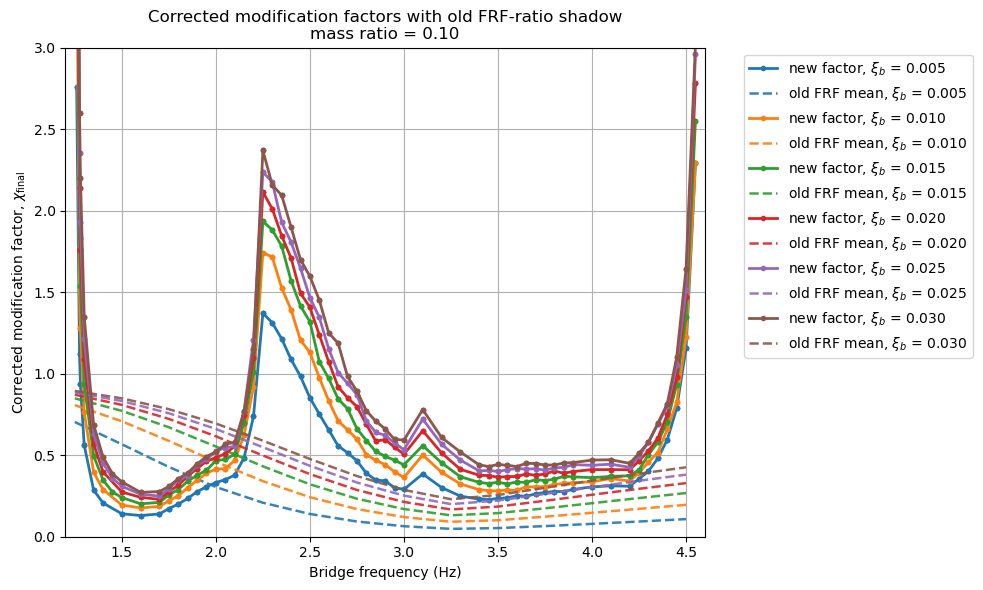

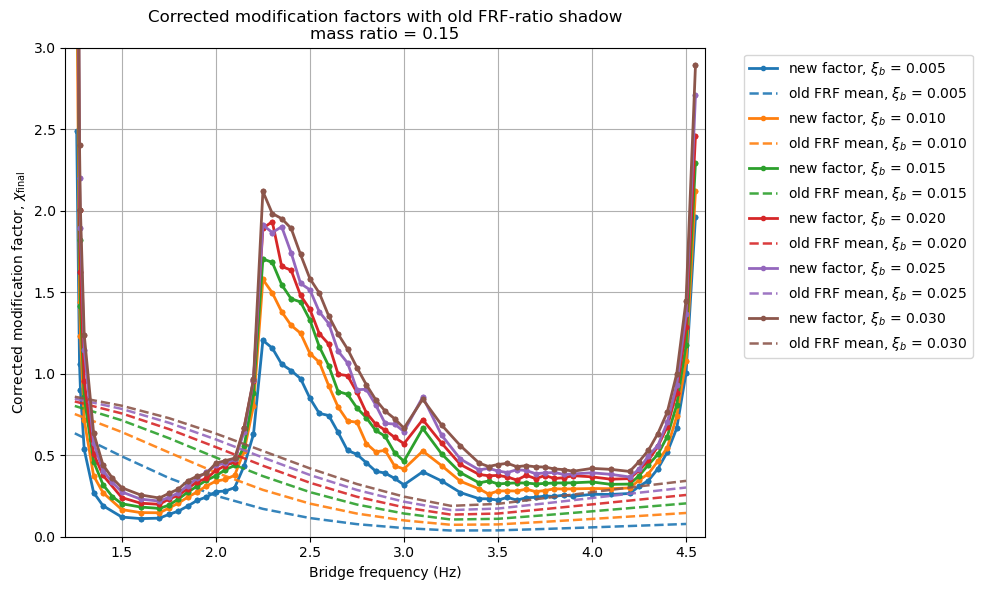

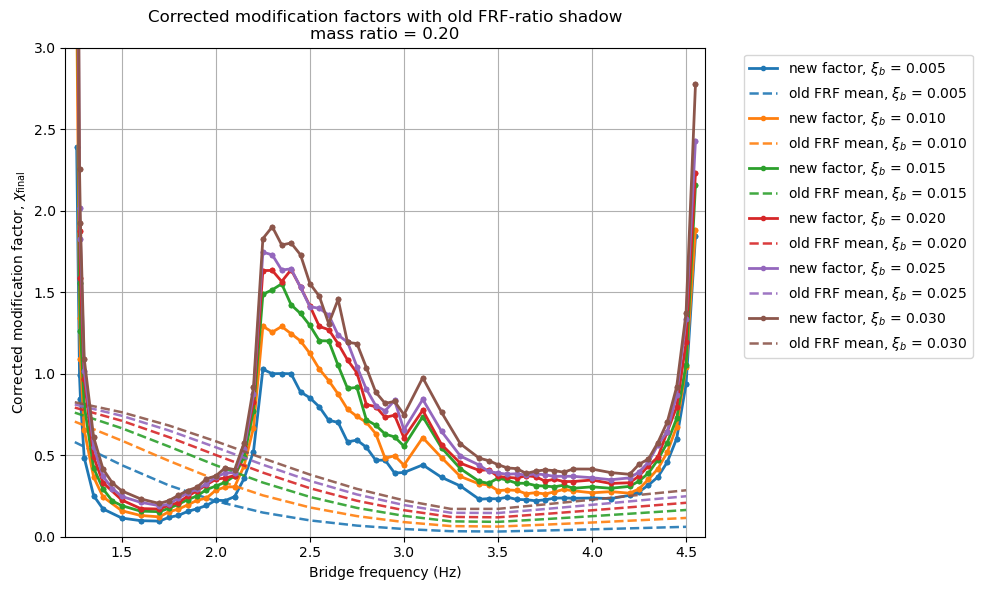

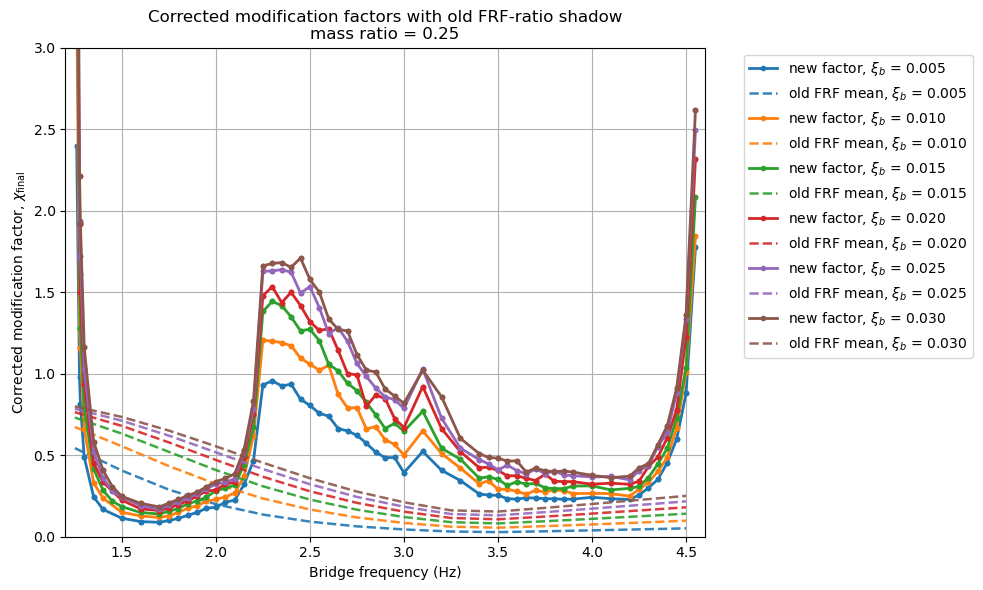

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loading: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading: density0.0333_damping0.005_0S_bias_summary.pkl
Loading: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading: density0.0333_damping0.010_0S_bias_summary.pkl
Loading: density0.0333_damping0.015_0S_bias_summary.pkl
Loading: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading: density0.0333_damping0.020_0S_bias_summary.pkl
Loading: density0.0333_damping0.025_0S_bias_summary.pkl
Loading: density0.0333_damping0.030_0S_bias_summary.pkl
Loading: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading: density0.1667_damping0.005_0S456_bias_summary.pkl
Loading: density0.1667_damping0.005_0S_bias_summary.pkl
Loading: density0.1667_damping0.010_0S125_bias_summary.pkl
Loading: density0.1667_damping0.010_0S456_bias_summary.pkl
Loading: density0.

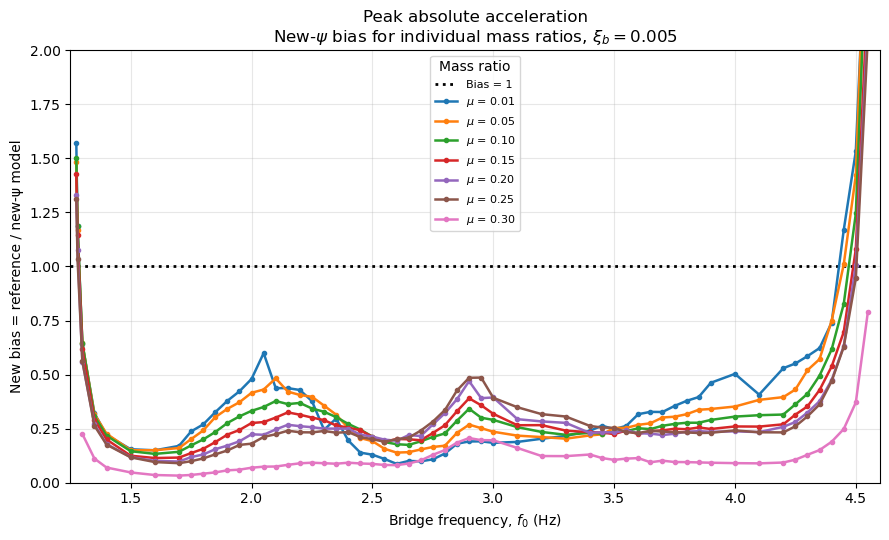

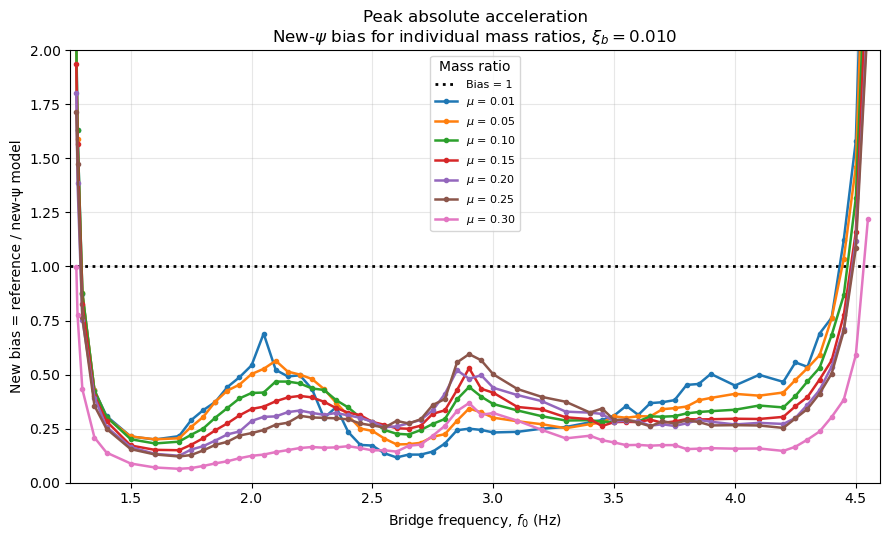

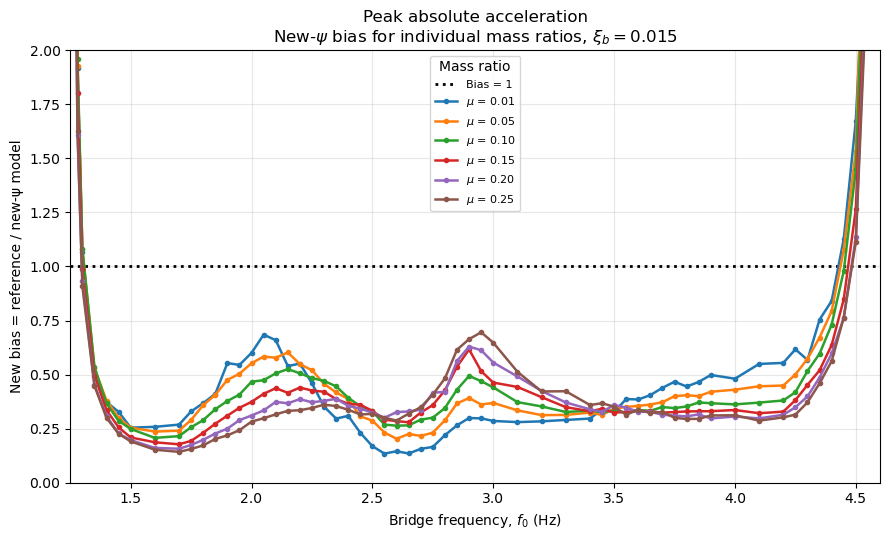

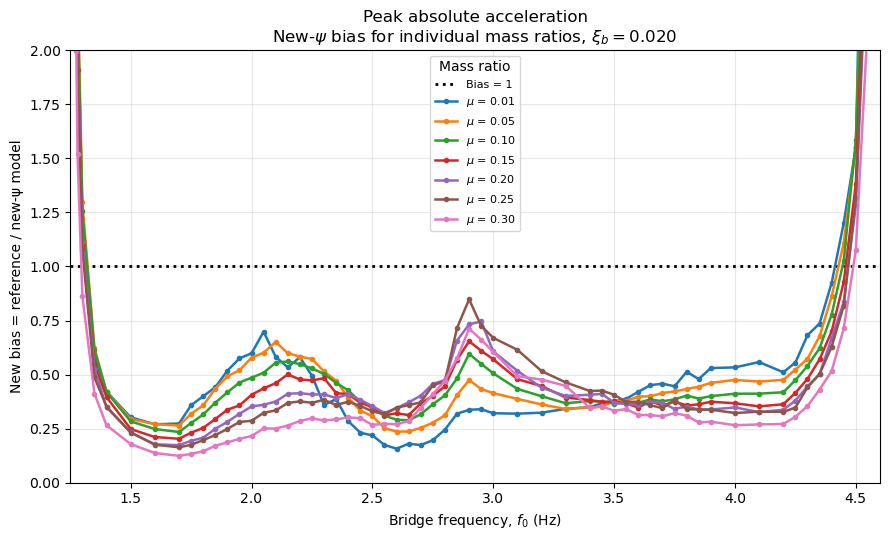

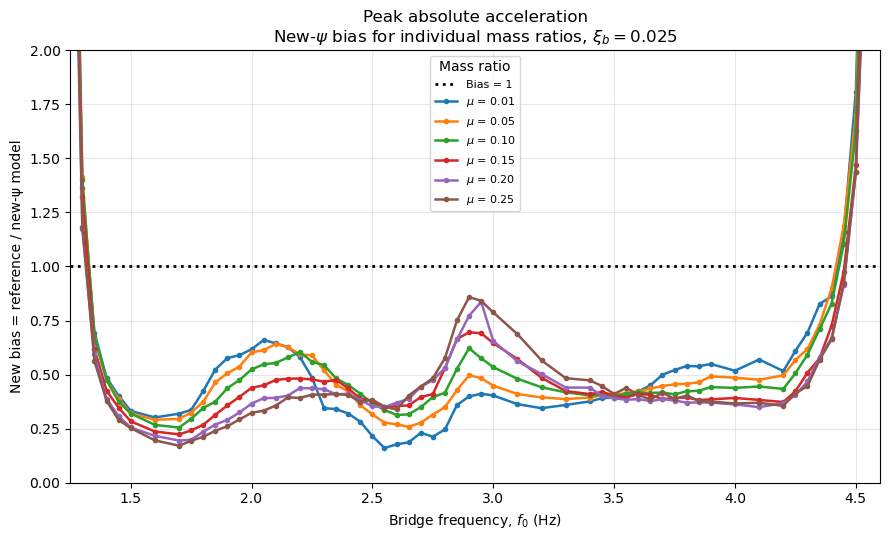

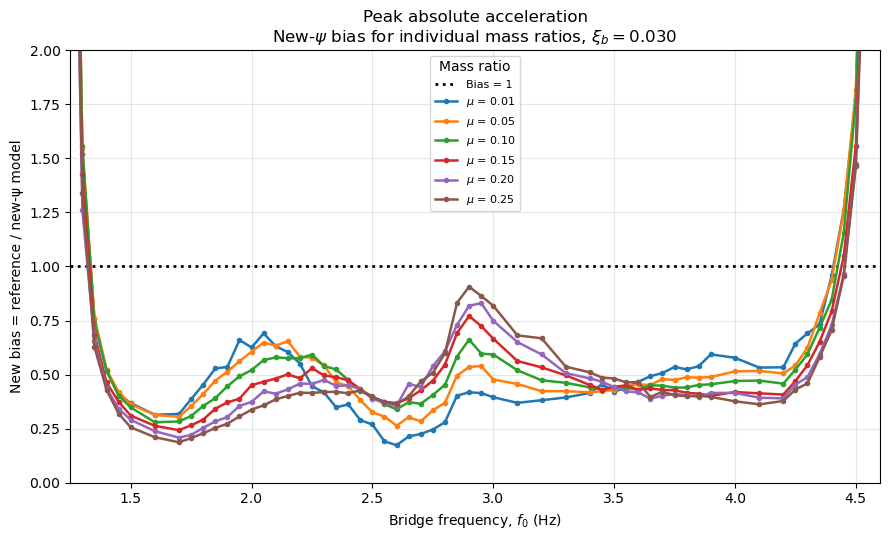

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

PLOT_FMIN = 1.25
PLOT_FMAX = 4.6

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SHOW_ORIGINAL_CODE_CURVES = True
SHOW_NEWPSI_CURVES = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    """
    Upper envelope of shifted psi.
    Piecewise equation from the shifted coupled-psi envelope.
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.258 <= f0 <= 1.709
    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    # 1.709 <= f0 <= 1.711
    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    # 1.711 <= f0 <= 2.566
    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    # 2.566 <= f0 <= 2.568
    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    # 2.568 <= f0 <= 2.872
    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    # 2.872 <= f0 <= 2.874
    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    # 2.874 <= f0 <= 4.191
    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    # 4.191 <= f0 <= 4.193
    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    # 4.193 <= f0 <= 4.593
    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    psi = np.clip(psi, 0.0, 1.0)

    return psi

# ==================================================
# LOAD ALL 0S, 0S125, 0S456 SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]

missing_columns = [c for c in required_columns if c not in corrected_df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.dropna(subset=required_columns).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

# ==================================================
# KEEP FREQUENCY REGIONS BASED ON FILE CONTENT
# ==================================================

# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# Older damping cases may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# Newer damping cases, e.g. 0.015, 0.025, 0.030,
# may have full frequency range stored as 0S.
#
# So:
#   - if only 0S exists for a density/damping pair, keep all 0S rows
#   - if regional files exist, stitch 0S125, 0S, and 0S456

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists, keep full frequency range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: regional files exist, stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    if g_keep.empty:
        print(
            f"Warning: no stitched rows for damping={damp_key}, "
            f"density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)

# Remove duplicate rows if same frequency appears multiple times
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "measure", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "measure", "bridge_frequency"],
    keep="first"
).copy()

# ==================================================
# FILTER TARGET DAMPINGS AND FREQUENCY RANGE
# ==================================================

df = corrected_df.copy()

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS and frequency range."
    )

# ==================================================
# CALCULATE OLD psi, NEW psi, AND NEW-psi BIAS
# ==================================================
# code_bias = reference / old_code_model
#
# old_code_model uses psi_old
# new_code_model uses psi_env
#
# new_code_model = old_code_model * psi_env / psi_old
#
# therefore:
#
# newpsi_bias = code_bias * psi_old / psi_env
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan
plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

for stat in ["mean", "p5", "p95"]:

    old_col = f"code_bias_{stat}"
    new_col = f"newpsi_bias_{stat}"
    hsi_col = f"hsi_factor_{stat}"

    plot_all_df[new_col] = (
        plot_all_df[old_col]
        * plot_all_df["psi_ratio_old_to_env"]
    )

    plot_all_df[new_col] = (
        plot_all_df[new_col]
        .replace([np.inf, -np.inf], np.nan)
    )

    # HSI factor needed after using the new psi model
    plot_all_df[hsi_col] = plot_all_df[new_col]

# ==================================================
# ADD MASS RATIO COLUMN
# ==================================================

plot_all_df["mass_ratio"] = plot_all_df["density_key"].map(
    lambda d: density_to_mass_ratio.get(round(float(d), 4), np.nan)
)

# ==================================================
# PRINT CHECK
# ==================================================

print("\nAvailable data after filtering:")
print(
    plot_all_df
    .groupby(["damping_key", "density_key", "measure"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

# ==================================================
# PLOT FUNCTION: ONE FIGURE PER DAMPING RATIO
# ONLY NEW-psi BIAS
# ==================================================

def plot_newpsi_bias_one_damping(measure_name, damp):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    sub_damp = measure_df[
        np.isclose(measure_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        print(f"No data for measure={measure_name}, damping={damp:.3f}")
        return

    plt.figure(figsize=(9, 5.5))

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label="Bias = 1",
    )

    # --------------------------------------------------
    # Plot only new-psi bias for each mass ratio
    # --------------------------------------------------

    for density in sorted(sub_damp["density_key"].dropna().unique()):

        sub = sub_damp[
            np.isclose(sub_damp["density_key"], density)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = rf"$\mu$ = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        plt.plot(
            sub["bridge_frequency"],
            sub["newpsi_bias_mean"],
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=label,
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel("New bias = reference / new-ψ model")

    plt.title(
        f"{measure_name}\n"
        rf"New-$\psi$ bias for individual mass ratios, $\xi_b = {damp:.3f}$"
    )

    plt.xlim(1.25, 4.6)
    plt.yscale("linear")
    plt.ylim(0, 2)

    plt.grid(True, which="both", alpha=0.30)

    plt.legend(
        loc="best",
        fontsize=8,
        title="Mass ratio",
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"newpsi_bias_{safe_measure}_"
            f"damping{damp:.3f}.png"
        )

        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()
# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    for damp in TARGET_DAMPINGS:
        plot_newpsi_bias_one_damping(measure_name, damp)


ORIGINAL vs ROUNDED CORRECTION

C_original range: 0.4157 to 0.8537
C_rounded range: 0.4250 to 0.8700

Maximum absolute difference in C: 0.019450
Maximum relative difference in C: 3.274%
Maximum absolute difference in resulting bias: 0.167258


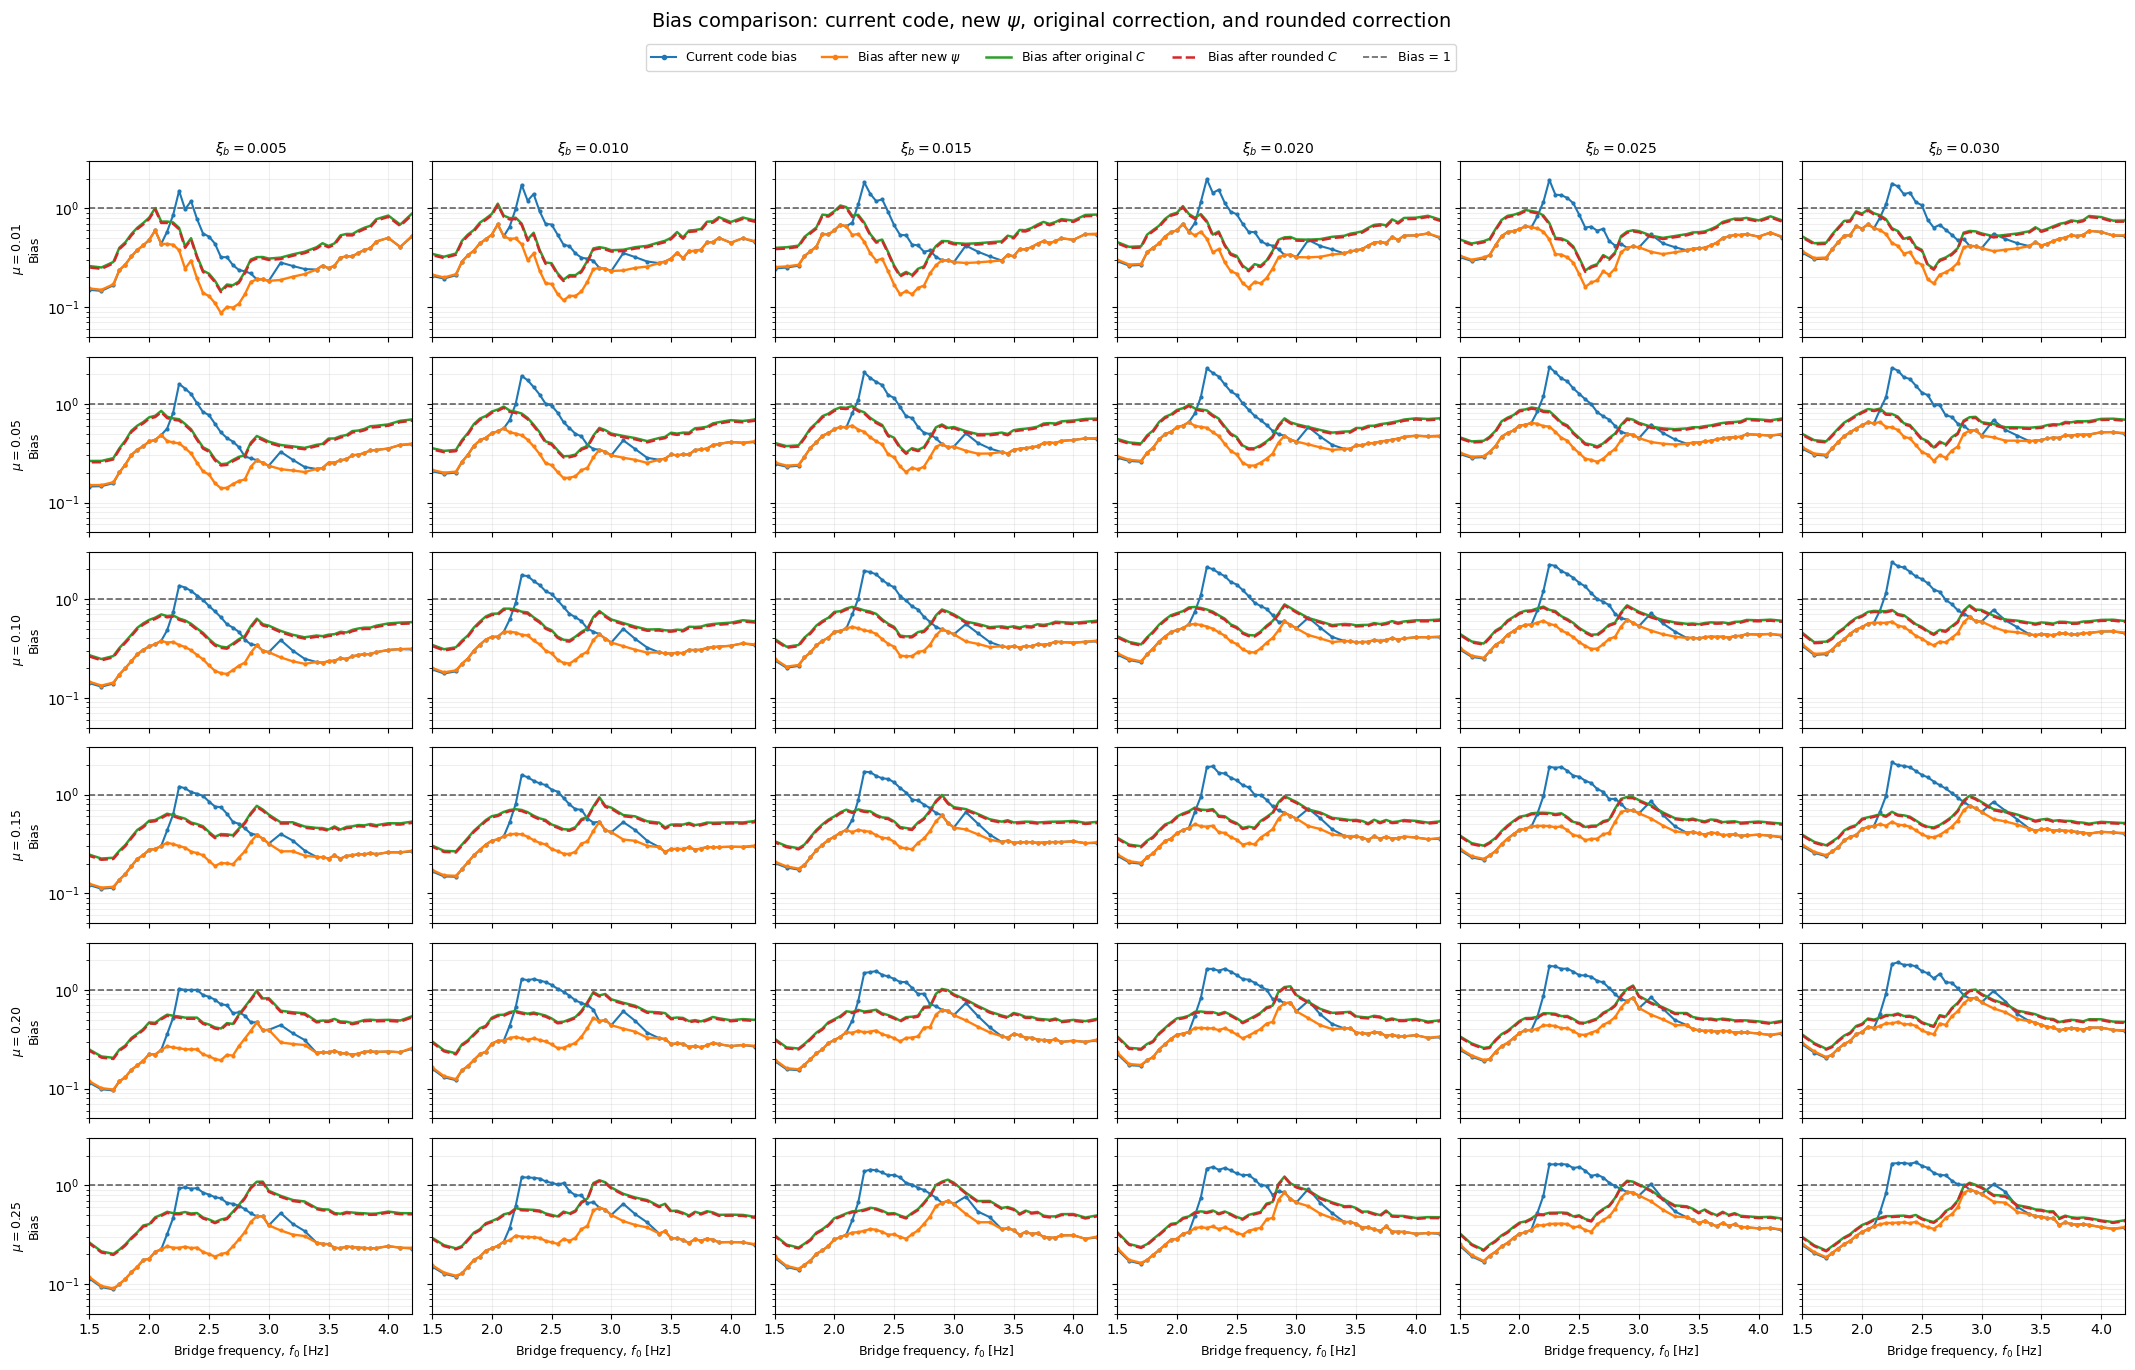

In [15]:
# ============================================================
# COMPARE:
#
# 1. ORIGINAL CODE BIAS
# 2. BIAS AFTER NEW psi
# 3. BIAS AFTER ORIGINAL C EQUATION
# 4. BIAS AFTER ROUNDED C EQUATION
#
# C_original =
#     0.58 + 4.04 xi_b - 0.86 mu + 49 mu xi_b
#
# C_rounded =
#     0.60 + 4.00 xi_b - 0.90 mu + 50 mu xi_b
#
# Since C multiplies the load-model prediction:
#
#     B_final = B_psi / C
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# 1. COPY CURRENT DATA
# ============================================================

comparison_df = plot_all_df.copy()


# ============================================================
# 2. CALCULATE ORIGINAL AND ROUNDED C
# ============================================================

mu = comparison_df["mass_ratio"].to_numpy(dtype=float)

xi = comparison_df["target_beamdamp"].to_numpy(dtype=float)


comparison_df["C_original"] = (
    0.58
    + 4.04 * xi
    - 0.86 * mu
    + 49.0 * mu * xi
)


comparison_df["C_rounded"] = (
    0.60
    + 4.00 * xi
    - 0.90 * mu
    + 50.0 * mu * xi
)


# ============================================================
# 3. APPLY C TO THE BIAS
#
# IMPORTANT:
#
# B_final = B_after_psi / C
# ============================================================

comparison_df["bias_original_C"] = np.where(
    comparison_df["C_original"] > 0,
    comparison_df["newpsi_bias_mean"]
    / comparison_df["C_original"],
    np.nan
)


comparison_df["bias_rounded_C"] = np.where(
    comparison_df["C_rounded"] > 0,
    comparison_df["newpsi_bias_mean"]
    / comparison_df["C_rounded"],
    np.nan
)


# ============================================================
# 4. SMALL NUMERICAL CHECK:
# DIFFERENCE BETWEEN ORIGINAL AND ROUNDED C
# ============================================================

comparison_df["C_difference"] = (
    comparison_df["C_rounded"]
    - comparison_df["C_original"]
)


comparison_df["C_relative_difference_pct"] = (
    100.0
    * comparison_df["C_difference"]
    / comparison_df["C_original"]
)


comparison_df["bias_difference"] = (
    comparison_df["bias_rounded_C"]
    - comparison_df["bias_original_C"]
)


print(
    "\n============================================================"
)

print(
    "ORIGINAL vs ROUNDED CORRECTION"
)

print(
    "============================================================"
)


print(
    "\nC_original range:"
    f" {comparison_df['C_original'].min():.4f}"
    f" to {comparison_df['C_original'].max():.4f}"
)


print(
    "C_rounded range:"
    f" {comparison_df['C_rounded'].min():.4f}"
    f" to {comparison_df['C_rounded'].max():.4f}"
)


print(
    "\nMaximum absolute difference in C:"
    f" {comparison_df['C_difference'].abs().max():.6f}"
)


print(
    "Maximum relative difference in C:"
    f" {comparison_df['C_relative_difference_pct'].abs().max():.3f}%"
)


print(
    "Maximum absolute difference in resulting bias:"
    f" {comparison_df['bias_difference'].abs().max():.6f}"
)


# ============================================================
# 5. SELECT PEAK ABSOLUTE ACCELERATION
# ============================================================

plot_df = comparison_df[
    comparison_df["measure"].astype(str).str.strip()
    ==
    "Peak absolute acceleration"
].copy()


# ============================================================
# 6. MASS RATIOS + DAMPING RATIOS TO PLOT
#
# This reproduces the style of your screenshot.
#
# If you want mu = 0.30 too, simply add 0.30.
# ============================================================

MASS_RATIOS_TO_PLOT = [
    0.01,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
]

DAMPINGS_TO_PLOT = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

# ============================================================
# PLOT COLOURS
# ============================================================

COLOR_CODE = "C0"
COLOR_NEW_PSI = "C1"
COLOR_ORIGINAL_C = "C2"
COLOR_ROUNDED_C = "C3"

# ============================================================
# 7. COMMON FIGURE
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)


fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# 8. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                damping
            )
        ].copy()

        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ----------------------------------------------------
        # Bias = 1
        # ----------------------------------------------------

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        if not sub.empty:

            # ------------------------------------------------
            # ORIGINAL CODE
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["code_bias_mean"],
                linewidth=1.5,
                marker="o",
                markersize=2.0,
                color=COLOR_CODE,
                label="Current code"
            )


            # ------------------------------------------------
            # NEW psi ONLY
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["newpsi_bias_mean"],
                linewidth=1.7,
                marker="o",
                markersize=2.0,
                color=COLOR_NEW_PSI,
                label=r"New $\psi$"
            )


            # ------------------------------------------------
            # NEW psi + ORIGINAL C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_original_C"],
                linewidth=1.8,
                color=COLOR_ORIGINAL_C,
                label=r"New $\psi$ + original $C$"
            )


            # ------------------------------------------------
            # NEW psi + ROUNDED C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_rounded_C"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ROUNDED_C,
                label=r"New $\psi$ + rounded $C$"
            )

        # ----------------------------------------------------
        # COLUMN TITLE = DAMPING
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
            rf"$\xi_b={damping:.3f}$",
                            fontsize=10
            )


        # ----------------------------------------------------
        # ROW LABEL = MASS RATIO
        # ----------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$"
                "\nBias",
                fontsize=9
            )


        # ----------------------------------------------------
        # X LABEL
        # ----------------------------------------------------

        if row == nrows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ [Hz]",
                fontsize=9
            )


        # ----------------------------------------------------
        # FORMAT
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_yscale(
            "log"
        )

        ax.set_ylim(
            0.05,
            3.0
        )

        ax.grid(
            True,
            which="both",
            alpha=0.20
        )


# ============================================================
# 9. COMMON TITLE
# ============================================================

fig.suptitle(
    "Bias comparison: current code, new $\\psi$, "
    "original correction, and rounded correction",
    fontsize=14,
    y=0.995
)


# ============================================================
# 10. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.5,
        marker="o",
        markersize=3,
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.7,
        marker="o",
        markersize=3,
        label=r"Bias after new $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ORIGINAL_C,
        linewidth=1.8,
        label=r"Bias after original $C$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ROUNDED_C,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after rounded $C$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=5,
    fontsize=9,
    frameon=True
)
plt.tight_layout(
    rect=[
        0.02,
        0.02,
        0.995,
        0.94
    ]
)

plt.show()


FILES FOUND

Damping file:
master_all_bridges_vertical_damping_frequency_span_material.csv

Mass-ratio p-box:
pbox_pymc_material_weighted_mass_ratio.csv

P95 (1,1) BIAS SURFACE

Rows = 1,500
f  = 1.500 to 4.400
xi = 0.0050 to 0.0300
mu = 0.050 to 0.250

Bias interpolator = RegularGridInterpolator
Grid size = 50 × 6 × 5

FREQUENCY POPULATION HIERARCHY

Total usable bridges = 250

STAGE 1 — NEED VSA
1.25 < f < 4.60
N = 160/250
P(VSA) = 0.640000 = 64.000%

STAGE 2 — HSI CORRECTION FREQUENCY RANGE
1.50 < f < 4.40
N = 145/160 VSA bridges
P(HSI frequency | VSA) = 0.906250 = 90.625%
P(HSI frequency) = 0.580000 = 58.000% of all bridges

Skipping Timber: no observed mass-ratio data.

MASS-RATIO POSTERIOR MODELS

                Material  n known mu  P(mu inside domain)
                   Steel           7             0.665943
                Concrete           5             0.715097
Steel-concrete composite           2             0.251480
                     FRP          10             0.000

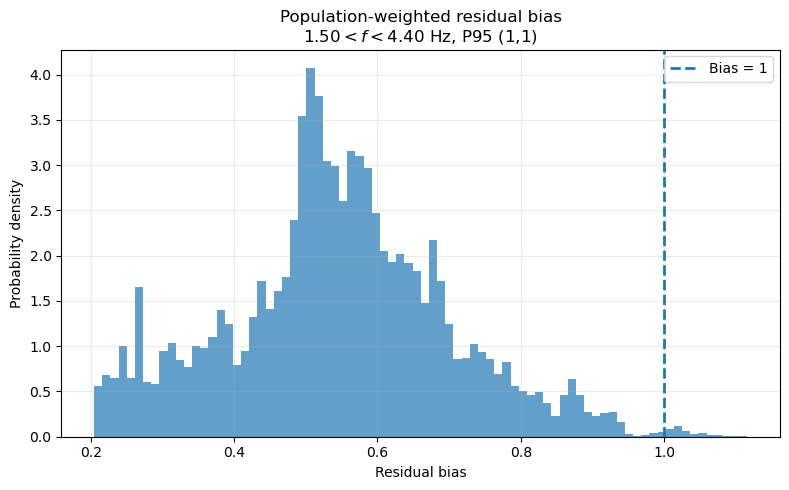

In [7]:
# ============================================================
# COMPLETE HIERARCHICAL POPULATION EXCEEDANCE CALCULATION
#
# P95 (1,1) idealisation
#
# Population hierarchy:
#
#   ALL BRIDGES
#       |
#       |  Stage 1
#       v
#   VSA bridges:
#       1.25 < f < 4.60 Hz
#       |
#       |  Stage 2
#       v
#   HSI-correction frequency range:
#       1.50 < f < 4.40 Hz
#       |
#       |  Stage 3
#       v
#   Valid HSI parameter domain:
#       0.005 <= xi_b <= 0.030
#       0.05  <= mu   <= 0.25
#       |
#       |  Stage 4
#       v
#   residual bias > 1 ?
#
#
# Main reported quantities:
#
#   P(VSA)
#
#   P(1.50<f<4.40 | VSA)
#
#   P(valid xi-mu domain | HSI-frequency)
#
#   P(Bias>1 | HSI-frequency, valid domain)
#
#   P(assessed Bias>1 | VSA)
#
# ============================================================


import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import (
    RegularGridInterpolator,
    LinearNDInterpolator
)


# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_SEED = 42
N_SAMPLES = 300_000

BIAS_THRESHOLD = 1.0

MEASURE_TO_USE = "Peak absolute acceleration"


# ------------------------------------------------------------
# Stage 1: VSA frequency range
# ------------------------------------------------------------

VSA_FMIN = 1.25
VSA_FMAX = 4.60


# ------------------------------------------------------------
# Stage 2: HSI/P95 correction frequency range
#
# This is the frequency range over which the P95 factor
# was calculated.
# ------------------------------------------------------------

HSI_FMIN = 1.50
HSI_FMAX = 4.40


# ------------------------------------------------------------
# P95 correction parameter domain used in this assessment
# ------------------------------------------------------------

XI_MODEL_MIN = 0.005
XI_MODEL_MAX = 0.030

MU_MODEL_MIN = 0.05
MU_MODEL_MAX = 0.25


# ------------------------------------------------------------
# psi numerical limit
# ------------------------------------------------------------

PSI_MIN = 0.02
EPS = 1e-12


# ============================================================
# 2. FINAL P95 (1,1) EQUATION
#
# C95(mu,xi_b) =
#
# 0.5774620601
# + 4.038492944 xi_b
# - 0.8624681443 mu
# + 49.0447593 mu xi_b
#
# ============================================================

C95_A0 = 0.5774620601
C95_A_XI = 4.038492944
C95_A_MU = -0.8624681443
C95_A_MUXI = 49.0447593


def C95_1_1(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (
        C95_A0
        +
        C95_A_XI * xi
        +
        C95_A_MU * mu
        +
        C95_A_MUXI * mu * xi
    )


# ============================================================
# 3. SAVED BAYESIAN FILES
# ============================================================

DAMPING_CSV = (
    "master_all_bridges_vertical_damping_frequency_span_material.csv"
)

MU_PBOX_CSV = (
    "pbox_pymc_material_weighted_mass_ratio.csv"
)


for filename in [
    DAMPING_CSV,
    MU_PBOX_CSV,
]:

    if not os.path.exists(filename):

        raise FileNotFoundError(
            f"\nCannot find:\n{filename}\n\n"
            f"Current folder:\n{os.getcwd()}"
        )


print(
    "\n============================================================"
)
print(
    "FILES FOUND"
)
print(
    "============================================================"
)

print(
    f"\nDamping file:\n{DAMPING_CSV}"
)

print(
    f"\nMass-ratio p-box:\n{MU_PBOX_CSV}"
)


# ============================================================
# 4. CHECK ORIGINAL BIAS DATA
# ============================================================

if "corrected_df" not in globals():

    raise NameError(
        "corrected_df does not exist.\n"
        "Run the original bias-data calculation first."
    )


# ============================================================
# 5. CLEANING FUNCTIONS
# ============================================================

def clean_numeric(series):

    s = series.astype(str)

    s = s.str.replace(
        "−",
        "-",
        regex=False
    )

    s = s.str.replace(
        "–",
        "-",
        regex=False
    )

    s = s.str.replace(
        "%",
        "",
        regex=False
    )

    s = s.str.replace(
        ",",
        "",
        regex=False
    )

    s = s.str.extract(
        r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    )[0]

    return pd.to_numeric(
        s,
        errors="coerce"
    )


def clean_damping(series):

    raw = series.astype(str)

    raw = raw.str.replace(
        "−",
        "-",
        regex=False
    )

    raw = raw.str.replace(
        "–",
        "-",
        regex=False
    )

    raw = raw.str.replace(
        "%",
        "",
        regex=False
    )

    output = []

    for value in raw:

        nums = re.findall(
            r"\d*\.?\d+(?:[eE][-+]?\d+)?",
            value
        )

        if len(nums) == 0:

            output.append(
                np.nan
            )

        elif (
            len(nums) >= 2
            and
            (
                "-" in value
                or
                "to" in value.lower()
            )
        ):

            output.append(
                np.mean([
                    float(nums[0]),
                    float(nums[1])
                ])
            )

        else:

            output.append(
                float(nums[0])
            )


    z = pd.Series(
        output,
        index=series.index,
        dtype=float
    )


    # Values such as 0.43 mean 0.43%
    percent_like = (
        z.notna()
        &
        (z > 0.20)
        &
        (z <= 20.0)
    )

    z.loc[
        percent_like
    ] /= 100.0


    impossible = (
        z.notna()
        &
        (
            (z <= 0.0)
            |
            (z > 0.20)
        )
    )

    z.loc[
        impossible
    ] = np.nan


    return z


# ============================================================
# 6. MATERIAL CLEANER
# ============================================================

MATERIAL_ORDER = [

    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]


def clean_material(x):

    s = str(x).strip().lower()

    if s in [
        "",
        "nan",
        "none",
        "-",
        "unknown",
        "other",
        "other types",
    ]:

        return "Other"


    if (
        "frp" in s
        or "gfrp" in s
        or "fiber" in s
        or "fibre" in s
        or "fiberglass" in s
        or "fibreglass" in s
        or "glass fibre" in s
        or "glass fiber" in s
    ):

        return "FRP"


    if (
        "timber" in s
        or "wood" in s
        or "wooden" in s
    ):

        return "Timber"


    if (
        ("steel" in s and "concrete" in s)
        or "steel-concrete" in s
        or "steel concrete" in s
        or "composite" in s
        or "mixed steel" in s
    ):

        return "Steel-concrete composite"


    if (
        "concrete" in s
        or "reinforced concrete" in s
        or s == "rc"
    ):

        return "Concrete"


    if (
        "steel" in s
        or "warren" in s
        or "bow-string" in s
        or "suspended" in s
    ):

        return "Steel"


    return "Other"


def safe_material_name(material):

    return (
        material
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


# ============================================================
# 7. REBUILD P95 (1,1) RESIDUAL BIAS
# ============================================================

bias_df = corrected_df.copy()


# ------------------------------------------------------------
# Create mass ratio if absent
# ------------------------------------------------------------

if "mass_ratio" not in bias_df.columns:

    if "target_density" not in bias_df.columns:

        raise KeyError(
            "corrected_df contains neither "
            "'mass_ratio' nor 'target_density'."
        )


    density_to_mass_ratio = {

        0.0333: 0.01,
        0.1667: 0.05,
        0.3333: 0.10,
        0.5000: 0.15,
        0.6667: 0.20,
        0.8333: 0.25,
        1.0000: 0.30,
    }


    density = pd.to_numeric(
        bias_df["target_density"],
        errors="coerce"
    ).round(4)


    bias_df[
        "mass_ratio"
    ] = density.map(
        density_to_mass_ratio
    )


# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_bias_columns = [

    "bridge_frequency",
    "target_beamdamp",
    "mass_ratio",
    "measure",
    "code_bias_mean",
]


missing = [

    c

    for c in required_bias_columns

    if c not in bias_df.columns
]


if missing:

    raise KeyError(
        f"Missing corrected_df columns: {missing}"
    )


# ------------------------------------------------------------
# Numeric conversion
# ------------------------------------------------------------

for column in [

    "bridge_frequency",
    "target_beamdamp",
    "mass_ratio",
    "code_bias_mean",
]:

    bias_df[column] = pd.to_numeric(
        bias_df[column],
        errors="coerce"
    )


bias_df["measure"] = (
    bias_df["measure"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Peak acceleration only
# ------------------------------------------------------------

bias_df = bias_df[

    bias_df["measure"]
    ==
    MEASURE_TO_USE

].copy()


# ------------------------------------------------------------
# P95 frequency domain
# ------------------------------------------------------------

bias_df = bias_df[

    (bias_df["bridge_frequency"] >= HSI_FMIN)

    &

    (bias_df["bridge_frequency"] <= HSI_FMAX)

].copy()


# ------------------------------------------------------------
# P95 xi-mu domain
# ------------------------------------------------------------

bias_df = bias_df[

    (bias_df["target_beamdamp"] >= XI_MODEL_MIN)

    &

    (bias_df["target_beamdamp"] <= XI_MODEL_MAX)

    &

    (bias_df["mass_ratio"] >= MU_MODEL_MIN)

    &

    (bias_df["mass_ratio"] <= MU_MODEL_MAX)

].copy()


bias_df = bias_df.dropna(

    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "mass_ratio",
        "code_bias_mean",
    ]

).copy()


# ============================================================
# 8. CALCULATE psi-CORRECTED BIAS
# ============================================================

# ------------------------------------------------------------
# Prefer a previously calculated psi-corrected column
# if corrected_df already contains it.
# ------------------------------------------------------------

if "newpsi_code_bias_mean" in bias_df.columns:

    bias_df["bias_after_psi"] = pd.to_numeric(
        bias_df["newpsi_code_bias_mean"],
        errors="coerce"
    )


elif "bias_after_psi" in bias_df.columns:

    bias_df["bias_after_psi"] = pd.to_numeric(
        bias_df["bias_after_psi"],
        errors="coerce"
    )


else:

    # Need the two psi functions
    if "psi_w_h1_old" not in globals():

        raise NameError(
            "psi_w_h1_old is missing."
        )


    if "psi_env_new" not in globals():

        raise NameError(
            "psi_env_new is missing."
        )


    f_bias = bias_df[
        "bridge_frequency"
    ].to_numpy(
        dtype=float
    )


    bias_df[
        "psi_old"
    ] = psi_w_h1_old(
        f_bias
    )


    bias_df[
        "psi_env"
    ] = psi_env_new(
        f_bias
    )


    valid_psi = (

        np.isfinite(
            bias_df["code_bias_mean"]
        )

        &

        np.isfinite(
            bias_df["psi_old"]
        )

        &

        np.isfinite(
            bias_df["psi_env"]
        )

        &

        (
            bias_df["psi_old"]
            >=
            PSI_MIN
        )

        &

        (
            bias_df["psi_env"]
            >=
            PSI_MIN
        )
    )


    bias_df[
        "bias_after_psi"
    ] = np.nan


    bias_df.loc[
        valid_psi,
        "bias_after_psi"
    ] = (

        bias_df.loc[
            valid_psi,
            "code_bias_mean"
        ]

        *

        bias_df.loc[
            valid_psi,
            "psi_old"
        ]

        /

        bias_df.loc[
            valid_psi,
            "psi_env"
        ]
    )


# ============================================================
# 9. APPLY P95 (1,1) FACTOR
# ============================================================

bias_df[
    "C95_1_1"
] = C95_1_1(

    bias_df[
        "mass_ratio"
    ].to_numpy(dtype=float),

    bias_df[
        "target_beamdamp"
    ].to_numpy(dtype=float)
)


bias_df[
    "bias_after_C95_1_1"
] = (

    bias_df[
        "bias_after_psi"
    ]

    /

    bias_df[
        "C95_1_1"
    ]
)


bias_df = (

    bias_df

    .drop_duplicates(

        subset=[
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ],

        keep="first"
    )

    .sort_values([
        "bridge_frequency",
        "target_beamdamp",
        "mass_ratio",
    ])

    .reset_index(
        drop=True
    )
)


print(
    "\n============================================================"
)
print(
    "P95 (1,1) BIAS SURFACE"
)
print(
    "============================================================"
)

print(
    f"\nRows = {len(bias_df):,}"
)

print(
    f"f  = "
    f"{bias_df['bridge_frequency'].min():.3f} "
    f"to "
    f"{bias_df['bridge_frequency'].max():.3f}"
)

print(
    f"xi = "
    f"{bias_df['target_beamdamp'].min():.4f} "
    f"to "
    f"{bias_df['target_beamdamp'].max():.4f}"
)

print(
    f"mu = "
    f"{bias_df['mass_ratio'].min():.3f} "
    f"to "
    f"{bias_df['mass_ratio'].max():.3f}"
)


# ============================================================
# 10. BUILD 3-D BIAS INTERPOLATOR
#
# f × xi × mu
# ============================================================

f_grid = np.sort(
    bias_df[
        "bridge_frequency"
    ].unique()
)

xi_grid = np.sort(
    bias_df[
        "target_beamdamp"
    ].unique()
)

mu_grid = np.sort(
    bias_df[
        "mass_ratio"
    ].unique()
)


full_index = pd.MultiIndex.from_product(

    [
        f_grid,
        xi_grid,
        mu_grid
    ],

    names=[
        "bridge_frequency",
        "target_beamdamp",
        "mass_ratio"
    ]
)


grid_series = (

    bias_df

    .groupby([
        "bridge_frequency",
        "target_beamdamp",
        "mass_ratio"
    ])[
        "bias_after_C95_1_1"
    ]

    .mean()

    .reindex(
        full_index
    )
)


# ------------------------------------------------------------
# Regular grid if complete
# ------------------------------------------------------------

if not grid_series.isna().any():

    bias_cube = (

        grid_series
        .to_numpy()

        .reshape(
            len(f_grid),
            len(xi_grid),
            len(mu_grid)
        )
    )


    regular_interpolator = RegularGridInterpolator(

        (
            f_grid,
            xi_grid,
            mu_grid
        ),

        bias_cube,

        method="linear",

        bounds_error=False,

        fill_value=np.nan
    )


    def evaluate_bias(points):

        return regular_interpolator(
            points
        )


    INTERPOLATOR_TYPE = "RegularGridInterpolator"


# ------------------------------------------------------------
# Fallback if a few grid combinations are missing
# ------------------------------------------------------------

else:

    scattered_points = bias_df[
        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ]
    ].to_numpy(
        dtype=float
    )


    scattered_values = bias_df[
        "bias_after_C95_1_1"
    ].to_numpy(
        dtype=float
    )


    scattered_interpolator = LinearNDInterpolator(

        scattered_points,

        scattered_values,

        fill_value=np.nan
    )


    def evaluate_bias(points):

        return np.asarray(
            scattered_interpolator(
                points
            )
        )


    INTERPOLATOR_TYPE = "LinearNDInterpolator"


print(
    f"\nBias interpolator = "
    f"{INTERPOLATOR_TYPE}"
)

print(
    f"Grid size = "
    f"{len(f_grid)} × "
    f"{len(xi_grid)} × "
    f"{len(mu_grid)}"
)


# ============================================================
# 11. LOAD COMPLETE BRIDGE POPULATION
# ============================================================

population_df = pd.read_csv(

    DAMPING_CSV,

    encoding="utf-8-sig"
)


population_df = (

    population_df
    .dropna(how="all")
    .copy()
)


# ============================================================
# 12. FREQUENCY COLUMN
# ============================================================

if "first_vertical_frequency_Hz" in population_df.columns:

    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "first_vertical_frequency_Hz"
        ]
    )


elif "vertical_natural_frequency_Hz" in population_df.columns:

    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "vertical_natural_frequency_Hz"
        ]
    )


else:

    raise KeyError(
        "No vertical-frequency column found."
    )


# ============================================================
# 13. MATERIAL COLUMN
# ============================================================

if "material_used" in population_df.columns:

    material_column = "material_used"


elif "girder_material" in population_df.columns:

    material_column = "girder_material"


elif "material_group" in population_df.columns:

    material_column = "material_group"


else:

    raise KeyError(
        "No material column found."
    )


population_df[
    "material"
] = (

    population_df[
        material_column
    ]

    .apply(
        clean_material
    )
)


# ============================================================
# 14. DAMPING COLUMNS
# ============================================================

if "vertical_damping_ratio" in population_df.columns:

    population_df[
        "observed_damping"
    ] = clean_damping(

        population_df[
            "vertical_damping_ratio"
        ]
    )


else:

    population_df[
        "observed_damping"
    ] = np.nan


# ------------------------------------------------------------
# Observed/imputed indicator
# ------------------------------------------------------------

if "damping_observed" in population_df.columns:

    flag = (

        population_df[
            "damping_observed"
        ]

        .astype(str)

        .str.strip()

        .str.lower()
    )


    population_df[
        "damping_observed_flag"
    ] = flag.isin(
        [
            "true",
            "1",
            "yes"
        ]
    )


else:

    population_df[
        "damping_observed_flag"
    ] = (

        population_df[
            "observed_damping"
        ]

        .notna()
    )


# ------------------------------------------------------------
# Imputed posterior mean
# ------------------------------------------------------------

if "zeta_imputed_mean" in population_df.columns:

    population_df[
        "imputed_mean"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_mean"
        ]
    )


else:

    population_df[
        "imputed_mean"
    ] = np.nan


# ------------------------------------------------------------
# Imputed posterior SD
# ------------------------------------------------------------

if "zeta_imputed_sd" in population_df.columns:

    population_df[
        "imputed_sd"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_sd"
        ]
    )


else:

    population_df[
        "imputed_sd"
    ] = np.nan


# ------------------------------------------------------------
# Fallback completed mean
# ------------------------------------------------------------

if "zeta_completed_mean" in population_df.columns:

    completed_mean = clean_numeric(

        population_df[
            "zeta_completed_mean"
        ]
    )


    missing = (

        population_df[
            "imputed_mean"
        ].isna()
    )


    population_df.loc[
        missing,
        "imputed_mean"
    ] = completed_mean.loc[
        missing
    ]


# ============================================================
# 15. KEEP ALL BRIDGES WITH USABLE FREQUENCY
#
# This is the denominator for Stage 1.
# ============================================================

population_df = population_df[

    np.isfinite(
        population_df[
            "frequency"
        ]
    )

].copy()


population_df = population_df.reset_index(
    drop=True
)


N_ALL = len(
    population_df
)


# ============================================================
# 16. STAGE 1 — FRACTION NEEDING VSA
#
# ONLY FREQUENCY IS USED HERE.
#
#     1.25 < f < 4.60
# ============================================================

vsa_mask = (

    (
        population_df[
            "frequency"
        ]
        >
        VSA_FMIN
    )

    &

    (
        population_df[
            "frequency"
        ]
        <
        VSA_FMAX
    )
)


vsa_df = (

    population_df[
        vsa_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_VSA = len(
    vsa_df
)


P_VSA = (

    N_VSA
    /
    N_ALL
)


# ============================================================
# 17. STAGE 2 — HSI CORRECTION FREQUENCY RANGE
#
# Of bridges requiring VSA:
#
#     1.50 < f < 4.40
# ============================================================

hsi_mask = (

    (
        vsa_df[
            "frequency"
        ]
        >
        HSI_FMIN
    )

    &

    (
        vsa_df[
            "frequency"
        ]
        <
        HSI_FMAX
    )
)


hsi_df = (

    vsa_df[
        hsi_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_HSI = len(
    hsi_df
)


P_HSI_GIVEN_VSA = (

    N_HSI
    /
    N_VSA
)


P_HSI_ALL = (

    N_HSI
    /
    N_ALL
)


print(
    "\n============================================================"
)
print(
    "FREQUENCY POPULATION HIERARCHY"
)
print(
    "============================================================"
)


print(
    f"\nTotal usable bridges = "
    f"{N_ALL}"
)


print(
    "\nSTAGE 1 — NEED VSA"
)

print(
    f"{VSA_FMIN:.2f} < f < {VSA_FMAX:.2f}"
)

print(
    f"N = {N_VSA}/{N_ALL}"
)

print(
    f"P(VSA) = "
    f"{P_VSA:.6f} "
    f"= {100*P_VSA:.3f}%"
)


print(
    "\nSTAGE 2 — HSI CORRECTION FREQUENCY RANGE"
)

print(
    f"{HSI_FMIN:.2f} < f < {HSI_FMAX:.2f}"
)

print(
    f"N = {N_HSI}/{N_VSA} VSA bridges"
)

print(
    f"P(HSI frequency | VSA) = "
    f"{P_HSI_GIVEN_VSA:.6f} "
    f"= {100*P_HSI_GIVEN_VSA:.3f}%"
)

print(
    f"P(HSI frequency) = "
    f"{P_HSI_ALL:.6f} "
    f"= {100*P_HSI_ALL:.3f}% "
    f"of all bridges"
)


# ============================================================
# 18. LOAD BAYESIAN MASS-RATIO P-BOX
# ============================================================

mu_pbox_df = pd.read_csv(

    MU_PBOX_CSV,

    encoding="utf-8-sig"
)


mu_pbox_df[
    "T"
] = pd.to_numeric(

    mu_pbox_df[
        "T"
    ],

    errors="coerce"
)


mu_pbox_df = (

    mu_pbox_df

    .dropna(
        subset=[
            "T"
        ]
    )

    .sort_values(
        "T"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 19. BUILD MATERIAL-SPECIFIC MASS-RATIO MODELS
#
# IMPORTANT:
#
# We use:
#
# theta_m(T) = P(mu < T | material m)
#
# directly from the saved Bayesian p-box.
#
# Materials with n_known = 0 are NOT given an artificial
# mass-ratio distribution.
# ============================================================

mu_models = {}

mu_model_summary = []


for material in MATERIAL_ORDER:

    safe = safe_material_name(
        material
    )


    theta_col = (
        f"{safe}_theta_mean"
    )


    n_known_col = (
        f"{safe}_n_known"
    )


    # --------------------------------------------------------
    # Need both posterior CDF and known-sample count
    # --------------------------------------------------------

    if theta_col not in mu_pbox_df.columns:

        continue


    if n_known_col not in mu_pbox_df.columns:

        print(
            f"\nSkipping {material}: "
            f"{n_known_col} missing."
        )

        continue


    n_known_values = pd.to_numeric(

        mu_pbox_df[
            n_known_col
        ],

        errors="coerce"
    ).dropna()


    if len(n_known_values) == 0:

        continue


    n_known = int(
        round(
            n_known_values.iloc[0]
        )
    )


    # --------------------------------------------------------
    # Critical:
    #
    # no observed mu data -> posterior is prior-only.
    #
    # Do not interpret tiny independent-threshold MCMC
    # fluctuations as a physical CDF.
    # --------------------------------------------------------

    if n_known <= 0:

        print(
            f"\nSkipping {material}: "
            "no observed mass-ratio data."
        )

        continue


    T_saved = pd.to_numeric(

        mu_pbox_df[
            "T"
        ],

        errors="coerce"
    ).to_numpy(
        dtype=float
    )


    F_saved = pd.to_numeric(

        mu_pbox_df[
            theta_col
        ],

        errors="coerce"
    ).to_numpy(
        dtype=float
    )


    valid = (

        np.isfinite(
            T_saved
        )

        &

        np.isfinite(
            F_saved
        )
    )


    T_saved = T_saved[
        valid
    ]

    F_saved = F_saved[
        valid
    ]


    order = np.argsort(
        T_saved
    )


    T_saved = T_saved[
        order
    ]

    F_saved = F_saved[
        order
    ]


    # enforce valid CDF ordering
    F_saved = np.maximum.accumulate(
        F_saved
    )


    F_saved = np.clip(
        F_saved,
        0.0,
        1.0
    )


    # --------------------------------------------------------
    # Probability that mu lies inside correction domain
    #
    # P(mu_min <= mu <= mu_max)
    #
    # = F(mu_max) - F(mu_min)
    # --------------------------------------------------------

    F_mu_min = float(
        np.interp(
            MU_MODEL_MIN,
            T_saved,
            F_saved
        )
    )


    F_mu_max = float(
        np.interp(
            MU_MODEL_MAX,
            T_saved,
            F_saved
        )
    )


    P_mu_inside = max(
        0.0,
        F_mu_max
        -
        F_mu_min
    )


    if P_mu_inside <= EPS:

        print(
            f"\nSkipping {material}: "
            "zero posterior probability in "
            "the HSI mass-ratio domain."
        )

        continue


    # --------------------------------------------------------
    # Construct conditional CDF bins INSIDE
    #
    #     MU_MODEL_MIN <= mu <= MU_MODEL_MAX
    #
    # This is used only after the Bernoulli draw establishes
    # that the sampled bridge lies in the mu domain.
    # --------------------------------------------------------

    internal_T = T_saved[

        (T_saved > MU_MODEL_MIN)

        &

        (T_saved < MU_MODEL_MAX)
    ]


    mu_edges = np.unique(

        np.concatenate([

            [MU_MODEL_MIN],

            internal_T,

            [MU_MODEL_MAX]
        ])
    )


    F_edges = np.interp(

        mu_edges,

        T_saved,

        F_saved
    )


    F_edges = np.maximum.accumulate(
        F_edges
    )


    bin_probability = np.diff(
        F_edges
    )


    bin_probability = np.maximum(
        bin_probability,
        0.0
    )


    if np.sum(
        bin_probability
    ) <= EPS:

        continue


    conditional_weights = (

        bin_probability

        /

        np.sum(
            bin_probability
        )
    )


    mu_models[
        material
    ] = {

        "n_known":
            n_known,

        "P_inside":
            P_mu_inside,

        "edges":
            mu_edges,

        "weights":
            conditional_weights,
    }


    mu_model_summary.append({

        "Material":
            material,

        "n known mu":
            n_known,

        "P(mu inside domain)":
            P_mu_inside,
    })


mu_model_summary_df = pd.DataFrame(
    mu_model_summary
)


print(
    "\n============================================================"
)
print(
    "MASS-RATIO POSTERIOR MODELS"
)
print(
    "============================================================\n"
)


print(

    mu_model_summary_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


print(
    "\nSupported materials:"
)

print(
    list(
        mu_models.keys()
    )
)


# ============================================================
# 20. DAMPING SAMPLER
#
# For missing damping:
#
# reconstruct a positive lognormal distribution from the
# saved Bayesian posterior mean and SD.
# ============================================================

def sample_lognormal_from_mean_sd(
    mean,
    sd,
    rng
):

    mean = np.asarray(
        mean,
        dtype=float
    )


    sd = np.asarray(
        sd,
        dtype=float
    )


    output = np.full(

        len(mean),

        np.nan,

        dtype=float
    )


    deterministic = (

        np.isfinite(
            mean
        )

        &

        (mean > 0)

        &

        (
            ~np.isfinite(
                sd
            )

            |

            (sd <= 0)
        )
    )


    output[
        deterministic
    ] = mean[
        deterministic
    ]


    stochastic = (

        np.isfinite(
            mean
        )

        &

        (mean > 0)

        &

        np.isfinite(
            sd
        )

        &

        (sd > 0)
    )


    if np.any(
        stochastic
    ):

        m = mean[
            stochastic
        ]

        s = sd[
            stochastic
        ]


        sigma2_log = np.log(

            1.0

            +

            (s / m)**2
        )


        sigma_log = np.sqrt(
            sigma2_log
        )


        mu_log = (

            np.log(
                m
            )

            -

            0.5
            *
            sigma2_log
        )


        output[
            stochastic
        ] = rng.lognormal(

            mean=
                mu_log,

            sigma=
                sigma_log
        )


    return output


# ============================================================
# 21. MONTE CARLO
#
# IMPORTANT:
#
# We now sample from the HSI-frequency population only:
#
#     1.50 < f < 4.40
#
# P(HSI | VSA) was calculated separately above.
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


sample_indices = rng.choice(

    hsi_df.index.to_numpy(),

    size=N_SAMPLES,

    replace=True
)


sample_df = (

    hsi_df.loc[
        sample_indices
    ]

    .reset_index(
        drop=True
    )
)


f_samples = sample_df[
    "frequency"
].to_numpy(
    dtype=float
)


material_samples = sample_df[
    "material"
].to_numpy()


# ============================================================
# 22. SAMPLE DAMPING
# ============================================================

observed_flag = sample_df[
    "damping_observed_flag"
].to_numpy(
    dtype=bool
)


observed_xi = sample_df[
    "observed_damping"
].to_numpy(
    dtype=float
)


imputed_mean = sample_df[
    "imputed_mean"
].to_numpy(
    dtype=float
)


imputed_sd = sample_df[
    "imputed_sd"
].to_numpy(
    dtype=float
)


xi_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


use_observed = (

    observed_flag

    &

    np.isfinite(
        observed_xi
    )
)


xi_samples[
    use_observed
] = observed_xi[
    use_observed
]


use_imputed = (
    ~use_observed
)


xi_samples[
    use_imputed
] = sample_lognormal_from_mean_sd(

    mean=
        imputed_mean[
            use_imputed
        ],

    sd=
        imputed_sd[
            use_imputed
        ],

    rng=rng
)


# ============================================================
# 23. SAMPLE MASS-RATIO DOMAIN OCCURRENCE
#
# First:
#
#   Does the bridge lie in 0.05 <= mu <= 0.25 ?
#
# according to its material-specific Bayesian CDF.
#
# Only if YES do we sample a mu value inside that range.
# ============================================================

material_mu_supported = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_inside = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


for material in np.unique(
    material_samples
):

    indices = np.flatnonzero(

        material_samples
        ==
        material
    )


    if material not in mu_models:

        continue


    material_mu_supported[
        indices
    ] = True


    model = mu_models[
        material
    ]


    # --------------------------------------------------------
    # Bernoulli:
    #
    # Is mass ratio inside the HSI correction domain?
    # --------------------------------------------------------

    inside_local = (

        rng.random(
            len(indices)
        )

        <

        model[
            "P_inside"
        ]
    )


    inside_indices = indices[
        inside_local
    ]


    mu_inside[
        inside_indices
    ] = True


    if len(
        inside_indices
    ) == 0:

        continue


    # --------------------------------------------------------
    # Conditional mu value, given that it lies in domain
    # --------------------------------------------------------

    weights = model[
        "weights"
    ]


    edges = model[
        "edges"
    ]


    bin_index = rng.choice(

        np.arange(
            len(weights)
        ),

        size=
            len(
                inside_indices
            ),

        replace=True,

        p=
            weights
    )


    lower = edges[
        bin_index
    ]

    upper = edges[
        bin_index + 1
    ]


    mu_samples[
        inside_indices
    ] = rng.uniform(

        low=lower,

        high=upper
    )


# ============================================================
# 24. DAMPING-DOMAIN OCCURRENCE
# ============================================================

xi_inside = (

    np.isfinite(
        xi_samples
    )

    &

    (
        xi_samples
        >=
        XI_MODEL_MIN
    )

    &

    (
        xi_samples
        <=
        XI_MODEL_MAX
    )
)


# ============================================================
# 25. COMPLETE HSI PARAMETER DOMAIN
# ============================================================

complete_domain = (

    material_mu_supported

    &

    mu_inside

    &

    xi_inside

    &

    np.isfinite(
        mu_samples
    )
)


# ============================================================
# 26. EVALUATE RESIDUAL BIAS
# ============================================================

sampled_bias = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


points = np.column_stack([

    f_samples[
        complete_domain
    ],

    xi_samples[
        complete_domain
    ],

    mu_samples[
        complete_domain
    ],
])


sampled_bias[
    complete_domain
] = evaluate_bias(
    points
)


valid_bias = (

    complete_domain

    &

    np.isfinite(
        sampled_bias
    )
)


# ============================================================
# 27. EXCEEDANCE EVENT
#
# Bias > 1 = underprediction
# ============================================================

exceedance = (

    valid_bias

    &

    (
        sampled_bias
        >
        BIAS_THRESHOLD
    )
)


N_VALID = int(
    np.sum(
        valid_bias
    )
)


N_EXCEED = int(
    np.sum(
        exceedance
    )
)


if N_VALID == 0:

    raise ValueError(
        "No Monte Carlo samples lie inside "
        "the complete HSI model domain."
    )


# ============================================================
# 28. STAGE 3 PROBABILITIES
# ============================================================

P_MATERIAL_SUPPORTED_GIVEN_HSI = np.mean(

    material_mu_supported
)


P_MU_INSIDE_GIVEN_HSI = np.mean(

    mu_inside
)


P_XI_INSIDE_GIVEN_HSI = np.mean(

    xi_inside
)


P_DOMAIN_GIVEN_HSI = np.mean(

    valid_bias
)


# ============================================================
# 29. STAGE 4
#
# Probability of exceedance conditional on the
# complete valid correction domain.
# ============================================================

P_EXCEED_GIVEN_VALID = (

    N_EXCEED

    /

    N_VALID
)


# ============================================================
# 30. ASSESSED EXCEEDANCE MASS AMONG HSI BRIDGES
#
# This already includes the probability of being inside
# the valid xi-mu domain.
#
# It is simply:
#
#     N_exceed / N_total_MC
# ============================================================

P_ASSESSED_EXCEED_GIVEN_HSI = (

    N_EXCEED

    /

    N_SAMPLES
)


# same thing algebraically:
P_CHECK = (

    P_DOMAIN_GIVEN_HSI

    *

    P_EXCEED_GIVEN_VALID
)


# ============================================================
# 31. EXCEEDANCE RELATIVE TO VSA BRIDGES
#
# This is the key hierarchical result:
#
# P(HSI-range, valid domain, Bias>1 | VSA)
#
# ============================================================

P_ASSESSED_EXCEED_GIVEN_VSA = (

    P_HSI_GIVEN_VSA

    *

    P_ASSESSED_EXCEED_GIVEN_HSI
)


# ============================================================
# 32. EXCEEDANCE RELATIVE TO ALL BRIDGES
# ============================================================

P_ASSESSED_EXCEED_ALL = (

    P_VSA

    *

    P_HSI_GIVEN_VSA

    *

    P_ASSESSED_EXCEED_GIVEN_HSI
)


# ============================================================
# 33. MONTE CARLO NUMERICAL ERROR
# ============================================================

MC_SE_VALID = np.sqrt(

    P_EXCEED_GIVEN_VALID

    *

    (
        1.0
        -
        P_EXCEED_GIVEN_VALID
    )

    /

    N_VALID
)


MC_SE_HSI = np.sqrt(

    P_ASSESSED_EXCEED_GIVEN_HSI

    *

    (
        1.0
        -
        P_ASSESSED_EXCEED_GIVEN_HSI
    )

    /

    N_SAMPLES
)


# ============================================================
# 34. RESULTS
# ============================================================

print(
    "\n\n============================================================"
)
print(
    "FINAL HIERARCHICAL P95 (1,1) RESULTS"
)
print(
    "============================================================"
)


print(
    "\nSTAGE 1"
)
print(
    "Fraction of all bridges requiring VSA:"
)

print(
    f"P(1.25<f<4.60)"
    f" = {P_VSA:.6f}"
    f" = {100*P_VSA:.3f}%"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "STAGE 2"
)

print(
    "Fraction of VSA bridges in HSI-correction frequency range:"
)

print(
    f"P(1.50<f<4.40 | VSA)"
    f" = {P_HSI_GIVEN_VSA:.6f}"
    f" = {100*P_HSI_GIVEN_VSA:.3f}%"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "STAGE 3"
)

print(
    "Parameter-domain coverage among HSI-frequency bridges:"
)


print(
    f"Mass-ratio material model supported"
    f" = {100*P_MATERIAL_SUPPORTED_GIVEN_HSI:.3f}%"
)


print(
    f"mu inside {MU_MODEL_MIN:.2f}-{MU_MODEL_MAX:.2f}"
    f" = {100*P_MU_INSIDE_GIVEN_HSI:.3f}%"
)


print(
    f"xi inside {XI_MODEL_MIN:.3f}-{XI_MODEL_MAX:.3f}"
    f" = {100*P_XI_INSIDE_GIVEN_HSI:.3f}%"
)


print(
    f"Complete valid HSI domain"
    f" = {100*P_DOMAIN_GIVEN_HSI:.3f}%"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "STAGE 4"
)

print(
    "Residual-bias exceedance inside valid HSI domain:"
)


print(
    f"N Monte Carlo = {N_SAMPLES:,}"
)


print(
    f"N valid = {N_VALID:,}"
)


print(
    f"N Bias>1 = {N_EXCEED:,}"
)


print(
    f"P(Bias>1 | HSI, valid xi-mu domain)"
    f" = {P_EXCEED_GIVEN_VALID:.8f}"
    f" = {100*P_EXCEED_GIVEN_VALID:.4f}%"
)


print(
    f"Monte Carlo SE = "
    f"{100*MC_SE_VALID:.4f} percentage points"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "ASSESSED EXCEEDANCE AMONG HSI-FREQUENCY BRIDGES"
)

print(
    "------------------------------------------------------------"
)


print(
    "P(valid domain AND Bias>1 | HSI frequency)"
)


print(
    f"= {P_ASSESSED_EXCEED_GIVEN_HSI:.8f}"
)


print(
    f"= {100*P_ASSESSED_EXCEED_GIVEN_HSI:.4f}%"
)


print(
    "\nCheck:"
)

print(
    f"{P_DOMAIN_GIVEN_HSI:.8f}"
    f" × "
    f"{P_EXCEED_GIVEN_VALID:.8f}"
    f" = "
    f"{P_CHECK:.8f}"
)


print(
    "\n============================================================"
)

print(
    "KEY RESULT — RELATIVE TO VSA BRIDGES"
)

print(
    "============================================================"
)


print(
    "\nP(HSI frequency, valid xi-mu domain, Bias>1 | VSA)"
)


print(
    f"\n= {P_HSI_GIVEN_VSA:.8f}"
    f" × "
    f"{P_ASSESSED_EXCEED_GIVEN_HSI:.8f}"
)


print(
    f"\n= {P_ASSESSED_EXCEED_GIVEN_VSA:.10f}"
)


print(
    f"\n= {100*P_ASSESSED_EXCEED_GIVEN_VSA:.5f}% "
    f"of VSA bridges"
)


print(
    "\n============================================================"
)

print(
    "RELATIVE TO ALL BRIDGES"
)

print(
    "============================================================"
)


print(
    "\nP(VSA, HSI frequency, valid xi-mu domain, Bias>1)"
)


print(
    f"\n= {P_ASSESSED_EXCEED_ALL:.10f}"
)


print(
    f"\n= {100*P_ASSESSED_EXCEED_ALL:.5f}% "
    f"of all bridges"
)


# ============================================================
# 35. SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame({

    "Quantity": [

        "P(VSA)",

        "P(HSI frequency | VSA)",

        "P(mu-model material supported | HSI)",

        "P(mu inside domain | HSI)",

        "P(xi inside domain | HSI)",

        "P(valid xi-mu domain | HSI)",

        "P(Bias>1 | HSI + valid domain)",

        "P(valid domain AND Bias>1 | HSI)",

        "P(assessed Bias>1 | VSA)",

        "P(assessed Bias>1 | all bridges)",
    ],

    "Probability": [

        P_VSA,

        P_HSI_GIVEN_VSA,

        P_MATERIAL_SUPPORTED_GIVEN_HSI,

        P_MU_INSIDE_GIVEN_HSI,

        P_XI_INSIDE_GIVEN_HSI,

        P_DOMAIN_GIVEN_HSI,

        P_EXCEED_GIVEN_VALID,

        P_ASSESSED_EXCEED_GIVEN_HSI,

        P_ASSESSED_EXCEED_GIVEN_VSA,

        P_ASSESSED_EXCEED_ALL,
    ],
})


summary_df[
    "Probability [%]"
] = (

    100.0

    *

    summary_df[
        "Probability"
    ]
)


print(
    "\n============================================================"
)
print(
    "SUMMARY TABLE"
)
print(
    "============================================================\n"
)


print(

    summary_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


# ============================================================
# 36. MATERIAL-SPECIFIC DIAGNOSTIC
# ============================================================

material_rows = []


for material in MATERIAL_ORDER:

    mask = (
        material_samples
        ==
        material
    )


    n_total_m = int(
        np.sum(mask)
    )


    if n_total_m == 0:

        continue


    valid_m = (
        valid_bias
        &
        mask
    )


    exceed_m = (
        exceedance
        &
        mask
    )


    n_valid_m = int(
        np.sum(valid_m)
    )


    n_exceed_m = int(
        np.sum(exceed_m)
    )


    p_valid_m = (

        n_valid_m
        /
        n_total_m
    )


    p_exceed_valid_m = (

        n_exceed_m
        /
        n_valid_m

        if n_valid_m > 0

        else np.nan
    )


    p_assessed_exceed_m = (

        n_exceed_m
        /
        n_total_m
    )


    material_rows.append({

        "Material":
            material,

        "HSI MC draws":
            n_total_m,

        "Valid-domain draws":
            n_valid_m,

        "Bias>1":
            n_exceed_m,

        "P(valid domain | material) [%]":
            100*p_valid_m,

        "P(Bias>1 | valid, material) [%]":
            100*p_exceed_valid_m,

        "P(valid AND Bias>1 | material) [%]":
            100*p_assessed_exceed_m,
    })


material_result_df = pd.DataFrame(
    material_rows
)


print(
    "\n============================================================"
)
print(
    "MATERIAL-SPECIFIC DIAGNOSTIC"
)
print(
    "============================================================\n"
)


print(

    material_result_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.4f}"
    )
)


# ============================================================
# 37. SAVE MONTE CARLO RESULTS IN MEMORY
# ============================================================

joint_mc_df = pd.DataFrame({

    "frequency":
        f_samples,

    "material":
        material_samples,

    "damping":
        xi_samples,

    "mu":
        mu_samples,

    "mu_material_supported":
        material_mu_supported,

    "mu_inside_domain":
        mu_inside,

    "xi_inside_domain":
        xi_inside,

    "valid_HSI_domain":
        valid_bias,

    "residual_bias":
        sampled_bias,

    "Bias_gt_1":
        exceedance,
})


# ============================================================
# 38. PLOT RESIDUAL BIAS DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(

    sampled_bias[
        valid_bias
    ],

    bins=80,

    density=True,

    alpha=0.70
)


plt.axvline(

    1.0,

    linestyle="--",

    linewidth=2,

    label="Bias = 1"
)


plt.xlabel(
    "Residual bias"
)

plt.ylabel(
    "Probability density"
)


plt.title(

    "Population-weighted residual bias\n"

    r"$1.50<f<4.40$ Hz, P95 (1,1)"
)


plt.grid(
    True,
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

In [8]:
# ============================================================
# P95 (2,2) HIERARCHICAL EXCEEDANCE CALCULATION
#
# IMPORTANT:
#
# This reuses EXACTLY the same Monte Carlo population draws
# generated in the previous P95 (1,1) calculation.
#
# Therefore:
#
#   frequency population     = SAME
#   damping samples          = SAME
#   mass-ratio samples       = SAME
#   material samples         = SAME
#   valid-domain mask        = SAME
#
# ONLY C95 changes:
#
#       P95 (1,1)  --->  P95 (2,2)
#
# This gives a clean comparison of the two idealisations.
# ============================================================

import numpy as np
import pandas as pd

from scipy.interpolate import (
    RegularGridInterpolator,
    LinearNDInterpolator
)


# ============================================================
# 1. CHECK THAT THE (1,1) CALCULATION HAS ALREADY RUN
# ============================================================

required_previous_variables = [

    "corrected_df",

    "joint_mc_df",

    "P_VSA",

    "P_HSI_GIVEN_VSA",

    "P_DOMAIN_GIVEN_HSI",

    "N_SAMPLES",

    "HSI_FMIN",
    "HSI_FMAX",

    "XI_MODEL_MIN",
    "XI_MODEL_MAX",

    "MU_MODEL_MIN",
    "MU_MODEL_MAX",
]


missing = [

    name

    for name in required_previous_variables

    if name not in globals()
]


if missing:

    raise NameError(

        "Run the complete P95 (1,1) hierarchical "
        "calculation first.\n\n"

        f"Missing variables:\n{missing}"
    )


# ============================================================
# 2. P95 (2,2) EQUATION
#
# Full tensor-product quadratic:
#
# C95(mu,xi) =
#
# a00
# + a01 xi
# + a02 xi^2
# + a10 mu
# + a11 mu xi
# + a12 mu xi^2
# + a20 mu^2
# + a21 mu^2 xi
# + a22 mu^2 xi^2
#
# This is the shifted/final equation.
# ============================================================

C95_22_A00 = 0.61363615

C95_22_A01 = 10.55049999

C95_22_A02 = -232.68423411

C95_22_A10 = -3.62434578

C95_22_A11 = 91.06287109

C95_22_A12 = 24.91814173

C95_22_A20 = 10.74016806

C95_22_A21 = -172.54973157

C95_22_A22 = 194.74717417


def C95_2_2(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )


    return (

        C95_22_A00

        +

        C95_22_A01
        *
        xi

        +

        C95_22_A02
        *
        xi**2

        +

        C95_22_A10
        *
        mu

        +

        C95_22_A11
        *
        mu
        *
        xi

        +

        C95_22_A12
        *
        mu
        *
        xi**2

        +

        C95_22_A20
        *
        mu**2

        +

        C95_22_A21
        *
        mu**2
        *
        xi

        +

        C95_22_A22
        *
        mu**2
        *
        xi**2
    )


print(
    "\n============================================================"
)

print(
    "P95 (2,2) EQUATION"
)

print(
    "============================================================"
)


print(
    """
C95_2_2 =
  0.61363615
+ 10.55049999 xi
- 232.68423411 xi^2
- 3.62434578 mu
+ 91.06287109 mu xi
+ 24.91814173 mu xi^2
+ 10.74016806 mu^2
- 172.54973157 mu^2 xi
+ 194.74717417 mu^2 xi^2
"""
)


# ============================================================
# 3. REBUILD ORIGINAL BIAS GRID
#
# Start again from corrected_df.
#
# Do NOT use the old (1,1) bias values.
# ============================================================

bias_df_22 = corrected_df.copy()


# ============================================================
# 4. CREATE MASS RATIO IF NECESSARY
# ============================================================

if "mass_ratio" not in bias_df_22.columns:


    if "target_density" not in bias_df_22.columns:

        raise KeyError(

            "corrected_df contains neither "
            "'mass_ratio' nor 'target_density'."
        )


    density_to_mass_ratio = {

        0.0333: 0.01,

        0.1667: 0.05,

        0.3333: 0.10,

        0.5000: 0.15,

        0.6667: 0.20,

        0.8333: 0.25,

        1.0000: 0.30,
    }


    density = pd.to_numeric(

        bias_df_22[
            "target_density"
        ],

        errors="coerce"

    ).round(4)


    bias_df_22[
        "mass_ratio"
    ] = density.map(

        density_to_mass_ratio
    )


# ============================================================
# 5. CLEAN REQUIRED COLUMNS
# ============================================================

required_columns = [

    "bridge_frequency",

    "target_beamdamp",

    "mass_ratio",

    "measure",

    "code_bias_mean",
]


missing_columns = [

    column

    for column in required_columns

    if column not in bias_df_22.columns
]


if missing_columns:

    raise KeyError(

        f"Missing corrected_df columns: "
        f"{missing_columns}"
    )


for column in [

    "bridge_frequency",

    "target_beamdamp",

    "mass_ratio",

    "code_bias_mean",
]:

    bias_df_22[
        column
    ] = pd.to_numeric(

        bias_df_22[
            column
        ],

        errors="coerce"
    )


bias_df_22[
    "measure"
] = (

    bias_df_22[
        "measure"
    ]

    .astype(str)

    .str.strip()
)


# ============================================================
# 6. PEAK ABSOLUTE ACCELERATION ONLY
# ============================================================

bias_df_22 = bias_df_22[

    bias_df_22[
        "measure"
    ]

    ==

    "Peak absolute acceleration"

].copy()


# ============================================================
# 7. SAME FREQUENCY DOMAIN AS (1,1)
#
#       1.50 <= f <= 4.40
# ============================================================

bias_df_22 = bias_df_22[

    (
        bias_df_22[
            "bridge_frequency"
        ]
        >=
        HSI_FMIN
    )

    &

    (
        bias_df_22[
            "bridge_frequency"
        ]
        <=
        HSI_FMAX
    )

].copy()


# ============================================================
# 8. SAME xi-mu DOMAIN AS (1,1)
# ============================================================

bias_df_22 = bias_df_22[

    (
        bias_df_22[
            "target_beamdamp"
        ]
        >=
        XI_MODEL_MIN
    )

    &

    (
        bias_df_22[
            "target_beamdamp"
        ]
        <=
        XI_MODEL_MAX
    )

    &

    (
        bias_df_22[
            "mass_ratio"
        ]
        >=
        MU_MODEL_MIN
    )

    &

    (
        bias_df_22[
            "mass_ratio"
        ]
        <=
        MU_MODEL_MAX
    )

].copy()


bias_df_22 = bias_df_22.dropna(

    subset=[

        "bridge_frequency",

        "target_beamdamp",

        "mass_ratio",

        "code_bias_mean",
    ]

).copy()


# ============================================================
# 9. SAME psi-CORRECTED BIAS AS BEFORE
#
# C95 idealisation must be the ONLY thing changing.
# ============================================================

if "newpsi_code_bias_mean" in bias_df_22.columns:


    bias_df_22[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df_22[
            "newpsi_code_bias_mean"
        ],

        errors="coerce"
    )


elif "bias_after_psi" in bias_df_22.columns:


    bias_df_22[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df_22[
            "bias_after_psi"
        ],

        errors="coerce"
    )


else:


    if "psi_w_h1_old" not in globals():

        raise NameError(
            "psi_w_h1_old is missing."
        )


    if "psi_env_new" not in globals():

        raise NameError(
            "psi_env_new is missing."
        )


    frequencies = (

        bias_df_22[
            "bridge_frequency"
        ]

        .to_numpy(
            dtype=float
        )
    )


    bias_df_22[
        "psi_old"
    ] = psi_w_h1_old(

        frequencies
    )


    bias_df_22[
        "psi_env"
    ] = psi_env_new(

        frequencies
    )


    valid_psi = (

        np.isfinite(
            bias_df_22[
                "code_bias_mean"
            ]
        )

        &

        np.isfinite(
            bias_df_22[
                "psi_old"
            ]
        )

        &

        np.isfinite(
            bias_df_22[
                "psi_env"
            ]
        )

        &

        (
            bias_df_22[
                "psi_env"
            ]
            >
            1e-12
        )
    )


    bias_df_22[
        "bias_after_psi"
    ] = np.nan


    bias_df_22.loc[

        valid_psi,

        "bias_after_psi"

    ] = (

        bias_df_22.loc[

            valid_psi,

            "code_bias_mean"
        ]

        *

        bias_df_22.loc[

            valid_psi,

            "psi_old"
        ]

        /

        bias_df_22.loc[

            valid_psi,

            "psi_env"
        ]
    )


# ============================================================
# 10. CALCULATE C95 (2,2)
# ============================================================

bias_df_22[
    "C95_2_2"
] = C95_2_2(

    bias_df_22[
        "mass_ratio"
    ].to_numpy(
        dtype=float
    ),

    bias_df_22[
        "target_beamdamp"
    ].to_numpy(
        dtype=float
    )
)


# ============================================================
# 11. CHECK C95 VALUES
# ============================================================

if np.any(

    ~np.isfinite(
        bias_df_22[
            "C95_2_2"
        ]
    )

):

    raise ValueError(
        "Non-finite C95 (2,2) values found."
    )


if np.any(

    bias_df_22[
        "C95_2_2"
    ]
    <=
    0.0

):

    raise ValueError(
        "C95 (2,2) <= 0 found inside calibration domain."
    )


print(
    "\nC95 (2,2) range over bias grid:"
)


print(

    f"Minimum = "
    f"{bias_df_22['C95_2_2'].min():.6f}"
)


print(

    f"Maximum = "
    f"{bias_df_22['C95_2_2'].max():.6f}"
)


# ============================================================
# 12. RESIDUAL BIAS FOR (2,2)
#
# B_22 = B_psi / C95_22
# ============================================================

bias_df_22[
    "bias_after_C95_2_2"
] = (

    bias_df_22[
        "bias_after_psi"
    ]

    /

    bias_df_22[
        "C95_2_2"
    ]
)


# ============================================================
# 13. REMOVE DUPLICATES / SORT
# ============================================================

bias_df_22 = (

    bias_df_22

    .drop_duplicates(

        subset=[

            "bridge_frequency",

            "target_beamdamp",

            "mass_ratio",
        ],

        keep="first"
    )

    .sort_values([

        "bridge_frequency",

        "target_beamdamp",

        "mass_ratio",
    ])

    .reset_index(
        drop=True
    )
)


print(
    "\n============================================================"
)

print(
    "P95 (2,2) BIAS SURFACE"
)

print(
    "============================================================"
)


print(
    f"\nRows = {len(bias_df_22):,}"
)


print(

    f"f  = "
    f"{bias_df_22['bridge_frequency'].min():.3f} "
    f"to "
    f"{bias_df_22['bridge_frequency'].max():.3f}"
)


print(

    f"xi = "
    f"{bias_df_22['target_beamdamp'].min():.4f} "
    f"to "
    f"{bias_df_22['target_beamdamp'].max():.4f}"
)


print(

    f"mu = "
    f"{bias_df_22['mass_ratio'].min():.3f} "
    f"to "
    f"{bias_df_22['mass_ratio'].max():.3f}"
)


# ============================================================
# 14. BUILD (2,2) 3-D RESIDUAL-BIAS INTERPOLATOR
# ============================================================

f_grid_22 = np.sort(

    bias_df_22[
        "bridge_frequency"
    ].unique()
)


xi_grid_22 = np.sort(

    bias_df_22[
        "target_beamdamp"
    ].unique()
)


mu_grid_22 = np.sort(

    bias_df_22[
        "mass_ratio"
    ].unique()
)


full_index_22 = pd.MultiIndex.from_product(

    [

        f_grid_22,

        xi_grid_22,

        mu_grid_22,
    ],

    names=[

        "bridge_frequency",

        "target_beamdamp",

        "mass_ratio",
    ]
)


grid_series_22 = (

    bias_df_22

    .groupby([

        "bridge_frequency",

        "target_beamdamp",

        "mass_ratio",

    ])[
        "bias_after_C95_2_2"
    ]

    .mean()

    .reindex(
        full_index_22
    )
)


# ============================================================
# 15. INTERPOLATOR
# ============================================================

if not grid_series_22.isna().any():


    bias_cube_22 = (

        grid_series_22

        .to_numpy()

        .reshape(

            len(
                f_grid_22
            ),

            len(
                xi_grid_22
            ),

            len(
                mu_grid_22
            )
        )
    )


    interpolator_22 = RegularGridInterpolator(

        (

            f_grid_22,

            xi_grid_22,

            mu_grid_22,
        ),

        bias_cube_22,

        method="linear",

        bounds_error=False,

        fill_value=np.nan
    )


    def evaluate_bias_22(points):

        return interpolator_22(
            points
        )


    INTERPOLATOR_22_TYPE = (
        "RegularGridInterpolator"
    )


else:


    scattered_points_22 = bias_df_22[

        [

            "bridge_frequency",

            "target_beamdamp",

            "mass_ratio",
        ]

    ].to_numpy(
        dtype=float
    )


    scattered_values_22 = bias_df_22[

        "bias_after_C95_2_2"

    ].to_numpy(
        dtype=float
    )


    interpolator_22 = LinearNDInterpolator(

        scattered_points_22,

        scattered_values_22,

        fill_value=np.nan
    )


    def evaluate_bias_22(points):

        return np.asarray(

            interpolator_22(
                points
            )
        )


    INTERPOLATOR_22_TYPE = (
        "LinearNDInterpolator"
    )


print(
    f"\nBias interpolator = "
    f"{INTERPOLATOR_22_TYPE}"
)


print(

    f"Grid size = "
    f"{len(f_grid_22)} × "
    f"{len(xi_grid_22)} × "
    f"{len(mu_grid_22)}"
)


# ============================================================
# 16. REUSE THE EXACT SAME MONTE CARLO DRAWS
#
# These came from the P95 (1,1) calculation.
# ============================================================

f_samples_22 = (

    joint_mc_df[
        "frequency"
    ]

    .to_numpy(
        dtype=float
    )
)


xi_samples_22 = (

    joint_mc_df[
        "damping"
    ]

    .to_numpy(
        dtype=float
    )
)


mu_samples_22 = (

    joint_mc_df[
        "mu"
    ]

    .to_numpy(
        dtype=float
    )
)


material_samples_22 = (

    joint_mc_df[
        "material"
    ]

    .to_numpy()
)


# ============================================================
# 17. USE EXACT SAME VALID-DOMAIN MASK
#
# Very important for a fair comparison.
# ============================================================

valid_domain_22 = (

    joint_mc_df[
        "valid_HSI_domain"
    ]

    .to_numpy(
        dtype=bool
    )
)


print(
    "\n============================================================"
)

print(
    "MONTE CARLO COMPARISON CHECK"
)

print(
    "============================================================"
)


print(

    f"\nSame total MC samples = "
    f"{len(joint_mc_df):,}"
)


print(

    f"Same valid-domain samples = "
    f"{np.sum(valid_domain_22):,}"
)


print(

    f"Same valid-domain fraction = "
    f"{100*np.mean(valid_domain_22):.4f}%"
)


# ============================================================
# 18. EVALUATE (2,2) RESIDUAL BIAS
# ============================================================

sampled_bias_22 = np.full(

    len(
        joint_mc_df
    ),

    np.nan,

    dtype=float
)


evaluation_points_22 = np.column_stack(

    [

        f_samples_22[
            valid_domain_22
        ],

        xi_samples_22[
            valid_domain_22
        ],

        mu_samples_22[
            valid_domain_22
        ],
    ]
)


sampled_bias_22[
    valid_domain_22
] = evaluate_bias_22(

    evaluation_points_22
)


# ============================================================
# 19. VALID INTERPOLATED VALUES
# ============================================================

valid_bias_22 = (

    valid_domain_22

    &

    np.isfinite(
        sampled_bias_22
    )
)


N_VALID_22 = int(

    np.sum(
        valid_bias_22
    )
)


# ============================================================
# 20. EXCEEDANCE EVENT
#
# Bias > 1 = underprediction
# ============================================================

exceedance_22 = (

    valid_bias_22

    &

    (
        sampled_bias_22
        >
        1.0
    )
)


N_EXCEED_22 = int(

    np.sum(
        exceedance_22
    )
)


# ============================================================
# 21. PROBABILITY INSIDE VALID HSI DOMAIN
# ============================================================

P_EXCEED_GIVEN_VALID_22 = (

    N_EXCEED_22

    /

    N_VALID_22
)


# ============================================================
# 22. ASSESSED EXCEEDANCE AMONG HSI-FREQUENCY BRIDGES
#
# This includes the probability of actually falling inside
# the xi-mu calibration domain.
# ============================================================

P_ASSESSED_EXCEED_GIVEN_HSI_22 = (

    N_EXCEED_22

    /

    N_SAMPLES
)


# ============================================================
# 23. ASSESSED EXCEEDANCE AMONG VSA BRIDGES
#
# Main population result:
#
# P(
#    HSI frequency
#    AND valid xi-mu domain
#    AND Bias > 1
#    | VSA
# )
# ============================================================

P_ASSESSED_EXCEED_GIVEN_VSA_22 = (

    P_HSI_GIVEN_VSA

    *

    P_ASSESSED_EXCEED_GIVEN_HSI_22
)


# ============================================================
# 24. ASSESSED EXCEEDANCE AMONG ALL BRIDGES
# ============================================================

P_ASSESSED_EXCEED_ALL_22 = (

    P_VSA

    *

    P_ASSESSED_EXCEED_GIVEN_VSA_22
)


# ============================================================
# 25. MONTE CARLO STANDARD ERROR
# ============================================================

MC_SE_22 = np.sqrt(

    P_EXCEED_GIVEN_VALID_22

    *

    (
        1.0
        -
        P_EXCEED_GIVEN_VALID_22
    )

    /

    N_VALID_22
)


# ============================================================
# 26. RESULTS FOR (2,2)
# ============================================================

print(
    "\n\n============================================================"
)

print(
    "FINAL HIERARCHICAL P95 (2,2) RESULTS"
)

print(
    "============================================================"
)


print(
    "\nSTAGE 1 — SAME AS (1,1)"
)


print(

    f"P(VSA)"
    f" = {P_VSA:.6f}"
    f" = {100*P_VSA:.3f}%"
)


print(
    "\nSTAGE 2 — SAME AS (1,1)"
)


print(

    f"P(1.50<f<4.40 | VSA)"
    f" = {P_HSI_GIVEN_VSA:.6f}"
    f" = {100*P_HSI_GIVEN_VSA:.3f}%"
)


print(
    "\nSTAGE 3 — SAME POPULATION / SAME DOMAIN"
)


print(

    f"P(valid xi-mu domain | HSI)"
    f" = {P_DOMAIN_GIVEN_HSI:.6f}"
    f" = {100*P_DOMAIN_GIVEN_HSI:.3f}%"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "STAGE 4 — P95 (2,2)"
)

print(
    "------------------------------------------------------------"
)


print(

    f"N valid = "
    f"{N_VALID_22:,}"
)


print(

    f"N Bias>1 = "
    f"{N_EXCEED_22:,}"
)


print(

    f"P(Bias>1 | HSI, valid domain)"
    f" = {P_EXCEED_GIVEN_VALID_22:.8f}"
)


print(

    f"= "
    f"{100*P_EXCEED_GIVEN_VALID_22:.4f}%"
)


print(

    f"Monte Carlo SE = "
    f"{100*MC_SE_22:.4f} percentage points"
)


print(
    "\n------------------------------------------------------------"
)

print(
    "ASSESSED EXCEEDANCE AMONG HSI-FREQUENCY BRIDGES"
)

print(
    "------------------------------------------------------------"
)


print(

    f"P(valid domain AND Bias>1 | HSI)"
    f" = {P_ASSESSED_EXCEED_GIVEN_HSI_22:.8f}"
)


print(

    f"= "
    f"{100*P_ASSESSED_EXCEED_GIVEN_HSI_22:.4f}%"
)


print(
    "\n============================================================"
)

print(
    "KEY RESULT — RELATIVE TO VSA BRIDGES"
)

print(
    "============================================================"
)


print(

    "\nP(HSI frequency, valid xi-mu domain, "
    "Bias>1 | VSA)"
)


print(

    f"\n= "
    f"{P_ASSESSED_EXCEED_GIVEN_VSA_22:.10f}"
)


print(

    f"\n= "
    f"{100*P_ASSESSED_EXCEED_GIVEN_VSA_22:.5f}% "
    f"of VSA bridges"
)


print(
    "\n============================================================"
)

print(
    "RELATIVE TO ALL BRIDGES"
)

print(
    "============================================================"
)


print(

    f"\n= "
    f"{P_ASSESSED_EXCEED_ALL_22:.10f}"
)


print(

    f"\n= "
    f"{100*P_ASSESSED_EXCEED_ALL_22:.5f}% "
    f"of all bridges"
)


# ============================================================
# 27. RECOVER (1,1) RESULTS FROM PREVIOUS RUN
# ============================================================

P_EXCEED_GIVEN_VALID_11 = (

    np.sum(

        joint_mc_df[
            "Bias_gt_1"
        ]

    )

    /

    np.sum(

        joint_mc_df[
            "valid_HSI_domain"
        ]

    )
)


P_ASSESSED_EXCEED_GIVEN_HSI_11 = (

    np.mean(

        joint_mc_df[
            "Bias_gt_1"
        ]

    )
)


P_ASSESSED_EXCEED_GIVEN_VSA_11 = (

    P_HSI_GIVEN_VSA

    *

    P_ASSESSED_EXCEED_GIVEN_HSI_11
)


# ============================================================
# 28. DIRECT (1,1) VERSUS (2,2) COMPARISON
# ============================================================

comparison_11_22_df = pd.DataFrame({

    "Idealisation": [

        "P95 (1,1)",

        "P95 (2,2)",
    ],

    "P(Bias>1 | valid HSI domain)":

        [

            P_EXCEED_GIVEN_VALID_11,

            P_EXCEED_GIVEN_VALID_22,
        ],

    "P(Bias>1 | valid HSI domain) [%]":

        [

            100
            *
            P_EXCEED_GIVEN_VALID_11,

            100
            *
            P_EXCEED_GIVEN_VALID_22,
        ],

    "P(valid domain AND Bias>1 | HSI) [%]":

        [

            100
            *
            P_ASSESSED_EXCEED_GIVEN_HSI_11,

            100
            *
            P_ASSESSED_EXCEED_GIVEN_HSI_22,
        ],

    "P(assessed Bias>1 | VSA) [%]":

        [

            100
            *
            P_ASSESSED_EXCEED_GIVEN_VSA_11,

            100
            *
            P_ASSESSED_EXCEED_GIVEN_VSA_22,
        ],
})


print(
    "\n============================================================"
)

print(
    "DIRECT COMPARISON: P95 (1,1) vs P95 (2,2)"
)

print(
    "============================================================\n"
)


print(

    comparison_11_22_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


# ============================================================
# 29. SAVE (2,2) RESULTS TO EXISTING MC DATAFRAME
#
# This lets us compare more models later without
# resampling the bridge population.
# ============================================================

joint_mc_df[

    "residual_bias_C95_2_2"

] = sampled_bias_22


joint_mc_df[

    "Bias_gt_1_C95_2_2"

] = exceedance_22


print(
    "\nP95 (2,2) results added to joint_mc_df."
)


P95 (2,2) EQUATION

C95_2_2 =
  0.61363615
+ 10.55049999 xi
- 232.68423411 xi^2
- 3.62434578 mu
+ 91.06287109 mu xi
+ 24.91814173 mu xi^2
+ 10.74016806 mu^2
- 172.54973157 mu^2 xi
+ 194.74717417 mu^2 xi^2


C95 (2,2) range over bias grid:
Minimum = 0.407662
Maximum = 0.861911

P95 (2,2) BIAS SURFACE

Rows = 1,500
f  = 1.500 to 4.400
xi = 0.0050 to 0.0300
mu = 0.050 to 0.250

Bias interpolator = RegularGridInterpolator
Grid size = 50 × 6 × 5

MONTE CARLO COMPARISON CHECK

Same total MC samples = 300,000
Same valid-domain samples = 116,987
Same valid-domain fraction = 38.9957%


FINAL HIERARCHICAL P95 (2,2) RESULTS

STAGE 1 — SAME AS (1,1)
P(VSA) = 0.640000 = 64.000%

STAGE 2 — SAME AS (1,1)
P(1.50<f<4.40 | VSA) = 0.906250 = 90.625%

STAGE 3 — SAME POPULATION / SAME DOMAIN
P(valid xi-mu domain | HSI) = 0.389957 = 38.996%

------------------------------------------------------------
STAGE 4 — P95 (2,2)
------------------------------------------------------------
N valid = 116,987
N Bias>


BIAS SURFACE USED FOR POPULATION CALCULATION

Rows = 1,380
Frequency = 1.500 – 4.200 Hz
Damping = 0.0050 – 0.0300
Mass ratio = 0.050 – 0.250

Original-C interpolator = RegularGridInterpolator
Rounded-C interpolator  = RegularGridInterpolator

FREQUENCY POPULATION HIERARCHY

All bridges = 250
VSA bridges = 160
HSI-frequency bridges = 142

P(VSA) = 0.640000 = 64.000%
P(HSI | VSA) = 0.887500 = 88.750%

Mass-ratio-supported materials:
['Steel', 'Concrete', 'Steel-concrete composite', 'FRP', 'Other']

COMMON MONTE CARLO POPULATION

Total HSI draws = 300,000
Valid xi-mu draws = 116,511
P(valid xi-mu domain | HSI) = 38.8370%

Common valid draws for both equations = 116,511

ORIGINAL C vs ROUNDED C — JOINT POPULATION RESULT

  Equation  N valid  N Bias>1  P(Bias>1 | valid HSI domain) [%]  P(valid AND Bias>1 | HSI) [%]  P(assessed Bias>1 | VSA) [%]  P(assessed Bias>1 | all bridges) [%]
Original C   116511       511                          0.438585                       0.170333               

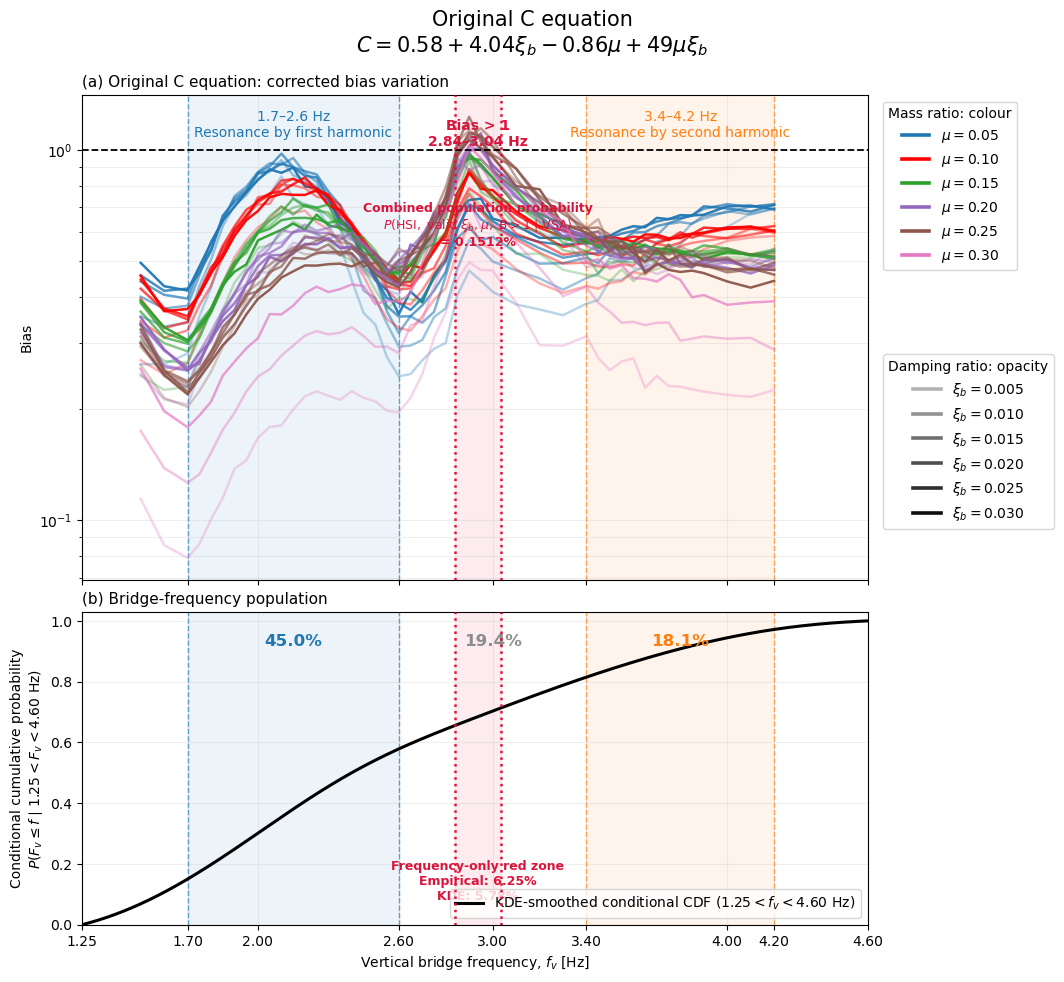

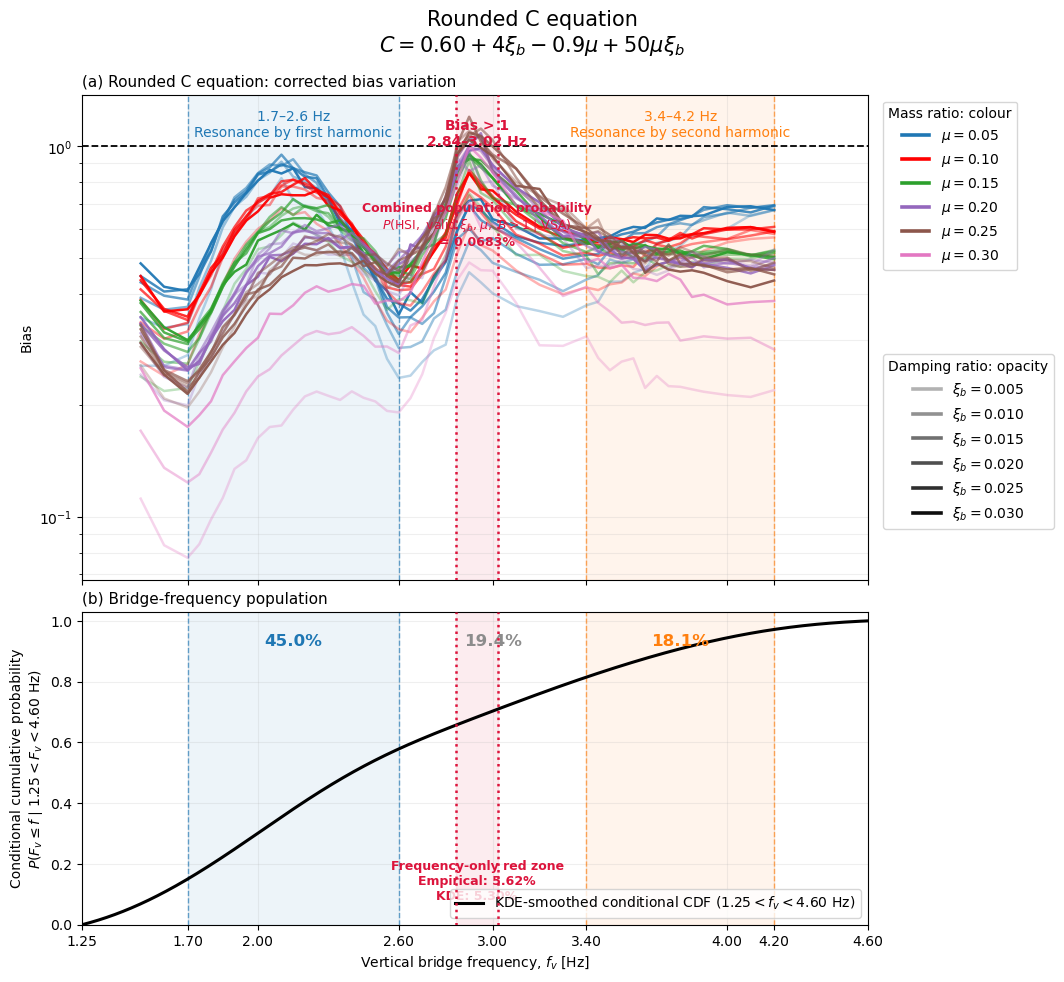


FINAL COMPARISON

Original C
----------
Frequency-only red zone(s): [(2.839762809000294, 3.0361377711979127)]
Frequency-only empirical probability | VSA = 6.2500%
Frequency-only KDE probability | VSA = 5.7826%
P(Bias>1 | valid HSI domain) = 0.4386%
P(valid domain AND Bias>1 | HSI) = 0.1703%
P(assessed Bias>1 | VSA) = 0.1512%
P(assessed Bias>1 | all bridges) = 0.0967%

Rounded C
---------
Frequency-only red zone(s): [(2.8441153433147073, 3.023904851793716)]
Frequency-only empirical probability | VSA = 5.6250%
Frequency-only KDE probability | VSA = 5.2965%
P(Bias>1 | valid HSI domain) = 0.1983%
P(valid domain AND Bias>1 | HSI) = 0.0770%
P(assessed Bias>1 | VSA) = 0.0683%
P(assessed Bias>1 | all bridges) = 0.0437%


In [20]:
# ============================================================
# ORIGINAL-C vs ROUNDED-C
# JOINT POPULATION UNDERPREDICTION ASSESSMENT
#
# REQUIRED EXISTING VARIABLE:
#
#     comparison_df
#
# This cell:
#
#   1. starts ONLY from comparison_df
#   2. rebuilds the bridge population
#   3. generates ONE set of Monte Carlo population draws
#   4. applies EXACTLY THE SAME draws to both C equations
#   5. calculates:
#
#        - frequency-only red-zone probability
#        - P(Bias > 1 | valid HSI domain)
#        - P(valid domain AND Bias > 1 | HSI)
#        - P(assessed Bias > 1 | VSA)
#        - P(assessed Bias > 1 | all bridges)
#
#   6. creates TWO red-zone figures:
#
#        Figure 1: Original C equation
#        Figure 2: Rounded C equation
#
# Underprediction:
#
#        Bias > 1
#
# ============================================================


import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from scipy.interpolate import (
    RegularGridInterpolator,
    LinearNDInterpolator
)

from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid


# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_SEED = 42

N_SAMPLES = 300_000

BIAS_THRESHOLD = 1.0


MEASURE_TO_USE = (
    "Peak absolute acceleration"
)


# ------------------------------------------------------------
# Population hierarchy
# ------------------------------------------------------------

VSA_FMIN = 1.25
VSA_FMAX = 4.60

HSI_FMIN = 1.50
HSI_FMAX = 4.20


XI_MODEL_MIN = 0.005
XI_MODEL_MAX = 0.030

MU_MODEL_MIN = 0.05
MU_MODEL_MAX = 0.25


# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

DAMPING_CSV = (
    "master_all_bridges_vertical_damping_frequency_span_material.csv"
)

MU_PBOX_CSV = (
    "pbox_pymc_material_weighted_mass_ratio.csv"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

SAVE_PLOTS = False

USE_LOG_Y = True


# ============================================================
# 2. CHECK comparison_df
# ============================================================

if "comparison_df" not in globals():

    raise NameError(
        "comparison_df does not exist.\n"
        "Run your Original-C / Rounded-C comparison cell first."
    )


required_columns = [

    "bridge_frequency",

    "target_beamdamp",

    "mass_ratio",
]


missing_columns = [

    column

    for column in required_columns

    if column not in comparison_df.columns
]


if missing_columns:

    raise KeyError(
        "comparison_df is missing:\n"
        f"{missing_columns}"
    )


# ============================================================
# 3. PREPARE COMPARISON DATA
# ============================================================

bias_df = comparison_df.copy()


for column in [

    "bridge_frequency",

    "target_beamdamp",

    "mass_ratio",
]:

    bias_df[column] = pd.to_numeric(
        bias_df[column],
        errors="coerce"
    )


# ------------------------------------------------------------
# Peak acceleration only
# ------------------------------------------------------------

if "measure" in bias_df.columns:

    measure_mask = (

        bias_df["measure"]
        .astype(str)
        .str.strip()

        ==

        MEASURE_TO_USE
    )

    if np.any(measure_mask):

        bias_df = bias_df[
            measure_mask
        ].copy()


# ============================================================
# 4. DEFINE THE TWO C EQUATIONS
# ============================================================

def C_original(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (

        0.58

        +

        4.04 * xi

        -

        0.86 * mu

        +

        49.0 * mu * xi
    )


def C_rounded(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (

        0.60

        +

        4.0 * xi

        -

        0.9 * mu

        +

        50.0 * mu * xi
    )


# ============================================================
# 5. FIND psi-CORRECTED BIAS
# ============================================================

if "newpsi_bias_mean" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "newpsi_bias_mean"
        ],

        errors="coerce"
    )


elif "newpsi_code_bias_mean" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "newpsi_code_bias_mean"
        ],

        errors="coerce"
    )


elif "bias_after_psi" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "bias_after_psi"
        ],

        errors="coerce"
    )


else:

    raise KeyError(

        "comparison_df must contain one of:\n"

        "  newpsi_bias_mean\n"
        "  newpsi_code_bias_mean\n"
        "  bias_after_psi"
    )


# ============================================================
# 6. RECALCULATE BOTH FINAL BIASES
#
# IMPORTANT:
#
# Do it here again so there is absolutely no ambiguity about
# which C equation belongs to which bias.
# ============================================================

mu_array = bias_df[
    "mass_ratio"
].to_numpy(
    dtype=float
)


xi_array = bias_df[
    "target_beamdamp"
].to_numpy(
    dtype=float
)


bias_df[
    "C_original"
] = C_original(
    mu_array,
    xi_array
)


bias_df[
    "C_rounded"
] = C_rounded(
    mu_array,
    xi_array
)


bias_df[
    "bias_original_C"
] = (

    bias_df[
        "bias_after_psi"
    ]

    /

    bias_df[
        "C_original"
    ]
)


bias_df[
    "bias_rounded_C"
] = (

    bias_df[
        "bias_after_psi"
    ]

    /

    bias_df[
        "C_rounded"
    ]
)


bias_df = bias_df.dropna(

    subset=[

        "bridge_frequency",

        "target_beamdamp",

        "mass_ratio",

        "bias_original_C",

        "bias_rounded_C",
    ]

).copy()


# ============================================================
# 7. DOMAIN USED FOR THE JOINT PROBABILITY
# ============================================================

model_bias_df = bias_df[

    (
        bias_df[
            "bridge_frequency"
        ]
        >=
        HSI_FMIN
    )

    &

    (
        bias_df[
            "bridge_frequency"
        ]
        <=
        HSI_FMAX
    )

    &

    (
        bias_df[
            "target_beamdamp"
        ]
        >=
        XI_MODEL_MIN
    )

    &

    (
        bias_df[
            "target_beamdamp"
        ]
        <=
        XI_MODEL_MAX
    )

    &

    (
        bias_df[
            "mass_ratio"
        ]
        >=
        MU_MODEL_MIN
    )

    &

    (
        bias_df[
            "mass_ratio"
        ]
        <=
        MU_MODEL_MAX
    )

].copy()


# Average any accidental duplicate points

model_bias_df = (

    model_bias_df

    .groupby(

        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ],

        as_index=False
    )

    .agg({

        "bias_original_C":
            "mean",

        "bias_rounded_C":
            "mean",
    })
)


print(
    "\n============================================================"
)

print(
    "BIAS SURFACE USED FOR POPULATION CALCULATION"
)

print(
    "============================================================"
)

print(
    f"\nRows = {len(model_bias_df):,}"
)

print(
    f"Frequency = "
    f"{model_bias_df['bridge_frequency'].min():.3f}"
    f" – "
    f"{model_bias_df['bridge_frequency'].max():.3f} Hz"
)

print(
    f"Damping = "
    f"{model_bias_df['target_beamdamp'].min():.4f}"
    f" – "
    f"{model_bias_df['target_beamdamp'].max():.4f}"
)

print(
    f"Mass ratio = "
    f"{model_bias_df['mass_ratio'].min():.3f}"
    f" – "
    f"{model_bias_df['mass_ratio'].max():.3f}"
)


# ============================================================
# 8. BUILD 3-D INTERPOLATORS
#
# coordinates:
#
#       frequency × damping × mass ratio
#
# ============================================================

def build_bias_interpolator(
    data,
    value_column
):

    f_grid = np.sort(
        data[
            "bridge_frequency"
        ].unique()
    )

    xi_grid = np.sort(
        data[
            "target_beamdamp"
        ].unique()
    )

    mu_grid = np.sort(
        data[
            "mass_ratio"
        ].unique()
    )


    full_index = pd.MultiIndex.from_product(

        [
            f_grid,
            xi_grid,
            mu_grid
        ],

        names=[

            "bridge_frequency",

            "target_beamdamp",

            "mass_ratio",
        ]
    )


    grid_series = (

        data

        .set_index(

            [
                "bridge_frequency",
                "target_beamdamp",
                "mass_ratio",
            ]

        )[value_column]

        .reindex(
            full_index
        )
    )


    # --------------------------------------------------------
    # Complete rectangular grid
    # --------------------------------------------------------

    if not grid_series.isna().any():

        cube = (

            grid_series
            .to_numpy(
                dtype=float
            )
            .reshape(

                len(f_grid),
                len(xi_grid),
                len(mu_grid)
            )
        )


        interpolator = RegularGridInterpolator(

            (
                f_grid,
                xi_grid,
                mu_grid
            ),

            cube,

            method="linear",

            bounds_error=False,

            fill_value=np.nan
        )


        def evaluate(points):

            return np.asarray(
                interpolator(points),
                dtype=float
            )


        interpolation_type = (
            "RegularGridInterpolator"
        )


    # --------------------------------------------------------
    # Fallback for incomplete grid
    # --------------------------------------------------------

    else:

        points = data[

            [
                "bridge_frequency",
                "target_beamdamp",
                "mass_ratio",
            ]

        ].to_numpy(
            dtype=float
        )


        values = data[
            value_column
        ].to_numpy(
            dtype=float
        )


        interpolator = LinearNDInterpolator(

            points,

            values,

            fill_value=np.nan
        )


        def evaluate(points):

            return np.asarray(
                interpolator(points),
                dtype=float
            )


        interpolation_type = (
            "LinearNDInterpolator"
        )


    return (
        evaluate,
        interpolation_type
    )


evaluate_original_bias, original_interp_type = (
    build_bias_interpolator(

        model_bias_df,

        "bias_original_C"
    )
)


evaluate_rounded_bias, rounded_interp_type = (
    build_bias_interpolator(

        model_bias_df,

        "bias_rounded_C"
    )
)


print(
    f"\nOriginal-C interpolator = "
    f"{original_interp_type}"
)

print(
    f"Rounded-C interpolator  = "
    f"{rounded_interp_type}"
)


# ============================================================
# 9. HELPER FUNCTIONS FOR POPULATION DATA
# ============================================================

def clean_numeric(series):

    s = series.astype(str)

    s = s.str.replace(
        "−",
        "-",
        regex=False
    )

    s = s.str.replace(
        "–",
        "-",
        regex=False
    )

    s = s.str.replace(
        "%",
        "",
        regex=False
    )

    s = s.str.replace(
        ",",
        "",
        regex=False
    )

    s = s.str.extract(
        r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    )[0]

    return pd.to_numeric(
        s,
        errors="coerce"
    )


def clean_damping(series):

    raw = series.astype(str)

    raw = raw.str.replace(
        "−",
        "-",
        regex=False
    )

    raw = raw.str.replace(
        "–",
        "-",
        regex=False
    )

    raw = raw.str.replace(
        "%",
        "",
        regex=False
    )


    output = []


    for value in raw:

        numbers = re.findall(

            r"\d*\.?\d+(?:[eE][-+]?\d+)?",

            value
        )


        if len(numbers) == 0:

            output.append(
                np.nan
            )


        elif (

            len(numbers) >= 2

            and

            (
                "-" in value
                or
                "to" in value.lower()
            )

        ):

            output.append(

                np.mean(
                    [
                        float(numbers[0]),
                        float(numbers[1])
                    ]
                )
            )


        else:

            output.append(
                float(numbers[0])
            )


    z = pd.Series(

        output,

        index=series.index,

        dtype=float
    )


    # 0.43 means 0.43%, therefore 0.0043

    percent_like = (

        z.notna()

        &

        (z > 0.20)

        &

        (z <= 20.0)
    )


    z.loc[
        percent_like
    ] /= 100.0


    impossible = (

        z.notna()

        &

        (
            (z <= 0.0)

            |

            (z > 0.20)
        )
    )


    z.loc[
        impossible
    ] = np.nan


    return z


# ============================================================
# 10. MATERIAL CLEANER
# ============================================================

MATERIAL_ORDER = [

    "Steel",

    "Concrete",

    "Steel-concrete composite",

    "FRP",

    "Timber",

    "Other",
]


def clean_material(x):

    s = str(x).strip().lower()


    if s in [

        "",
        "nan",
        "none",
        "-",
        "unknown",
        "other",
        "other types",
    ]:

        return "Other"


    if (

        "frp" in s

        or "gfrp" in s

        or "fiber" in s

        or "fibre" in s

        or "fiberglass" in s

        or "fibreglass" in s

        or "glass fibre" in s

        or "glass fiber" in s
    ):

        return "FRP"


    if (

        "timber" in s

        or "wood" in s

        or "wooden" in s
    ):

        return "Timber"


    if (

        (
            "steel" in s

            and

            "concrete" in s
        )

        or

        "steel-concrete" in s

        or

        "steel concrete" in s

        or

        "composite" in s

        or

        "mixed steel" in s
    ):

        return "Steel-concrete composite"


    if (

        "concrete" in s

        or

        "reinforced concrete" in s

        or

        s == "rc"
    ):

        return "Concrete"


    if (

        "steel" in s

        or

        "warren" in s

        or

        "bow-string" in s

        or

        "suspended" in s
    ):

        return "Steel"


    return "Other"


def safe_material_name(material):

    return (

        material

        .lower()

        .replace(
            " ",
            "_"
        )

        .replace(
            "-",
            "_"
        )
    )


# ============================================================
# 11. CHECK POPULATION FILES
# ============================================================

for filename in [

    DAMPING_CSV,

    MU_PBOX_CSV,
]:

    if not os.path.exists(
        filename
    ):

        raise FileNotFoundError(

            f"Cannot find:\n{filename}\n\n"

            f"Current folder:\n"
            f"{os.getcwd()}"
        )


# ============================================================
# 12. LOAD BRIDGE FREQUENCY / DAMPING POPULATION
# ============================================================

population_df = pd.read_csv(

    DAMPING_CSV,

    encoding="utf-8-sig"
)


population_df = (

    population_df

    .dropna(
        how="all"
    )

    .copy()
)


# ============================================================
# 13. FREQUENCY
# ============================================================

if "first_vertical_frequency_Hz" in population_df.columns:

    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "first_vertical_frequency_Hz"
        ]
    )


elif "vertical_natural_frequency_Hz" in population_df.columns:

    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "vertical_natural_frequency_Hz"
        ]
    )


else:

    raise KeyError(
        "No vertical-frequency column found."
    )


# ============================================================
# 14. MATERIAL
# ============================================================

if "material_used" in population_df.columns:

    material_column = (
        "material_used"
    )


elif "girder_material" in population_df.columns:

    material_column = (
        "girder_material"
    )


elif "material_group" in population_df.columns:

    material_column = (
        "material_group"
    )


else:

    raise KeyError(
        "No material column found."
    )


population_df[
    "material"
] = (

    population_df[
        material_column
    ]

    .apply(
        clean_material
    )
)


# ============================================================
# 15. DAMPING
# ============================================================

if "vertical_damping_ratio" in population_df.columns:

    population_df[
        "observed_damping"
    ] = clean_damping(

        population_df[
            "vertical_damping_ratio"
        ]
    )


else:

    population_df[
        "observed_damping"
    ] = np.nan


# ------------------------------------------------------------
# Was damping observed?
# ------------------------------------------------------------

if "damping_observed" in population_df.columns:

    flag = (

        population_df[
            "damping_observed"
        ]

        .astype(str)

        .str.strip()

        .str.lower()
    )


    population_df[
        "damping_observed_flag"
    ] = flag.isin(

        [
            "true",
            "1",
            "yes",
        ]
    )


else:

    population_df[
        "damping_observed_flag"
    ] = (

        population_df[
            "observed_damping"
        ].notna()
    )


# ------------------------------------------------------------
# Bayesian-imputed damping mean
# ------------------------------------------------------------

if "zeta_imputed_mean" in population_df.columns:

    population_df[
        "imputed_mean"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_mean"
        ]
    )


else:

    population_df[
        "imputed_mean"
    ] = np.nan


# ------------------------------------------------------------
# Bayesian-imputed damping SD
# ------------------------------------------------------------

if "zeta_imputed_sd" in population_df.columns:

    population_df[
        "imputed_sd"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_sd"
        ]
    )


else:

    population_df[
        "imputed_sd"
    ] = np.nan


# ------------------------------------------------------------
# Fallback completed damping
# ------------------------------------------------------------

if "zeta_completed_mean" in population_df.columns:

    completed_mean = clean_numeric(

        population_df[
            "zeta_completed_mean"
        ]
    )


    missing_imputed = (

        population_df[
            "imputed_mean"
        ].isna()
    )


    population_df.loc[

        missing_imputed,

        "imputed_mean"

    ] = completed_mean.loc[
        missing_imputed
    ]


# ============================================================
# 16. KEEP BRIDGES WITH USABLE FREQUENCY
# ============================================================

population_df = population_df[

    np.isfinite(

        population_df[
            "frequency"
        ]
    )

].copy()


population_df = population_df.reset_index(
    drop=True
)


N_ALL = len(
    population_df
)


# ============================================================
# 17. VSA POPULATION
#
# 1.25 < f < 4.60
# ============================================================

vsa_mask = (

    (
        population_df[
            "frequency"
        ]
        >
        VSA_FMIN
    )

    &

    (
        population_df[
            "frequency"
        ]
        <
        VSA_FMAX
    )
)


vsa_df = (

    population_df[
        vsa_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_VSA = len(
    vsa_df
)


P_VSA = (

    N_VSA

    /

    N_ALL
)


# ============================================================
# 18. HSI FREQUENCY POPULATION
#
# 1.50 < f < 4.40
# ============================================================

hsi_mask = (

    (
        vsa_df[
            "frequency"
        ]
        >
        HSI_FMIN
    )

    &

    (
        vsa_df[
            "frequency"
        ]
        <
        HSI_FMAX
    )
)


hsi_df = (

    vsa_df[
        hsi_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_HSI = len(
    hsi_df
)


P_HSI_GIVEN_VSA = (

    N_HSI

    /

    N_VSA
)


print(
    "\n============================================================"
)

print(
    "FREQUENCY POPULATION HIERARCHY"
)

print(
    "============================================================"
)

print(
    f"\nAll bridges = {N_ALL}"
)

print(
    f"VSA bridges = {N_VSA}"
)

print(
    f"HSI-frequency bridges = {N_HSI}"
)

print(
    f"\nP(VSA) = "
    f"{P_VSA:.6f} "
    f"= {100*P_VSA:.3f}%"
)

print(
    f"P(HSI | VSA) = "
    f"{P_HSI_GIVEN_VSA:.6f} "
    f"= {100*P_HSI_GIVEN_VSA:.3f}%"
)


# ============================================================
# 19. MASS-RATIO BAYESIAN P-BOX
# ============================================================

mu_pbox_df = pd.read_csv(

    MU_PBOX_CSV,

    encoding="utf-8-sig"
)


mu_pbox_df[
    "T"
] = pd.to_numeric(

    mu_pbox_df[
        "T"
    ],

    errors="coerce"
)


mu_pbox_df = (

    mu_pbox_df

    .dropna(
        subset=["T"]
    )

    .sort_values(
        "T"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 20. BUILD MATERIAL-SPECIFIC MASS-RATIO MODELS
# ============================================================

mu_models = {}


for material in MATERIAL_ORDER:

    safe = safe_material_name(
        material
    )


    theta_column = (
        f"{safe}_theta_mean"
    )


    n_known_column = (
        f"{safe}_n_known"
    )


    if theta_column not in mu_pbox_df.columns:

        continue


    if n_known_column not in mu_pbox_df.columns:

        continue


    n_known_values = pd.to_numeric(

        mu_pbox_df[
            n_known_column
        ],

        errors="coerce"

    ).dropna()


    if len(
        n_known_values
    ) == 0:

        continue


    n_known = int(

        round(
            n_known_values.iloc[0]
        )
    )


    # No data = prior only.
    # Do not fabricate a material-specific mu distribution.

    if n_known <= 0:

        continue


    T_saved = pd.to_numeric(

        mu_pbox_df[
            "T"
        ],

        errors="coerce"

    ).to_numpy(
        dtype=float
    )


    F_saved = pd.to_numeric(

        mu_pbox_df[
            theta_column
        ],

        errors="coerce"

    ).to_numpy(
        dtype=float
    )


    valid = (

        np.isfinite(
            T_saved
        )

        &

        np.isfinite(
            F_saved
        )
    )


    T_saved = T_saved[
        valid
    ]


    F_saved = F_saved[
        valid
    ]


    order = np.argsort(
        T_saved
    )


    T_saved = T_saved[
        order
    ]


    F_saved = F_saved[
        order
    ]


    F_saved = np.maximum.accumulate(
        F_saved
    )


    F_saved = np.clip(
        F_saved,
        0.0,
        1.0
    )


    F_mu_min = float(

        np.interp(

            MU_MODEL_MIN,

            T_saved,

            F_saved
        )
    )


    F_mu_max = float(

        np.interp(

            MU_MODEL_MAX,

            T_saved,

            F_saved
        )
    )


    P_inside = max(

        0.0,

        F_mu_max
        -
        F_mu_min
    )


    if P_inside <= 1e-12:

        continue


    internal_T = T_saved[

        (
            T_saved
            >
            MU_MODEL_MIN
        )

        &

        (
            T_saved
            <
            MU_MODEL_MAX
        )
    ]


    edges = np.unique(

        np.concatenate(

            [
                [MU_MODEL_MIN],

                internal_T,

                [MU_MODEL_MAX]
            ]
        )
    )


    F_edges = np.interp(

        edges,

        T_saved,

        F_saved
    )


    F_edges = np.maximum.accumulate(
        F_edges
    )


    weights = np.diff(
        F_edges
    )


    weights = np.maximum(
        weights,
        0.0
    )


    if np.sum(
        weights
    ) <= 1e-12:

        continue


    weights = (

        weights

        /

        np.sum(
            weights
        )
    )


    mu_models[
        material
    ] = {

        "P_inside":
            P_inside,

        "edges":
            edges,

        "weights":
            weights,

        "n_known":
            n_known,
    }


print(
    "\nMass-ratio-supported materials:"
)

print(
    list(
        mu_models.keys()
    )
)


# ============================================================
# 21. DAMPING SAMPLER
# ============================================================

def sample_lognormal_from_mean_sd(
    mean,
    sd,
    rng
):

    mean = np.asarray(
        mean,
        dtype=float
    )


    sd = np.asarray(
        sd,
        dtype=float
    )


    output = np.full(

        len(mean),

        np.nan,

        dtype=float
    )


    deterministic = (

        np.isfinite(
            mean
        )

        &

        (mean > 0)

        &

        (
            ~np.isfinite(
                sd
            )

            |

            (sd <= 0)
        )
    )


    output[
        deterministic
    ] = mean[
        deterministic
    ]


    stochastic = (

        np.isfinite(
            mean
        )

        &

        (mean > 0)

        &

        np.isfinite(
            sd
        )

        &

        (sd > 0)
    )


    if np.any(
        stochastic
    ):

        m = mean[
            stochastic
        ]


        s = sd[
            stochastic
        ]


        sigma_squared_log = np.log(

            1.0

            +

            (
                s / m
            )**2
        )


        sigma_log = np.sqrt(
            sigma_squared_log
        )


        mu_log = (

            np.log(
                m
            )

            -

            0.5
            *
            sigma_squared_log
        )


        output[
            stochastic
        ] = rng.lognormal(

            mean=
                mu_log,

            sigma=
                sigma_log
        )


    return output


# ============================================================
# 22. GENERATE ONE SET OF MONTE CARLO DRAWS
#
# THESE DRAWS WILL BE USED FOR BOTH EQUATIONS.
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


sample_indices = rng.choice(

    hsi_df.index.to_numpy(),

    size=N_SAMPLES,

    replace=True
)


sample_df = (

    hsi_df.loc[
        sample_indices
    ]

    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Frequency and material
# ------------------------------------------------------------

f_samples = sample_df[
    "frequency"
].to_numpy(
    dtype=float
)


material_samples = sample_df[
    "material"
].to_numpy()


# ------------------------------------------------------------
# Damping
# ------------------------------------------------------------

observed_flag = sample_df[
    "damping_observed_flag"
].to_numpy(
    dtype=bool
)


observed_xi = sample_df[
    "observed_damping"
].to_numpy(
    dtype=float
)


imputed_mean = sample_df[
    "imputed_mean"
].to_numpy(
    dtype=float
)


imputed_sd = sample_df[
    "imputed_sd"
].to_numpy(
    dtype=float
)


xi_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


use_observed = (

    observed_flag

    &

    np.isfinite(
        observed_xi
    )
)


xi_samples[
    use_observed
] = observed_xi[
    use_observed
]


use_imputed = (
    ~use_observed
)


xi_samples[
    use_imputed
] = sample_lognormal_from_mean_sd(

    mean=
        imputed_mean[
            use_imputed
        ],

    sd=
        imputed_sd[
            use_imputed
        ],

    rng=rng
)


# ------------------------------------------------------------
# Mass ratio
# ------------------------------------------------------------

material_mu_supported = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_inside = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


for material in np.unique(
    material_samples
):

    indices = np.flatnonzero(

        material_samples

        ==

        material
    )


    if material not in mu_models:

        continue


    material_mu_supported[
        indices
    ] = True


    model = mu_models[
        material
    ]


    # --------------------------------------------------------
    # First draw:
    #
    # Is this bridge inside 0.05 <= mu <= 0.25?
    # --------------------------------------------------------

    inside_local = (

        rng.random(
            len(indices)
        )

        <

        model[
            "P_inside"
        ]
    )


    inside_indices = indices[
        inside_local
    ]


    mu_inside[
        inside_indices
    ] = True


    if len(
        inside_indices
    ) == 0:

        continue


    # --------------------------------------------------------
    # Then sample mu conditional on being inside domain
    # --------------------------------------------------------

    weights = model[
        "weights"
    ]


    edges = model[
        "edges"
    ]


    selected_bins = rng.choice(

        np.arange(
            len(weights)
        ),

        size=
            len(
                inside_indices
            ),

        replace=True,

        p=weights
    )


    lower_edges = edges[
        selected_bins
    ]


    upper_edges = edges[
        selected_bins + 1
    ]


    mu_samples[
        inside_indices
    ] = rng.uniform(

        low=
            lower_edges,

        high=
            upper_edges
    )


# ============================================================
# 23. VALID DAMPING DOMAIN
# ============================================================

xi_inside = (

    np.isfinite(
        xi_samples
    )

    &

    (
        xi_samples
        >=
        XI_MODEL_MIN
    )

    &

    (
        xi_samples
        <=
        XI_MODEL_MAX
    )
)


# ============================================================
# 24. COMPLETE VALID HSI DOMAIN
# ============================================================

complete_domain = (

    material_mu_supported

    &

    mu_inside

    &

    xi_inside

    &

    np.isfinite(
        mu_samples
    )
)


print(
    "\n============================================================"
)

print(
    "COMMON MONTE CARLO POPULATION"
)

print(
    "============================================================"
)

print(
    f"\nTotal HSI draws = "
    f"{N_SAMPLES:,}"
)

print(
    f"Valid xi-mu draws = "
    f"{np.sum(complete_domain):,}"
)

print(
    f"P(valid xi-mu domain | HSI) = "
    f"{100*np.mean(complete_domain):.4f}%"
)


# ============================================================
# 25. EVALUATE BOTH BIAS SURFACES
#
# SAME points are passed to BOTH interpolators.
# ============================================================

evaluation_points = np.column_stack(

    [

        f_samples[
            complete_domain
        ],

        xi_samples[
            complete_domain
        ],

        mu_samples[
            complete_domain
        ],
    ]
)


sampled_bias_original = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


sampled_bias_rounded = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


sampled_bias_original[
    complete_domain
] = evaluate_original_bias(
    evaluation_points
)


sampled_bias_rounded[
    complete_domain
] = evaluate_rounded_bias(
    evaluation_points
)


# ============================================================
# 26. INTERPOLATION-VALID MASKS
# ============================================================

valid_original = (

    complete_domain

    &

    np.isfinite(
        sampled_bias_original
    )
)


valid_rounded = (

    complete_domain

    &

    np.isfinite(
        sampled_bias_rounded
    )
)


# ------------------------------------------------------------
# For a perfectly fair comparison, retain only points for
# which BOTH interpolators returned a value.
# ------------------------------------------------------------

common_valid = (

    valid_original

    &

    valid_rounded
)


print(
    f"\nCommon valid draws for both equations = "
    f"{np.sum(common_valid):,}"
)


# ============================================================
# 27. UNDERPREDICTION EVENTS
#
# Bias > 1
# ============================================================

exceed_original = (

    common_valid

    &

    (
        sampled_bias_original
        >
        BIAS_THRESHOLD
    )
)


exceed_rounded = (

    common_valid

    &

    (
        sampled_bias_rounded
        >
        BIAS_THRESHOLD
    )
)


# ============================================================
# 28. CALCULATE THE HIERARCHICAL PROBABILITIES
# ============================================================

def calculate_probabilities(
    exceedance,
    valid_mask
):

    N_valid = int(
        np.sum(
            valid_mask
        )
    )


    N_exceed = int(
        np.sum(
            exceedance
        )
    )


    # --------------------------------------------------------
    # Conditional on being inside the valid HSI xi-mu domain
    # --------------------------------------------------------

    P_exceed_given_valid = (

        N_exceed

        /

        N_valid
    )


    # --------------------------------------------------------
    # Combined probability within the HSI-frequency population:
    #
    # valid xi-mu domain AND Bias > 1
    # --------------------------------------------------------

    P_valid_and_exceed_given_HSI = (

        N_exceed

        /

        N_SAMPLES
    )


    # --------------------------------------------------------
    # Main result relative to VSA bridges
    # --------------------------------------------------------

    P_assessed_exceed_given_VSA = (

        P_HSI_GIVEN_VSA

        *

        P_valid_and_exceed_given_HSI
    )


    # --------------------------------------------------------
    # Relative to all bridges
    # --------------------------------------------------------

    P_assessed_exceed_all = (

        P_VSA

        *

        P_assessed_exceed_given_VSA
    )


    return {

        "N_valid":
            N_valid,

        "N_exceed":
            N_exceed,

        "P_exceed_given_valid":
            P_exceed_given_valid,

        "P_valid_and_exceed_given_HSI":
            P_valid_and_exceed_given_HSI,

        "P_assessed_exceed_given_VSA":
            P_assessed_exceed_given_VSA,

        "P_assessed_exceed_all":
            P_assessed_exceed_all,
    }


result_original = calculate_probabilities(

    exceed_original,

    common_valid
)


result_rounded = calculate_probabilities(

    exceed_rounded,

    common_valid
)


# ============================================================
# 29. DIRECT COMPARISON TABLE
# ============================================================

probability_comparison_df = pd.DataFrame({

    "Equation": [

        "Original C",

        "Rounded C",
    ],


    "N valid": [

        result_original[
            "N_valid"
        ],

        result_rounded[
            "N_valid"
        ],
    ],


    "N Bias>1": [

        result_original[
            "N_exceed"
        ],

        result_rounded[
            "N_exceed"
        ],
    ],


    "P(Bias>1 | valid HSI domain) [%]": [

        100.0
        *
        result_original[
            "P_exceed_given_valid"
        ],

        100.0
        *
        result_rounded[
            "P_exceed_given_valid"
        ],
    ],


    "P(valid AND Bias>1 | HSI) [%]": [

        100.0
        *
        result_original[
            "P_valid_and_exceed_given_HSI"
        ],

        100.0
        *
        result_rounded[
            "P_valid_and_exceed_given_HSI"
        ],
    ],


    "P(assessed Bias>1 | VSA) [%]": [

        100.0
        *
        result_original[
            "P_assessed_exceed_given_VSA"
        ],

        100.0
        *
        result_rounded[
            "P_assessed_exceed_given_VSA"
        ],
    ],


    "P(assessed Bias>1 | all bridges) [%]": [

        100.0
        *
        result_original[
            "P_assessed_exceed_all"
        ],

        100.0
        *
        result_rounded[
            "P_assessed_exceed_all"
        ],
    ],
})


print(
    "\n============================================================"
)

print(
    "ORIGINAL C vs ROUNDED C — JOINT POPULATION RESULT"
)

print(
    "============================================================\n"
)


print(

    probability_comparison_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


# ============================================================
# 30. SAVE COMMON DRAWS
#
# joint_mc_df DID NOT NEED TO EXIST BEFORE THIS CELL.
#
# It is created HERE only for later diagnostics.
# ============================================================

joint_mc_df = pd.DataFrame({

    "frequency":
        f_samples,

    "material":
        material_samples,

    "damping":
        xi_samples,

    "mu":
        mu_samples,

    "material_mu_supported":
        material_mu_supported,

    "mu_inside_domain":
        mu_inside,

    "xi_inside_domain":
        xi_inside,

    "complete_domain":
        complete_domain,

    "common_valid":
        common_valid,

    "bias_original_C":
        sampled_bias_original,

    "bias_rounded_C":
        sampled_bias_rounded,

    "Bias_gt_1_original":
        exceed_original,

    "Bias_gt_1_rounded":
        exceed_rounded,
})


# ============================================================
# 31. CONDITIONAL FREQUENCY POPULATION FOR FIGURES
#
# CDF conditioned on:
#
#       1.25 < f < 4.60 Hz
# ============================================================

freq_vsa = (

    vsa_df[
        "frequency"
    ]

    .dropna()

    .to_numpy(
        dtype=float
    )
)


freq_vsa = np.sort(
    freq_vsa
)


kde_frequency = gaussian_kde(
    freq_vsa
)


cdf_x = np.linspace(

    VSA_FMIN,

    VSA_FMAX,

    2500
)


cdf_pdf = kde_frequency(
    cdf_x
)


cdf_y = cumulative_trapezoid(

    cdf_pdf,

    cdf_x,

    initial=0.0
)


cdf_y = (

    cdf_y

    /

    cdf_y[-1]
)


def conditional_kde_probability(
    lower,
    upper
):

    F_lower = np.interp(

        lower,

        cdf_x,

        cdf_y
    )


    F_upper = np.interp(

        upper,

        cdf_x,

        cdf_y
    )


    return max(

        0.0,

        float(
            F_upper
            -
            F_lower
        )
    )


def empirical_probability(
    lower,
    upper
):

    return float(

        np.mean(

            (
                freq_vsa
                >=
                lower
            )

            &

            (
                freq_vsa
                <=
                upper
            )
        )
    )


# ============================================================
# 32. FREQUENCY-ONLY RED-ZONE DETECTOR
#
# "Red zone" means:
#
# at least one VALID-domain mu-xi combination has Bias > 1.
#
# This is deliberately different from the joint probability.
#
# Frequency-only:
#
#      asks "which frequencies can underpredict?"
#
# Joint:
#
#      also weights xi_b and mu occurrence.
# ============================================================

def threshold_crossing(
    x1,
    y1,
    x2,
    y2,
    threshold=1.0
):

    if np.isclose(
        y1,
        y2
    ):

        return float(
            0.5
            *
            (
                x1 + x2
            )
        )


    return float(

        x1

        +

        (
            threshold - y1
        )

        *

        (
            x2 - x1
        )

        /

        (
            y2 - y1
        )
    )


def find_frequency_red_zones(
    data,
    bias_column
):

    temp = data[

        (
            data[
                "bridge_frequency"
            ]
            >=
            HSI_FMIN
        )

        &

        (
            data[
                "bridge_frequency"
            ]
            <=
            HSI_FMAX
        )

        &

        (
            data[
                "target_beamdamp"
            ]
            >=
            XI_MODEL_MIN
        )

        &

        (
            data[
                "target_beamdamp"
            ]
            <=
            XI_MODEL_MAX
        )

        &

        (
            data[
                "mass_ratio"
            ]
            >=
            MU_MODEL_MIN
        )

        &

        (
            data[
                "mass_ratio"
            ]
            <=
            MU_MODEL_MAX
        )

    ].copy()


    frequency_summary = (

        temp

        .groupby(
            "bridge_frequency"
        )[bias_column]

        .max()

        .reset_index(
            name="maximum_bias"
        )

        .sort_values(
            "bridge_frequency"
        )

        .reset_index(
            drop=True
        )
    )


    frequency = frequency_summary[
        "bridge_frequency"
    ].to_numpy(
        dtype=float
    )


    maximum_bias = frequency_summary[
        "maximum_bias"
    ].to_numpy(
        dtype=float
    )


    above = (

        maximum_bias

        >

        BIAS_THRESHOLD
    )


    start_indices = np.where(

        above

        &

        ~np.r_[
            False,
            above[:-1]
        ]

    )[0]


    end_indices = np.where(

        above

        &

        ~np.r_[
            above[1:],
            False
        ]

    )[0]


    intervals = []


    for start_index, end_index in zip(

        start_indices,

        end_indices
    ):


        # ----------------------------------------------------
        # Left crossing
        # ----------------------------------------------------

        if start_index == 0:

            lower = frequency[
                start_index
            ]


        else:

            lower = threshold_crossing(

                frequency[
                    start_index - 1
                ],

                maximum_bias[
                    start_index - 1
                ],

                frequency[
                    start_index
                ],

                maximum_bias[
                    start_index
                ],

                BIAS_THRESHOLD
            )


        # ----------------------------------------------------
        # Right crossing
        # ----------------------------------------------------

        if end_index == (
            len(frequency) - 1
        ):

            upper = frequency[
                end_index
            ]


        else:

            upper = threshold_crossing(

                frequency[
                    end_index
                ],

                maximum_bias[
                    end_index
                ],

                frequency[
                    end_index + 1
                ],

                maximum_bias[
                    end_index + 1
                ],

                BIAS_THRESHOLD
            )


        intervals.append(

            (
                max(
                    lower,
                    HSI_FMIN
                ),

                min(
                    upper,
                    HSI_FMAX
                )
            )
        )


    return intervals


red_zones_original = find_frequency_red_zones(

    model_bias_df,

    "bias_original_C"
)


red_zones_rounded = find_frequency_red_zones(

    model_bias_df,

    "bias_rounded_C"
)


# ============================================================
# 33. FREQUENCY-ONLY PROBABILITY FOR EACH EQUATION
# ============================================================

def red_zone_frequency_probabilities(
    intervals
):

    kde_total = 0.0

    empirical_total = 0.0


    for lower, upper in intervals:

        kde_total += (
            conditional_kde_probability(
                lower,
                upper
            )
        )


        empirical_total += (
            empirical_probability(
                lower,
                upper
            )
        )


    return (
        empirical_total,
        kde_total
    )


(
    empirical_red_original,
    kde_red_original

) = red_zone_frequency_probabilities(
    red_zones_original
)


(
    empirical_red_rounded,
    kde_red_rounded

) = red_zone_frequency_probabilities(
    red_zones_rounded
)


print(
    "\n============================================================"
)

print(
    "FREQUENCY-ONLY RED ZONES"
)

print(
    "============================================================"
)


print(
    "\nOriginal C:"
)

print(
    red_zones_original
)

print(
    f"Empirical P(red frequency | VSA) = "
    f"{100*empirical_red_original:.4f}%"
)

print(
    f"KDE P(red frequency | VSA) = "
    f"{100*kde_red_original:.4f}%"
)


print(
    "\nRounded C:"
)

print(
    red_zones_rounded
)

print(
    f"Empirical P(red frequency | VSA) = "
    f"{100*empirical_red_rounded:.4f}%"
)

print(
    f"KDE P(red frequency | VSA) = "
    f"{100*kde_red_rounded:.4f}%"
)


# ============================================================
# 34. BAND PERCENTAGES
# ============================================================

population_bands = [

    (
        1.70,
        2.60,
        "tab:blue"
    ),

    (
        2.60,
        3.40,
        "0.55"
    ),

    (
        3.40,
        4.20,
        "tab:orange"
    ),
]


band_percentages = {}


for lower, upper, colour in population_bands:

    probability = empirical_probability(
        lower,
        upper
    )


    band_percentages[
        (
            lower,
            upper
        )
    ] = probability


# ============================================================
# 35. PLOT SETTINGS
# ============================================================

mass_ratios_to_plot = [

    value

    for value in [

        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
    ]

    if np.any(

        np.isclose(

            bias_df[
                "mass_ratio"
            ],

            value
        )
    )
]


dampings_to_plot = [

    value

    for value in [

        0.005,
        0.010,
        0.015,
        0.020,
        0.025,
        0.030,
    ]

    if np.any(

        np.isclose(

            bias_df[
                "target_beamdamp"
            ],

            value
        )
    )
]


mu_colour_map = {

    0.05:
        "tab:blue",

    0.10:
        "red",

    0.15:
        "tab:green",

    0.20:
        "tab:purple",

    0.25:
        "tab:brown",

    0.30:
        "tab:pink",
}


alpha_values = np.linspace(

    0.30,

    0.95,

    max(
        len(
            dampings_to_plot
        ),
        1
    )
)


alpha_map = {

    damping:
        alpha

    for damping, alpha in zip(

        dampings_to_plot,

        alpha_values
    )
}


# ============================================================
# 36. PLOT FUNCTION
# ============================================================

def make_red_zone_figure(

    bias_column,

    equation_name,

    equation_text,

    intervals,

    empirical_frequency_probability,

    kde_frequency_probability,

    joint_result,

    output_filename
):

    fig, (
        ax_top,
        ax_bottom

    ) = plt.subplots(

        2,
        1,

        figsize=(
            12,
            10
        ),

        sharex=True,

        gridspec_kw={

            "height_ratios":
                [
                    1.55,
                    1.0
                ],

            "hspace":
                0.08
        }
    )


    # ========================================================
    # BACKGROUND RESONANCE BANDS
    # ========================================================

    for ax in [
        ax_top,
        ax_bottom
    ]:

        ax.axvspan(

            1.70,
            2.60,

            alpha=0.08,

            color="tab:blue"
        )


        ax.axvline(

            1.70,

            linestyle="--",

            linewidth=1.0,

            color="tab:blue",

            alpha=0.65
        )


        ax.axvline(

            2.60,

            linestyle="--",

            linewidth=1.0,

            color="tab:blue",

            alpha=0.65
        )


        ax.axvspan(

            3.40,
            4.20,

            alpha=0.08,

            color="tab:orange"
        )


        ax.axvline(

            3.40,

            linestyle="--",

            linewidth=1.0,

            color="tab:orange",

            alpha=0.65
        )


        ax.axvline(

            4.20,

            linestyle="--",

            linewidth=1.0,

            color="tab:orange",

            alpha=0.65
        )


    # ========================================================
    # RED ZONES
    # ========================================================

    for lower, upper in intervals:

        for ax in [
            ax_top,
            ax_bottom
        ]:

            ax.axvspan(

                lower,
                upper,

                color="crimson",

                alpha=0.08,

                zorder=0
            )


            ax.axvline(

                lower,

                color="crimson",

                linestyle=":",

                linewidth=1.8,

                zorder=8
            )


            ax.axvline(

                upper,

                color="crimson",

                linestyle=":",

                linewidth=1.8,

                zorder=8
            )


    # ========================================================
    # TOP PANEL — BIAS CURVES
    # ========================================================

    for mu in mass_ratios_to_plot:

        for xi in dampings_to_plot:

            subset = bias_df[

            np.isclose(
                bias_df["mass_ratio"],
                mu
            )

            &

            np.isclose(
                bias_df["target_beamdamp"],
                xi
            )

            &

            (
                bias_df["bridge_frequency"]
                >=
                HSI_FMIN
            )

            &

            (
                bias_df["bridge_frequency"]
                <=
                HSI_FMAX
            )

        ].copy()


            if len(
                subset
            ) == 0:

                continue


            subset = (

                subset

                .groupby(

                    "bridge_frequency",

                    as_index=False

                )[bias_column]

                .mean()

                .sort_values(
                    "bridge_frequency"
                )
            )


            ax_top.plot(

                subset[
                    "bridge_frequency"
                ],

                subset[
                    bias_column
                ],

                color=
                    mu_colour_map.get(
                        mu,
                        None
                    ),

                alpha=
                    alpha_map.get(
                        xi,
                        0.7
                    ),

                linewidth=1.8
            )


    ax_top.axhline(

        1.0,

        color="black",

        linestyle="--",

        linewidth=1.3
    )


    # ========================================================
    # RED-ZONE TOP ANNOTATIONS
    # ========================================================

    if len(intervals) > 0:

        first_lower = intervals[0][0]

        last_upper = intervals[-1][1]

        midpoint = (

            first_lower
            +
            last_upper

        ) / 2.0


        interval_string = (

            ", ".join(

                [
                    f"{lower:.2f}–{upper:.2f} Hz"

                    for lower, upper
                    in intervals
                ]
            )
        )


        ax_top.text(

            midpoint,

            0.95,

            (
                "Bias > 1\n"

                f"{interval_string}"
            ),

            transform=
                ax_top.get_xaxis_transform(),

            ha="center",

            va="top",

            color="crimson",

            fontsize=10,

            fontweight="bold",

            zorder=12
        )


        ax_top.text(

            midpoint,

            0.78,

            (
                "Combined population probability\n"

                r"$P(\mathrm{HSI},"
                r"\ \mathrm{valid}\ \xi_b,\mu,"
                r"\ B>1\mid\mathrm{VSA})$"
                "\n"

                f"= "
                f"{100*joint_result['P_assessed_exceed_given_VSA']:.4f}%"
            ),

            transform=
                ax_top.get_xaxis_transform(),

            ha="center",

            va="top",

            color="crimson",

            fontsize=9,

            fontweight="bold",

            zorder=12
        )


    # ========================================================
    # RESONANCE TEXT
    # ========================================================

    ax_top.text(

        2.15,

        0.97,

        "1.7–2.6 Hz\n"
        "Resonance by first harmonic",

        transform=
            ax_top.get_xaxis_transform(),

        ha="center",

        va="top",

        color="tab:blue",

        fontsize=10
    )


    ax_top.text(

        3.80,

        0.97,

        "3.4–4.2 Hz\n"
        "Resonance by second harmonic",

        transform=
            ax_top.get_xaxis_transform(),

        ha="center",

        va="top",

        color="tab:orange",

        fontsize=10
    )


    # ========================================================
    # TOP PANEL FORMAT
    # ========================================================

    ax_top.set_ylabel(
        "Bias"
    )


    if USE_LOG_Y:

        ax_top.set_yscale(
            "log"
        )


    ax_top.set_title(

        f"(a) {equation_name}: corrected bias variation",

        loc="left",

        fontsize=11
    )


    ax_top.grid(

        True,

        which="both",

        alpha=0.20
    )


    # ========================================================
    # BOTTOM PANEL — CONDITIONAL FREQUENCY CDF
    # ========================================================

    ax_bottom.plot(

        cdf_x,

        cdf_y,

        color="black",

        linewidth=2.2,

        label=(

            "KDE-smoothed conditional CDF "
            r"$(1.25<f_v<4.60\ \mathrm{Hz})$"
        )
    )


    # --------------------------------------------------------
    # Population band percentages
    # --------------------------------------------------------

    for lower, upper, colour in population_bands:

        probability = band_percentages[
            (
                lower,
                upper
            )
        ]


        midpoint = (

            lower
            +
            upper

        ) / 2.0


        ax_bottom.text(

            midpoint,

            0.93,

            f"{100*probability:.1f}%",

            transform=
                ax_bottom.get_xaxis_transform(),

            ha="center",

            va="top",

            color=colour,

            fontsize=12,

            fontweight="bold"
        )


    # --------------------------------------------------------
    # Frequency-only red-zone probability
    # --------------------------------------------------------

    if len(intervals) > 0:

        lower_total = intervals[0][0]

        upper_total = intervals[-1][1]

        midpoint = (

            lower_total
            +
            upper_total

        ) / 2.0


        ax_bottom.text(

            midpoint,

            0.07,

            (
                "Frequency-only red zone\n"

                f"Empirical: "
                f"{100*empirical_frequency_probability:.2f}%\n"

                f"KDE: "
                f"{100*kde_frequency_probability:.2f}%"
            ),

            transform=
                ax_bottom.get_xaxis_transform(),

            ha="center",

            va="bottom",

            color="crimson",

            fontsize=9,

            fontweight="bold"
        )


    # ========================================================
    # BOTTOM FORMAT
    # ========================================================

    ax_bottom.set_xlim(

        VSA_FMIN,

        VSA_FMAX
    )


    ax_bottom.set_ylim(

        0.0,

        1.03
    )


    ax_bottom.set_xlabel(

        r"Vertical bridge frequency, $f_v$ [Hz]"
    )


    ax_bottom.set_ylabel(

        "Conditional cumulative probability\n"

        r"$P(F_v\leq f\mid "
        r"1.25<F_v<4.60\ \mathrm{Hz})$"
    )


    ax_bottom.set_title(

        "(b) Bridge-frequency population",

        loc="left",

        fontsize=11
    )


    ax_bottom.grid(

        True,

        alpha=0.20
    )


    ax_bottom.legend(
        loc="lower right"
    )


    ax_bottom.set_xticks(

        [
            1.25,
            1.70,
            2.00,
            2.60,
            3.00,
            3.40,
            4.00,
            4.20,
            4.60,
        ]
    )


    # ========================================================
    # LEGENDS
    # ========================================================

    mass_handles = [

        Line2D(

            [0],
            [0],

            color=
                mu_colour_map[
                    mu
                ],

            linewidth=2.6,

            label=
                rf"$\mu={mu:.2f}$"
        )

        for mu in mass_ratios_to_plot
    ]


    damping_handles = [

        Line2D(

            [0],
            [0],

            color="black",

            alpha=
                alpha_map[
                    xi
                ],

            linewidth=2.6,

            label=
                rf"$\xi_b={xi:.3f}$"
        )

        for xi in dampings_to_plot
    ]


    legend_mass = ax_top.legend(

        handles=
            mass_handles,

        title=
            "Mass ratio: colour",

        bbox_to_anchor=(
            1.01,
            1.00
        ),

        loc=
            "upper left"
    )


    ax_top.add_artist(
        legend_mass
    )


    ax_top.legend(

        handles=
            damping_handles,

        title=
            "Damping ratio: opacity",

        bbox_to_anchor=(
            1.01,
            0.48
        ),

        loc=
            "upper left"
    )


    # ========================================================
    # OVERALL TITLE
    # ========================================================

    fig.suptitle(

        f"{equation_name}\n"

        f"${equation_text}$",

        fontsize=15,

        y=0.995
    )


    fig.subplots_adjust(

        right=0.78,

        top=0.91,

        bottom=0.08
    )


    if SAVE_PLOTS:

        fig.savefig(

            output_filename,

            dpi=300,

            bbox_inches="tight"
        )


        print(
            f"\nSaved: {output_filename}"
        )


    plt.show()


# ============================================================
# 37. FIGURE 1 — ORIGINAL C
# ============================================================

make_red_zone_figure(

    bias_column=
        "bias_original_C",

    equation_name=
        "Original C equation",

    equation_text=(
        r"C=0.58+4.04\xi_b"
        r"-0.86\mu+49\mu\xi_b"
    ),

    intervals=
        red_zones_original,

    empirical_frequency_probability=
        empirical_red_original,

    kde_frequency_probability=
        kde_red_original,

    joint_result=
        result_original,

    output_filename=
        "original_C_red_zone.pdf"
)


# ============================================================
# 38. FIGURE 2 — ROUNDED C
# ============================================================

make_red_zone_figure(

    bias_column=
        "bias_rounded_C",

    equation_name=
        "Rounded C equation",

    equation_text=(
        r"C=0.60+4\xi_b"
        r"-0.9\mu+50\mu\xi_b"
    ),

    intervals=
        red_zones_rounded,

    empirical_frequency_probability=
        empirical_red_rounded,

    kde_frequency_probability=
        kde_red_rounded,

    joint_result=
        result_rounded,

    output_filename=
        "rounded_C_red_zone.pdf"
)


# ============================================================
# 39. FINAL SHORT COMPARISON
# ============================================================

print(
    "\n============================================================"
)

print(
    "FINAL COMPARISON"
)

print(
    "============================================================"
)


for (
    name,
    intervals,
    empirical_probability_red,
    kde_probability_red,
    result

) in [

    (
        "Original C",
        red_zones_original,
        empirical_red_original,
        kde_red_original,
        result_original
    ),

    (
        "Rounded C",
        red_zones_rounded,
        empirical_red_rounded,
        kde_red_rounded,
        result_rounded
    ),
]:

    print(
        f"\n{name}"
    )

    print(
        "-" * len(name)
    )

    print(
        f"Frequency-only red zone(s): "
        f"{intervals}"
    )

    print(
        f"Frequency-only empirical probability | VSA = "
        f"{100*empirical_probability_red:.4f}%"
    )

    print(
        f"Frequency-only KDE probability | VSA = "
        f"{100*kde_probability_red:.4f}%"
    )

    print(
        f"P(Bias>1 | valid HSI domain) = "
        f"{100*result['P_exceed_given_valid']:.4f}%"
    )

    print(
        f"P(valid domain AND Bias>1 | HSI) = "
        f"{100*result['P_valid_and_exceed_given_HSI']:.4f}%"
    )

    print(
        f"P(assessed Bias>1 | VSA) = "
        f"{100*result['P_assessed_exceed_given_VSA']:.4f}%"
    )

    print(
        f"P(assessed Bias>1 | all bridges) = "
        f"{100*result['P_assessed_exceed_all']:.4f}%"
    )

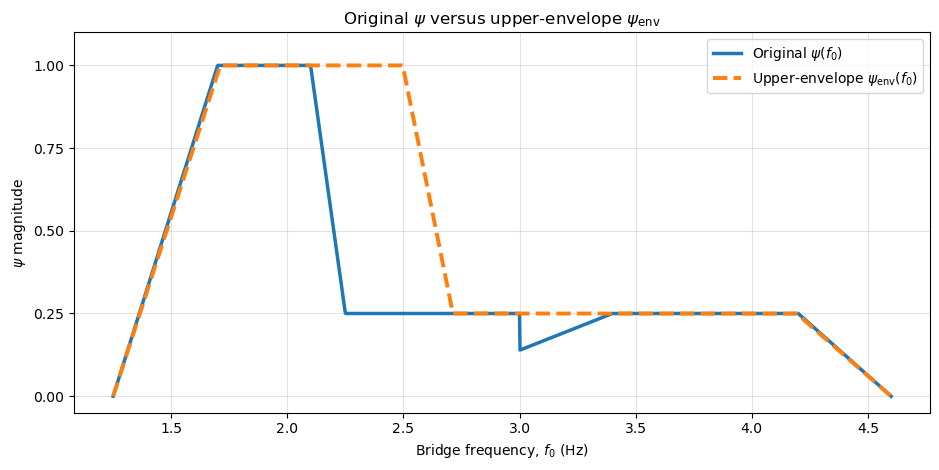

Loading: density1.0000_damping0.005_lm1000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm1500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm2000_bias_summary.pkl
Loading: density1.0000_damping0.005_lm500_bias_summary.pkl
Loading: density1.0000_damping0.005_lm750_bias_summary.pkl
Loading: density1.0000_damping0.010_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.010_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.010_lm483_bias_summary.pkl
Loading: density1.0000_damping0.010_lm580_bias_summary.pkl
Loading: density1.0000_damping0.010_lm725_bias_summary.pkl
Loading: density1.0000_damping0.010_lm967_bias_summary.pkl
Loading: density1.0000_damping0.015_lm1450_bias_summary.pkl
Loading: density1.0000_damping0.015_lm2900_bias_summary.pkl
Loading: density1.0000_damping0.015_lm483_bias_summary.pkl
Loading: density1.0000_damping0.015_lm580_bias_summary.pkl
Loading: density1.0000_damping0.015_lm725_bias_summary.pkl
Loading: density1.0000_damping0.015_lm967_bias_su

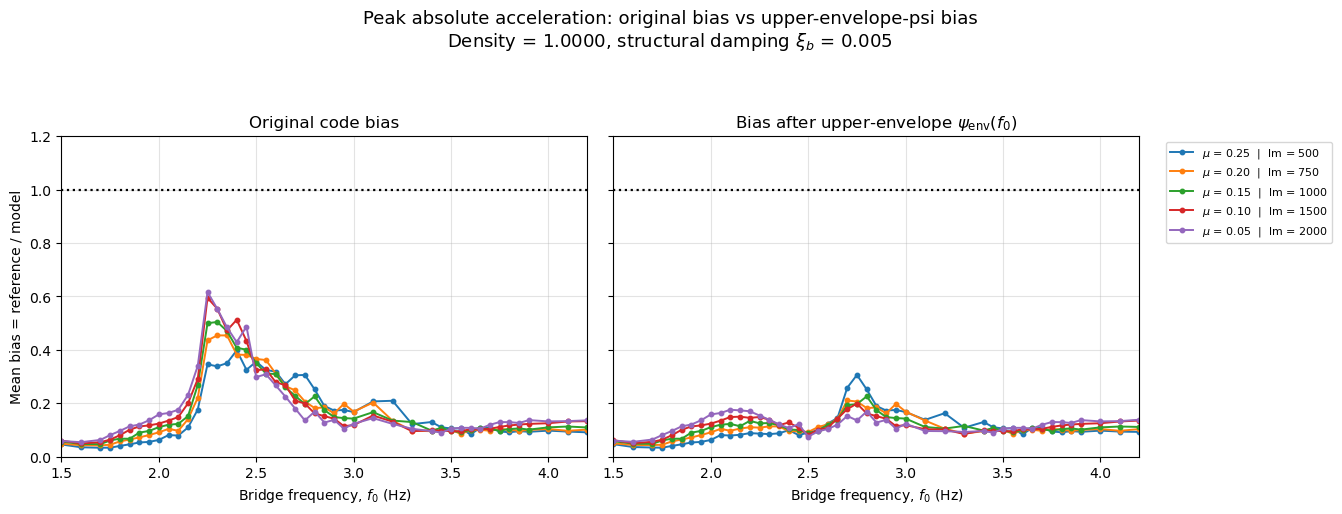

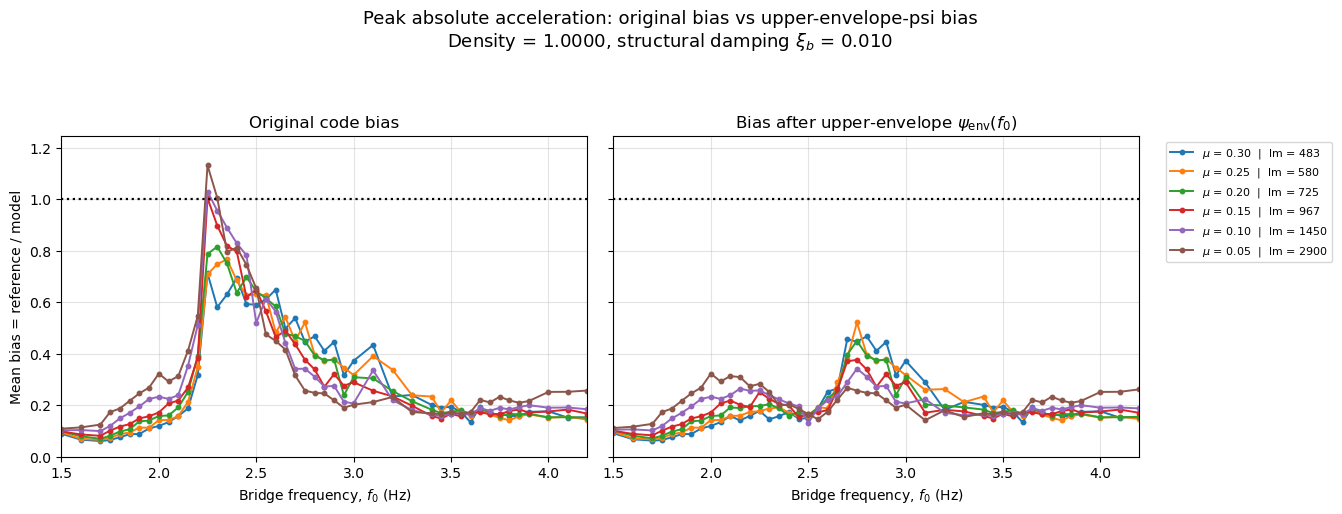

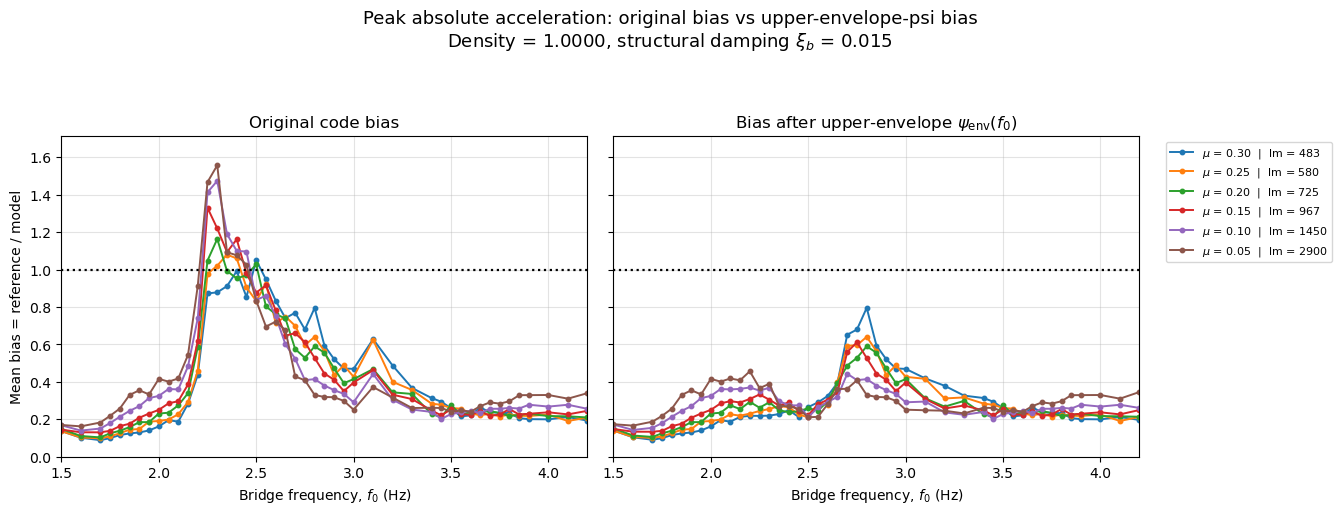

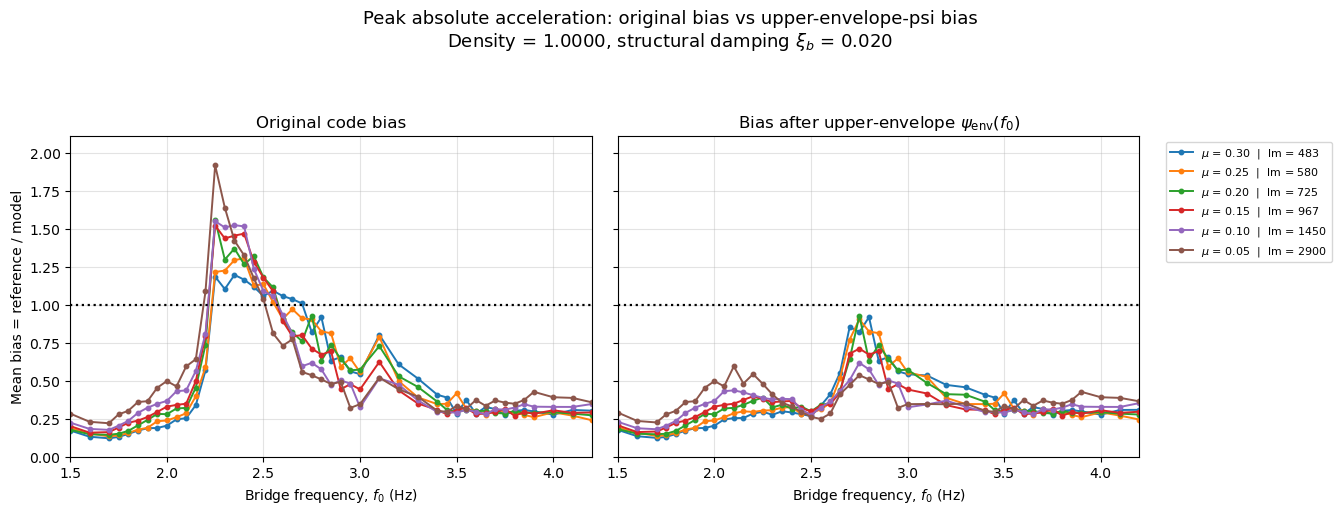

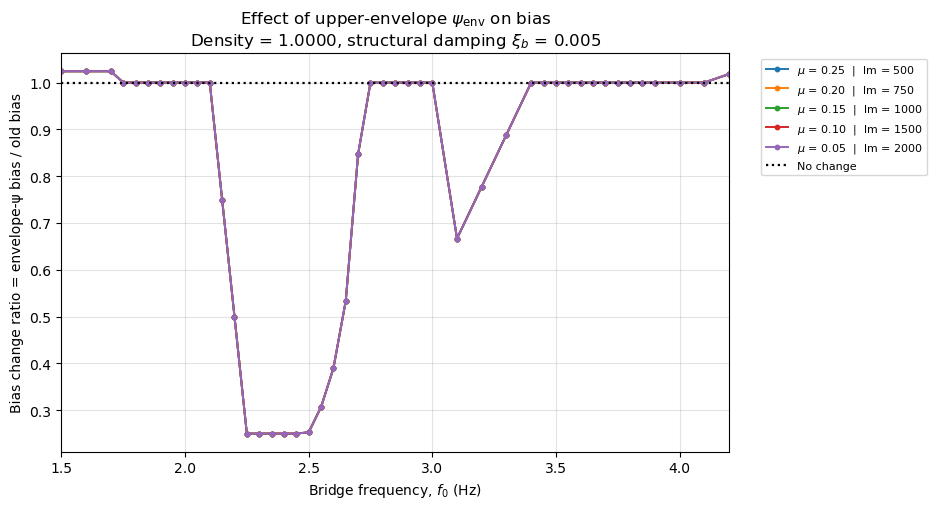

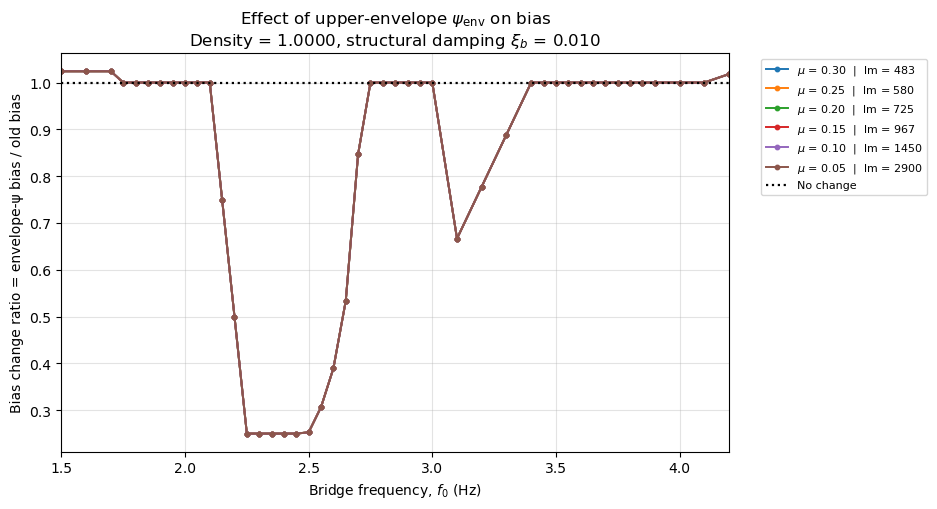

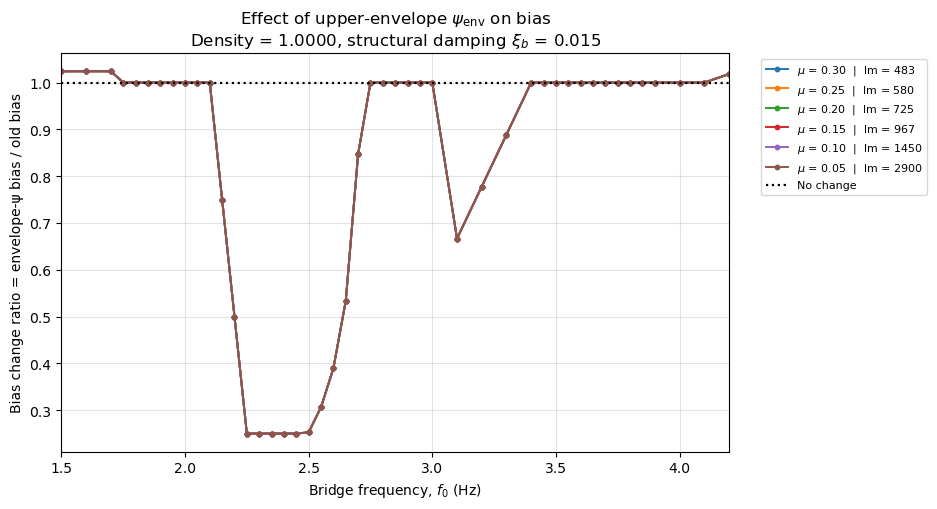

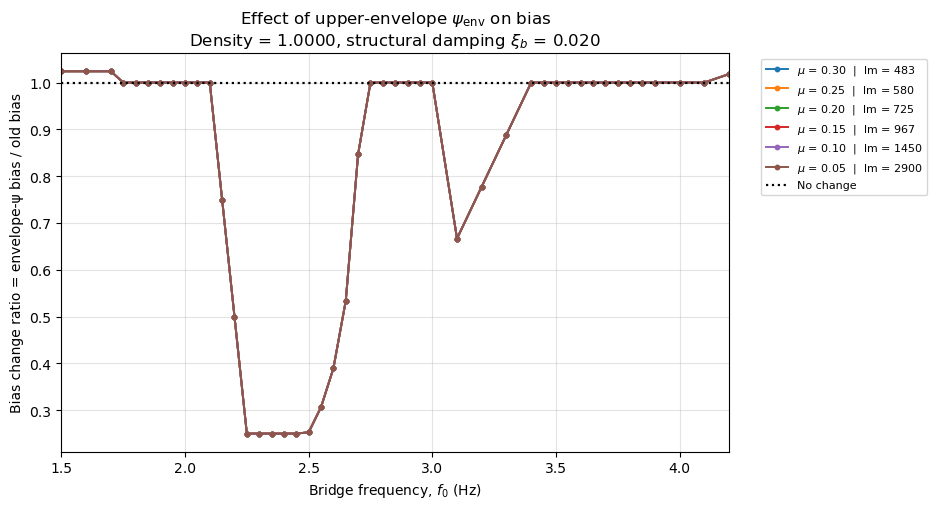


Summary table:
 damping_key  linear_mass_key  mass_ratio  old_bias_mean  env_bias_mean  old_bias_max  env_bias_max  mean_bias_change_ratio
       0.005              500        0.25       0.160823       0.108266      0.398131      0.306204                0.831589
       0.005              750        0.20       0.167101       0.108297      0.454150      0.210449                0.831589
       0.005             1000        0.15       0.173092       0.112188      0.504448      0.226072                0.831589
       0.005             1500        0.10       0.181362       0.116096      0.594561      0.198859                0.831589
       0.005             2000        0.05       0.184129       0.119601      0.616419      0.175922                0.831589
       0.010              483        0.30       0.291698       0.195941      0.712788      0.467535                0.831589
       0.010              580        0.25       0.296683       0.196153      0.766111      0.521570                0

In [21]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DENSITY = 1.0000

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# Use None to load all damping ratios found:
# TARGET_DAMPINGS = None

MEASURE_TO_USE = "Peak absolute acceleration"

# This is the column you plotted as original bias / correction factor
OLD_BIAS_COL = "final_modification_factor"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

SAVE_FIGURES = False
FIG_DPI = 300

PSI_EPS = 1e-8


# ==================================================
# LINEAR MASS TO MASS RATIO
# Edit this table only if your lm values are different.
# ==================================================

linear_mass_to_mass_ratio = {
    483:  0.30,
    500:  0.30,

    580:  0.25,
    500:  0.25,

    725:  0.20,
    750:  0.20,

    967:  0.15,
    1000: 0.15,

    1450: 0.10,
    1500: 0.10,

    2000: 0.05,
    2900: 0.05,
}


# ==================================================
# ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# UPPER-ENVELOPE PSI FUNCTION
#
# Your suggested envelope:
#
# For 1.2500 <= f0 <= 1.7109: psi_env =  2.169878*f0 - 2.712347
# For 1.7109 <= f0 <= 2.4968: psi_env =  1.000000
# For 2.4968 <= f0 <= 2.7130: psi_env = -3.469281*f0 + 9.662183
# For 2.7130 <= f0 <= 4.1928: psi_env =  0.250000
# For 4.1928 <= f0 <= 4.6000: psi_env = -0.613906*f0 + 2.823967
# ==================================================

def psi_upper_envelope(f):
    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # Breakpoints
    f_start = 1.2500
    a = 1.7109
    b = 2.4968
    c = 2.7130
    d = 4.1928
    f_end = 4.6000

    # Segment 1: ramp from 0 to 1
    m = (f >= f_start) & (f < a)
    psi[m] = 2.169878 * f[m] - 2.712347

    # Segment 2: plateau at 1
    m = (f >= a) & (f < b)
    psi[m] = 1.0

    # Segment 3: ramp from 1 to 0.25
    m = (f >= b) & (f < c)
    psi[m] = -3.469281 * f[m] + 9.662183

    # Segment 4: plateau at 0.25
    m = (f >= c) & (f < d)
    psi[m] = 0.25

    # Segment 5: ramp from 0.25 to 0
    m = (f >= d) & (f <= f_end)
    psi[m] = -0.613906 * f[m] + 2.823967

    # Outside range: keep zero
    psi = np.clip(psi, 0.0, 1.0)

    return psi


# ==================================================
# QUICK CHECK: PLOT OLD PSI VS UPPER-ENVELOPE PSI
# ==================================================

f_check = np.linspace(1.25, 4.60, 1500)

plt.figure(figsize=(9.5, 4.8))

plt.plot(
    f_check,
    psi_original(f_check),
    linewidth=2.5,
    label=r"Original $\psi(f_0)$"
)

plt.plot(
    f_check,
    psi_upper_envelope(f_check),
    "--",
    linewidth=2.8,
    label=r"Upper-envelope $\psi_{\mathrm{env}}(f_0)$"
)

plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$ magnitude")
plt.title(r"Original $\psi$ versus upper-envelope $\psi_{\mathrm{env}}$")
plt.ylim(-0.05, 1.10)
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# LOAD lm BIAS FILES
# Expected:
# density1.0000_damping0.005_lm483_bias_summary.pkl
# density1.0000_damping0.005_lm500_bias_summary.pkl
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"lm(?P<linear_mass>\d+)_"
    r"bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_lm*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:

    match = pattern.match(file.name)

    if match is None:
        print("Skipping unmatched file:", file.name)
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_linear_mass = int(match.group("linear_mass"))

    if not np.isclose(file_density, TARGET_DENSITY):
        continue

    if TARGET_DAMPINGS is not None:
        if not any(np.isclose(file_damping, d) for d in TARGET_DAMPINGS):
            continue

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["linear_mass"] = file_linear_mass

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching lm bias summary files found.")

raw_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded lm dataframe shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())


# ==================================================
# CLEAN lm DATA
# ==================================================

needed_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "linear_mass",
    OLD_BIAS_COL,
]

for col in needed_cols:
    if col not in raw_df.columns:
        raise KeyError(f"Missing required column: {col}")

    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_df = raw_df.dropna(subset=needed_cols).copy()

# Keep peak absolute acceleration only
if "measure" in raw_df.columns:
    raw_df = raw_df[
        raw_df["measure"].astype(str).str.strip().eq(MEASURE_TO_USE)
    ].copy()

    if raw_df.empty:
        raise ValueError(
            f"No rows found for measure = '{MEASURE_TO_USE}'."
        )

raw_df["damping_key"] = raw_df["target_beamdamp"].round(3)
raw_df["linear_mass_key"] = raw_df["linear_mass"].round(0).astype(int)

raw_df = raw_df[
    (raw_df["bridge_frequency"] >= PLOT_FMIN) &
    (raw_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

# Stable mass-ratio label from lm
raw_df["mass_ratio"] = raw_df["linear_mass_key"].map(linear_mass_to_mass_ratio)

missing_lm = sorted(
    raw_df.loc[raw_df["mass_ratio"].isna(), "linear_mass_key"].unique()
)

if len(missing_lm) > 0:
    raise ValueError(
        "These linear masses are missing from linear_mass_to_mass_ratio:\n"
        f"{missing_lm}\n\n"
        "Add them to the dictionary near the top."
    )

# Average only exact duplicate points
compare_df = (
    raw_df
    .groupby(
        ["damping_key", "linear_mass_key", "mass_ratio", "bridge_frequency"],
        as_index=False
    )
    .agg(old_bias=(OLD_BIAS_COL, "mean"))
    .sort_values(
        ["damping_key", "linear_mass_key", "bridge_frequency"]
    )
)

print("\nFinal comparison dataframe shape:", compare_df.shape)

print("\nAvailable lm and mass-ratio mapping:")
print(
    compare_df[["linear_mass_key", "mass_ratio"]]
    .drop_duplicates()
    .sort_values("mass_ratio", ascending=False)
    .to_string(index=False)
)

print("\nFrequency coverage:")
coverage = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print(coverage)


# ==================================================
# COMPUTE BIAS IF UPPER-ENVELOPE PSI IS USED
# ==================================================

compare_df["psi_old"] = psi_original(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

compare_df["psi_env"] = psi_upper_envelope(
    compare_df["bridge_frequency"].to_numpy(dtype=float)
)

psi_old_safe = np.maximum(
    compare_df["psi_old"].to_numpy(dtype=float),
    PSI_EPS
)

psi_env_safe = np.maximum(
    compare_df["psi_env"].to_numpy(dtype=float),
    PSI_EPS
)

# Model_new = Model_old * psi_env / psi_old
# Bias = Reference / Model
# Therefore:
# Bias_new = Bias_old * psi_old / psi_env

compare_df["env_bias"] = (
    compare_df["old_bias"] * psi_old_safe / psi_env_safe
)

compare_df["bias_ratio_env_over_old"] = (
    compare_df["env_bias"] / compare_df["old_bias"]
)

compare_df["psi_scale_env_over_old"] = (
    psi_env_safe / psi_old_safe
)

compare_df.to_csv(
    "old_vs_upper_envelope_psi_bias_from_lm_files.csv",
    index=False
)

print("\nSaved: old_vs_upper_envelope_psi_bias_from_lm_files.csv")


# ==================================================
# PLOT OLD BIAS VS UPPER-ENVELOPE-PSI BIAS
# One figure per damping ratio.
# Each figure has all lm / mass-ratio lines.
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    if damp_df.empty:
        continue

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13.5, 5.2),
        sharex=True,
        sharey=True
    )

    plot_specs = [
        ("old_bias", "Original code bias"),
        ("env_bias", r"Bias after upper-envelope $\psi_{\mathrm{env}}(f_0)$"),
    ]

    for ax, (y_col, title) in zip(axes, plot_specs):

        for lm in sorted(damp_df["linear_mass_key"].unique()):

            sub = damp_df[
                damp_df["linear_mass_key"] == lm
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            mu = sub["mass_ratio"].iloc[0]

            ax.plot(
                sub["bridge_frequency"],
                sub[y_col],
                marker="o",
                markersize=3.2,
                linewidth=1.4,
                label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
            )

        ax.axhline(
            1.0,
            linestyle=":",
            linewidth=1.6,
            color="black"
        )

        ax.set_title(title)
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")
        ax.grid(True, alpha=0.35)
        ax.set_xlim(PLOT_FMIN, PLOT_FMAX)

    axes[0].set_ylabel("Mean bias = reference / model")

    ymax = np.nanmax(
        damp_df[["old_bias", "env_bias"]].to_numpy()
    )

    axes[0].set_ylim(0, max(1.2, 1.10 * ymax))

    axes[1].legend(
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        fontsize=8,
        frameon=True
    )

    fig.suptitle(
        "Peak absolute acceleration: original bias vs upper-envelope-psi bias\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    if SAVE_FIGURES:
        save_name = (
            f"old_vs_upper_envelope_psi_bias_"
            f"density{TARGET_DENSITY:.4f}_damping{damping:.3f}.png"
        )
        plt.savefig(save_name, dpi=FIG_DPI, bbox_inches="tight")
        print("Saved:", save_name)

    plt.show()


# ==================================================
# OPTIONAL: PLOT HOW MUCH THE BIAS CHANGES
# env_bias / old_bias
# ==================================================

for damping in sorted(compare_df["damping_key"].unique()):

    damp_df = compare_df[
        np.isclose(compare_df["damping_key"], damping)
    ].copy()

    plt.figure(figsize=(9.5, 5.2))

    for lm in sorted(damp_df["linear_mass_key"].unique()):

        sub = damp_df[
            damp_df["linear_mass_key"] == lm
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mu = sub["mass_ratio"].iloc[0]

        plt.plot(
            sub["bridge_frequency"],
            sub["bias_ratio_env_over_old"],
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=rf"$\mu$ = {mu:.2f}  |  lm = {lm}"
        )

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=1.6,
        color="black",
        label="No change"
    )

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Bias change ratio = envelope-ψ bias / old bias")

    plt.title(
        r"Effect of upper-envelope $\psi_{\mathrm{env}}$ on bias"
        "\n"
        rf"Density = {TARGET_DENSITY:.4f}, structural damping $\xi_b$ = {damping:.3f}"
    )

    plt.xlim(PLOT_FMIN, PLOT_FMAX)
    plt.grid(True, alpha=0.35)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()


# ==================================================
# OPTIONAL: SUMMARY TABLE
# ==================================================

summary_df = (
    compare_df
    .groupby(["damping_key", "linear_mass_key", "mass_ratio"], as_index=False)
    .agg(
        old_bias_mean=("old_bias", "mean"),
        env_bias_mean=("env_bias", "mean"),
        old_bias_max=("old_bias", "max"),
        env_bias_max=("env_bias", "max"),
        mean_bias_change_ratio=("bias_ratio_env_over_old", "mean"),
    )
    .sort_values(["damping_key", "mass_ratio"], ascending=[True, False])
)

print("\nSummary table:")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    "summary_upper_envelope_psi_bias_effect.csv",
    index=False
)

print("\nSaved: summary_upper_envelope_psi_bias_effect.csv")


SECOND LOAD MODEL — ORIGINAL vs ROUNDED C

Original equation:
C = 0.097 + 20 xi_b + 61.4 mu xi_b

Rounded equation:
C = 0.10 + 20 xi_b + 60 mu xi_b

C_original range: 0.2653 to 0.9184
C_rounded range: 0.3150 to 0.9600

Maximum absolute difference in C: 0.049650
Maximum relative difference in C: 18.711%
Maximum absolute difference in resulting bias: 0.120576


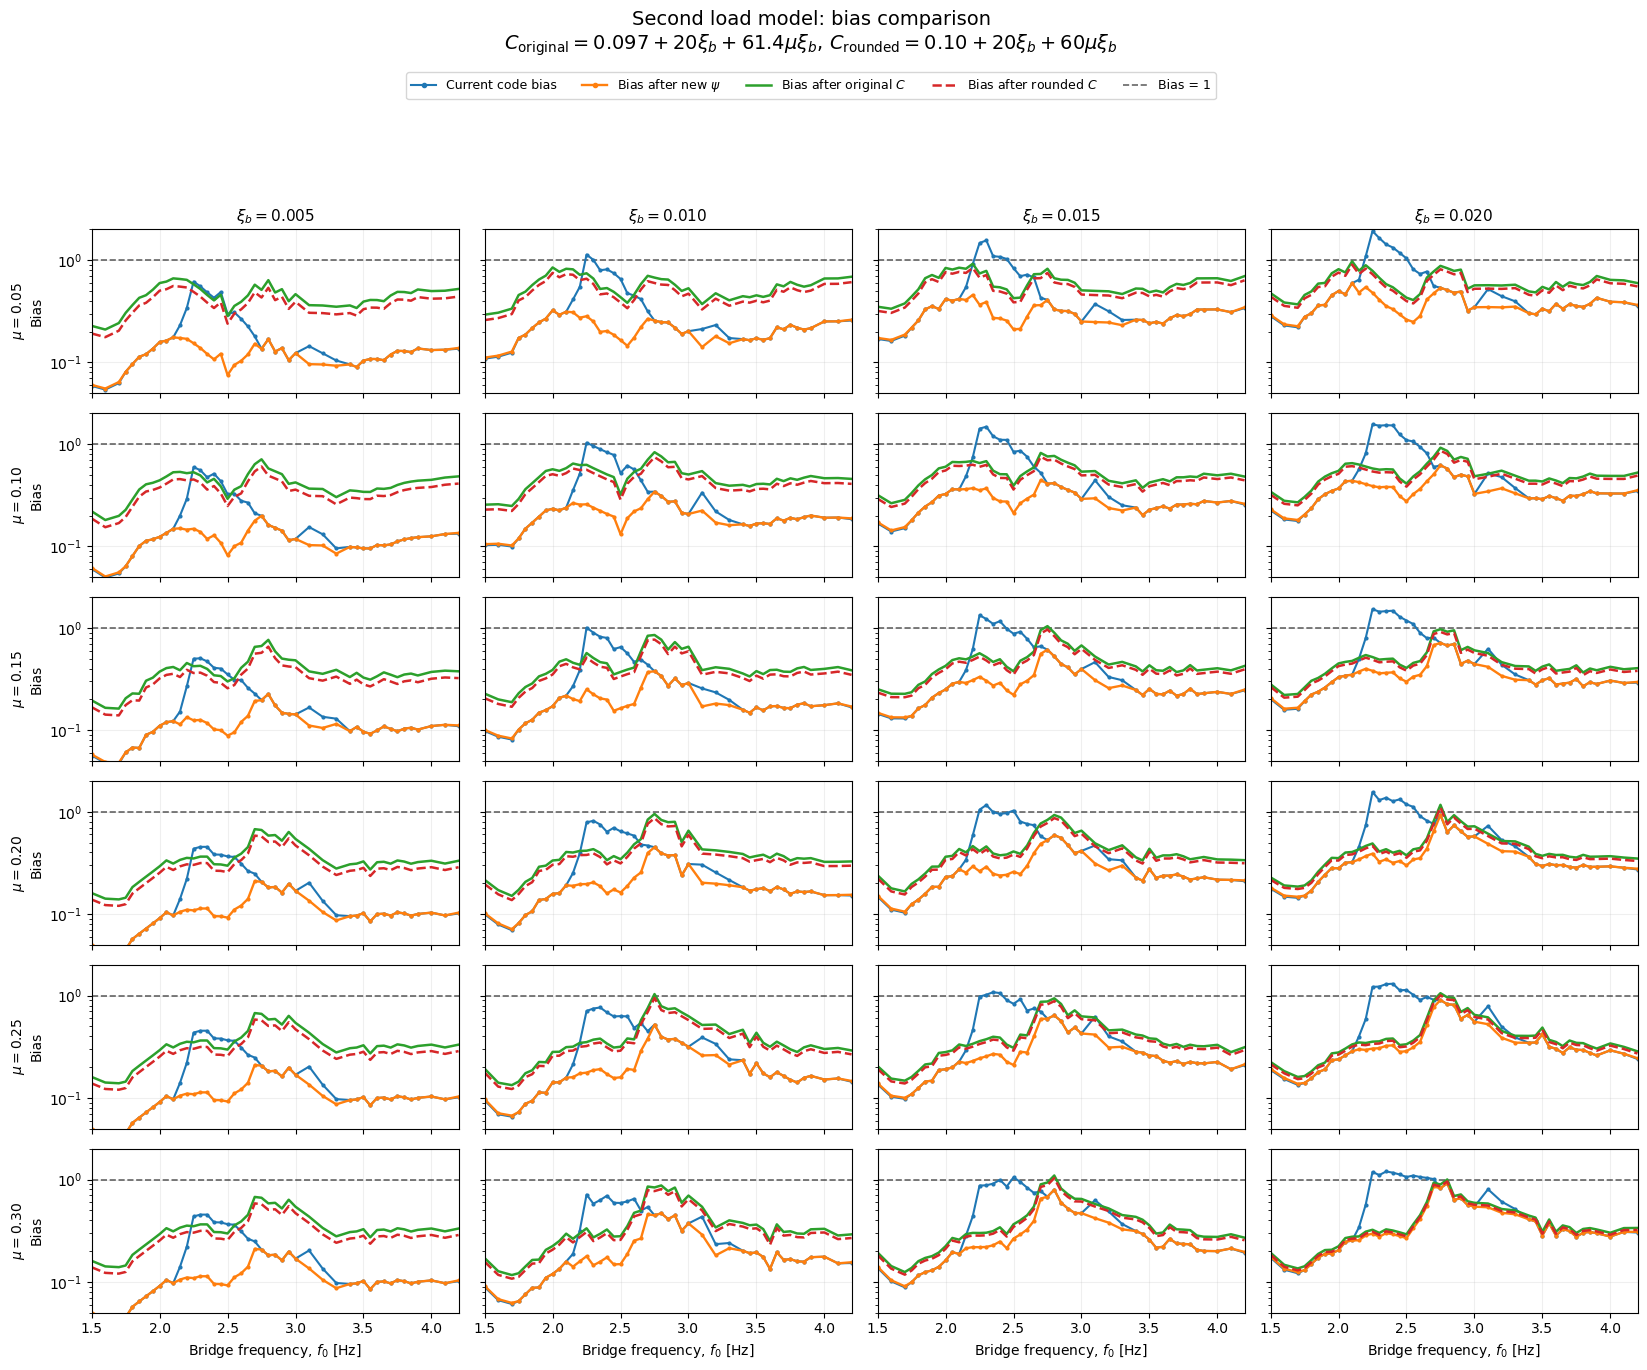

In [33]:
# ============================================================
# SECOND LOAD MODEL
#
# COMPARE:
#
# 1. ORIGINAL CODE BIAS
# 2. BIAS AFTER NEW psi
# 3. BIAS AFTER ORIGINAL C EQUATION
# 4. BIAS AFTER ROUNDED C EQUATION
#
# Original:
#
# C = 0.097 + 20 xi_b + 61.4 mu xi_b
#
# Rounded:
#
# C = 0.10 + 20 xi_b + 60 mu xi_b
#
# B_final = B_after_psi / C
#
# SPECIAL PLOT RULE:
#
# Panel labelled:
#
#     mu = 0.25, xi_b = 0.005
#
# will deliberately repeat the curves from:
#
#     mu = 0.30, xi_b = 0.005
#
# Plot range:
#
#     1.50 <= f <= 4.20 Hz
#
# Damping ratios shown:
#
#     0.005, 0.010, 0.015, 0.020
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# ============================================================
# 1. COPY CURRENT SECOND-LOAD-MODEL DATA
# ============================================================

if "compare_df" not in globals():

    raise NameError(
        "compare_df does not exist.\n"
        "Run the first second-load-model code first."
    )


comparison_df = compare_df.copy()


# ============================================================
# 2. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [

    "bridge_frequency",

    "damping_key",

    "mass_ratio",

    "old_bias",

    "env_bias",
]


missing_columns = [

    column

    for column in required_columns

    if column not in comparison_df.columns
]


if missing_columns:

    raise KeyError(
        "Missing required columns in compare_df:\n"
        f"{missing_columns}"
    )


# ============================================================
# 3. CREATE STANDARD DAMPING COLUMN
# ============================================================

comparison_df[
    "target_beamdamp"
] = pd.to_numeric(

    comparison_df[
        "damping_key"
    ],

    errors="coerce"
)


# ============================================================
# 4. NUMERICAL ARRAYS
# ============================================================

mu = comparison_df[
    "mass_ratio"
].to_numpy(
    dtype=float
)


xi = comparison_df[
    "target_beamdamp"
].to_numpy(
    dtype=float
)


# ============================================================
# 5. ORIGINAL SECOND-LOAD-MODEL C
#
# C = 0.097 + 20 xi_b + 61.4 mu xi_b
# ============================================================

comparison_df[
    "C_original"
] = (

    0.15

    +

    20.0 * xi

    +

    61.4 * mu * xi
)


# ============================================================
# 6. ROUNDED SECOND-LOAD-MODEL C
#
# C = 0.10 + 20 xi_b + 60 mu xi_b
# ============================================================

comparison_df[
    "C_rounded"
] = (

    0.20

    +

    20.0 * xi

    +

    60.0 * mu * xi
)


# ============================================================
# 7. APPLY C TO BIAS
#
# env_bias = bias after new psi
#
# B_final = B_after_psi / C
# ============================================================

comparison_df[
    "bias_original_C"
] = np.where(

    comparison_df[
        "C_original"
    ] > 0,

    comparison_df[
        "env_bias"
    ]

    /

    comparison_df[
        "C_original"
    ],

    np.nan
)


comparison_df[
    "bias_rounded_C"
] = np.where(

    comparison_df[
        "C_rounded"
    ] > 0,

    comparison_df[
        "env_bias"
    ]

    /

    comparison_df[
        "C_rounded"
    ],

    np.nan
)


# ============================================================
# 8. NUMERICAL DIFFERENCE BETWEEN EQUATIONS
# ============================================================

comparison_df[
    "C_difference"
] = (

    comparison_df[
        "C_rounded"
    ]

    -

    comparison_df[
        "C_original"
    ]
)


comparison_df[
    "C_relative_difference_pct"
] = (

    100.0

    *

    comparison_df[
        "C_difference"
    ]

    /

    comparison_df[
        "C_original"
    ]
)


comparison_df[
    "bias_difference"
] = (

    comparison_df[
        "bias_rounded_C"
    ]

    -

    comparison_df[
        "bias_original_C"
    ]
)


# ============================================================
# 9. NUMERICAL CHECK
# ============================================================

print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — ORIGINAL vs ROUNDED C"
)

print(
    "============================================================"
)


print(
    "\nOriginal equation:"
)

print(
    "C = 0.097 + 20 xi_b + 61.4 mu xi_b"
)


print(
    "\nRounded equation:"
)

print(
    "C = 0.10 + 20 xi_b + 60 mu xi_b"
)


print(
    "\nC_original range:"
    f" {comparison_df['C_original'].min():.4f}"
    f" to {comparison_df['C_original'].max():.4f}"
)


print(
    "C_rounded range:"
    f" {comparison_df['C_rounded'].min():.4f}"
    f" to {comparison_df['C_rounded'].max():.4f}"
)


print(
    "\nMaximum absolute difference in C:"
    f" {comparison_df['C_difference'].abs().max():.6f}"
)


print(
    "Maximum relative difference in C:"
    f" "
    f"{comparison_df['C_relative_difference_pct'].abs().max():.3f}%"
)


print(
    "Maximum absolute difference in resulting bias:"
    f" "
    f"{comparison_df['bias_difference'].abs().max():.6f}"
)


# ============================================================
# 10. FREQUENCY RANGE
#
# ALL BIAS CURVES:
#
#       1.50 <= f <= 4.20 Hz
# ============================================================

PLOT_FMIN_SECOND = 1.50

PLOT_FMAX_SECOND = 4.20


plot_df = comparison_df[

    (
        comparison_df[
            "bridge_frequency"
        ]
        >=
        PLOT_FMIN_SECOND
    )

    &

    (
        comparison_df[
            "bridge_frequency"
        ]
        <=
        PLOT_FMAX_SECOND
    )

].copy()


# ============================================================
# 11. MASS RATIOS
# ============================================================

MASS_RATIOS_TO_PLOT = [

    0.05,

    0.10,

    0.15,

    0.20,

    0.25,

    0.30,
]


# ============================================================
# 12. DAMPING RATIOS
#
# 0.025 AND 0.030 REMOVED
# ============================================================

DAMPINGS_TO_PLOT = [

    0.005,

    0.010,

    0.015,

    0.020,
]


# ============================================================
# 13. PLOT COLOURS
# ============================================================

COLOR_CODE = "C0"

COLOR_NEW_PSI = "C1"

COLOR_ORIGINAL_C = "C2"

COLOR_ROUNDED_C = "C3"
# ============================================================
# 14. COMMON FIGURE
#
# ONLY ONE FINAL FIGURE
# 6 mass-ratio rows x 4 damping columns
# ============================================================

nrows = len(MASS_RATIOS_TO_PLOT)
ncols = len(DAMPINGS_TO_PLOT)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(17, 14),
    sharex=True,
    sharey=True
)


# ============================================================
# SPECIAL REPEATED CURVES
#
# Repeat mu = 0.20, xi = 0.005 data in:
#
#     mu = 0.25, xi = 0.005
#     mu = 0.30, xi = 0.005
# ============================================================

REPEAT_SOURCE_MU = 0.20

REPEAT_TARGETS = [
    (0.25, 0.005),
    (0.30, 0.005),
]


# ============================================================
# 15. DRAW EACH PANEL
# ============================================================

for row, mass_ratio in enumerate(MASS_RATIOS_TO_PLOT):

    for col, damping in enumerate(DAMPINGS_TO_PLOT):

        ax = axes[row, col]


        # ====================================================
        # DETERMINE SOURCE DATA
        # ====================================================

        is_repeat_panel = any(
            np.isclose(mass_ratio, target_mu)
            and
            np.isclose(damping, target_xi)

            for target_mu, target_xi
            in REPEAT_TARGETS
        )


        if is_repeat_panel:

            source_mass_ratio = REPEAT_SOURCE_MU
            source_damping = 0.005

        else:

            source_mass_ratio = mass_ratio
            source_damping = damping


        # ====================================================
        # SELECT DATA
        # ====================================================

        sub = plot_df[
            np.isclose(
                plot_df["mass_ratio"],
                source_mass_ratio
            )
            &
            np.isclose(
                plot_df["target_beamdamp"],
                source_damping
            )
        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        # ====================================================
        # BIAS = 1
        # ====================================================

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1.2,
            color="black",
            alpha=0.6
        )


        # ====================================================
        # PLOT CURVES
        # ====================================================

        if not sub.empty:


            # ------------------------------------------------
            # CURRENT CODE
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["old_bias"],
                linewidth=1.5,
                marker="o",
                markersize=2.0,
                color=COLOR_CODE,
                label="Current code"
            )


            # ------------------------------------------------
            # NEW psi
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["env_bias"],
                linewidth=1.7,
                marker="o",
                markersize=2.0,
                color=COLOR_NEW_PSI,
                label=r"New $\psi$"
            )


            # ------------------------------------------------
            # ORIGINAL C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_original_C"],
                linewidth=1.8,
                color=COLOR_ORIGINAL_C,
                label=r"New $\psi$ + original $C$"
            )


            # ------------------------------------------------
            # ROUNDED C
            # ------------------------------------------------

            ax.plot(
                sub["bridge_frequency"],
                sub["bias_rounded_C"],
                linewidth=1.8,
                linestyle="--",
                color=COLOR_ROUNDED_C,
                label=r"New $\psi$ + rounded $C$"
            )


        # ====================================================
        # COLUMN TITLE = DAMPING
        # ====================================================

        if row == 0:

            ax.set_title(
                rf"$\xi_b={damping:.3f}$",
                fontsize=11
            )


        # ====================================================
        # ROW LABEL = DISPLAYED MASS RATIO
        # ====================================================

        if col == 0:

            ax.set_ylabel(
                rf"$\mu={mass_ratio:.2f}$"
                "\nBias",
                fontsize=10
            )


        # ====================================================
        # X LABEL
        # ====================================================

        if row == nrows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ [Hz]",
                fontsize=10
            )


        # ====================================================
        # X AXIS
        #
        # 1.50 – 4.20 Hz
        # ====================================================

        ax.set_xlim(
            1.50,
            4.20
        )


        # ====================================================
        # Y AXIS
        #
        # LINEAR SCALE
        # START = 0
        # END   = 2

        # ====================================================
        # Logarithmic y-axis
        ax.set_yscale("log")

        ax.set_ylim(
            0.05,
            2.0
        )




        # ====================================================
        # GRID
        # ====================================================

        ax.grid(
            True,
            alpha=0.20
        )


# ============================================================
# 16. COMMON TITLE
# ============================================================

fig.suptitle(
    "Second load model: bias comparison\n"
    r"$C_{\mathrm{original}}"
    r"=0.097+20\xi_b+61.4\mu\xi_b$, "
    r"$C_{\mathrm{rounded}}"
    r"=0.10+20\xi_b+60\mu\xi_b$",
    fontsize=14,
    y=0.995
)


# ============================================================
# 17. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COLOR_CODE,
        linewidth=1.5,
        marker="o",
        markersize=3,
        label="Current code bias"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_NEW_PSI,
        linewidth=1.7,
        marker="o",
        markersize=3,
        label=r"Bias after new $\psi$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ORIGINAL_C,
        linewidth=1.8,
        label=r"Bias after original $C$"
    ),

    Line2D(
        [0],
        [0],
        color=COLOR_ROUNDED_C,
        linewidth=1.8,
        linestyle="--",
        label=r"Bias after rounded $C$"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.6,
        label="Bias = 1"
    ),
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=5,
    fontsize=9,
    frameon=True
)


# ============================================================
# 18. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0.02,
        0.02,
        0.995,
        0.91
    ]
)

plt.show()

In [31]:
# ============================================================
# 4. DEFINE THE TWO C EQUATIONS
#
# SECOND LOAD MODEL
#
# Original:
#
# C = 0.097 + 20 xi_b + 61.4 mu xi_b
#
# Rounded:
#
# C = 0.10 + 20 xi_b + 60 mu xi_b
# ============================================================

def C_original(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (
        0.097
        +
        20.0 * xi
        +
        61.4 * mu * xi
    )


def C_rounded(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (
        0.10
        +
        20.0 * xi
        +
        60.0 * mu * xi
    )


BIAS SURFACE USED FOR POPULATION CALCULATION

Rows = 920
Frequency = 1.500 – 4.200 Hz
Damping = 0.0050 – 0.0200
Mass ratio = 0.050 – 0.250

Original-C interpolator = RegularGridInterpolator
Rounded-C interpolator  = RegularGridInterpolator

FREQUENCY POPULATION HIERARCHY

All bridges = 250
VSA bridges = 160
HSI-frequency bridges = 142

P(VSA) = 0.640000 = 64.000%
P(HSI | VSA) = 0.887500 = 88.750%

Mass-ratio-supported materials:
['Steel', 'Concrete', 'Steel-concrete composite', 'FRP', 'Other']

COMMON MONTE CARLO POPULATION

Total HSI draws = 300,000
Valid xi-mu draws = 102,831
P(valid xi-mu domain | HSI) = 34.2770%

Common valid draws for both equations = 102,831

SECOND LOAD MODEL — ORIGINAL C vs ROUNDED C — JOINT POPULATION RESULT

  Equation  N valid  N Bias>1  P(Bias>1 | valid HSI domain) [%]  P(valid AND Bias>1 | HSI) [%]  P(assessed Bias>1 | VSA) [%]  P(assessed Bias>1 | all bridges) [%]
Original C   102831        13                          0.012642                       0.004

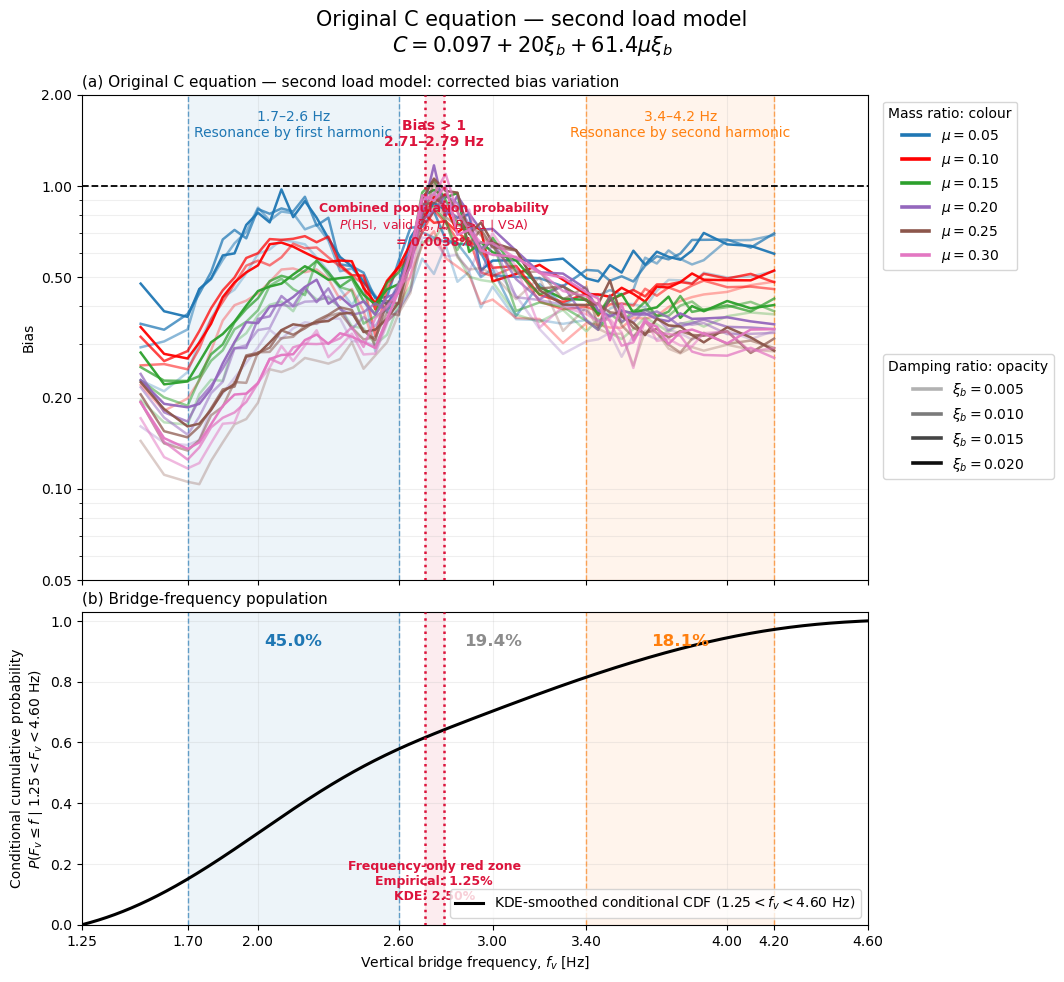

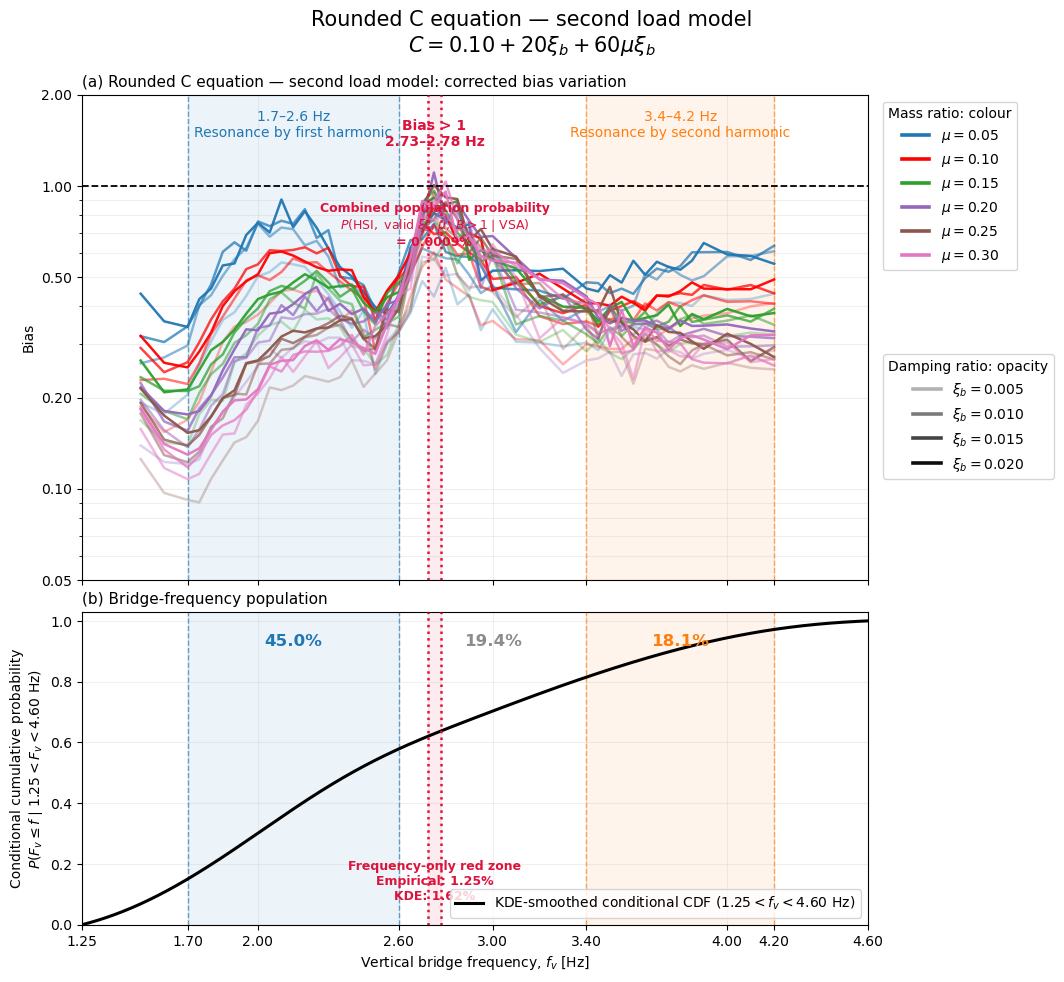


FINAL COMPARISON

Original C
----------
Frequency-only red zone(s): [(2.7112656253405483, 2.790876976216938)]
Frequency-only empirical probability | VSA = 1.2500%
Frequency-only KDE probability | VSA = 2.4960%
P(Bias>1 | valid HSI domain) = 0.0126%
P(valid domain AND Bias>1 | HSI) = 0.0043%
P(assessed Bias>1 | VSA) = 0.0038%
P(assessed Bias>1 | all bridges) = 0.0025%

Rounded C
---------
Frequency-only red zone(s): [(2.7263412341875775, 2.7780736938322383)]
Frequency-only empirical probability | VSA = 1.2500%
Frequency-only KDE probability | VSA = 1.6201%
P(Bias>1 | valid HSI domain) = 0.0029%
P(valid domain AND Bias>1 | HSI) = 0.0010%
P(assessed Bias>1 | VSA) = 0.0009%
P(assessed Bias>1 | all bridges) = 0.0006%


In [35]:
# ============================================================
# SECOND LOAD MODEL — ORIGINAL-C vs ROUNDED-C
# JOINT POPULATION UNDERPREDICTION ASSESSMENT
#
# REQUIRED EXISTING VARIABLE:
#
#     comparison_df
#
# This cell:
#
#   1. starts ONLY from comparison_df
#   2. rebuilds the bridge population
#   3. generates ONE set of Monte Carlo population draws
#   4. applies EXACTLY THE SAME draws to both C equations
#   5. calculates:
#
#        - frequency-only red-zone probability
#        - P(Bias > 1 | valid HSI domain)
#        - P(valid domain AND Bias > 1 | HSI)
#        - P(assessed Bias > 1 | VSA)
#        - P(assessed Bias > 1 | all bridges)
#
#   6. creates TWO red-zone figures:
#
#        Figure 1: Original C equation
#        Figure 2: Rounded C equation
#
# Underprediction:
#
#        Bias > 1
#
# ============================================================


import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from scipy.interpolate import (
    RegularGridInterpolator,
    LinearNDInterpolator
)

from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid


# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_SEED = 42

N_SAMPLES = 300_000

BIAS_THRESHOLD = 1.0


MEASURE_TO_USE = (
    "Peak absolute acceleration"
)


# ------------------------------------------------------------
# Population hierarchy
# ------------------------------------------------------------

VSA_FMIN = 1.25
VSA_FMAX = 4.60

HSI_FMIN = 1.50
HSI_FMAX = 4.20


XI_MODEL_MIN = 0.005
XI_MODEL_MAX = 0.020

MU_MODEL_MIN = 0.05
MU_MODEL_MAX = 0.25


# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

DAMPING_CSV = (
    "master_all_bridges_vertical_damping_frequency_span_material.csv"
)

MU_PBOX_CSV = (
    "pbox_pymc_material_weighted_mass_ratio.csv"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

SAVE_PLOTS = False

USE_LOG_Y = True


# ============================================================
# 2. CHECK comparison_df
# ============================================================

if "comparison_df" not in globals():

    raise NameError(
        "comparison_df does not exist.\n"
        "Run your Original-C / Rounded-C comparison cell first."
    )


required_columns = [

    "bridge_frequency",

    "target_beamdamp",

    "mass_ratio",
]


missing_columns = [

    column

    for column in required_columns

    if column not in comparison_df.columns
]


if missing_columns:

    raise KeyError(
        "comparison_df is missing:\n"
        f"{missing_columns}"
    )


# ============================================================
# 3. PREPARE COMPARISON DATA
# ============================================================

bias_df = comparison_df.copy()


for column in [

    "bridge_frequency",

    "target_beamdamp",

    "mass_ratio",
]:

    bias_df[column] = pd.to_numeric(
        bias_df[column],
        errors="coerce"
    )


# ------------------------------------------------------------
# Peak acceleration only
# ------------------------------------------------------------

if "measure" in bias_df.columns:

    measure_mask = (

        bias_df["measure"]
        .astype(str)
        .str.strip()

        ==

        MEASURE_TO_USE
    )

    if np.any(measure_mask):

        bias_df = bias_df[
            measure_mask
        ].copy()


# ============================================================
# 4. DEFINE THE TWO C EQUATIONS
#
# SECOND LOAD MODEL
#
# Original:
#
#     C = 0.097 + 20 xi_b + 61.4 mu xi_b
#
# Rounded:
#
#     C = 0.10 + 20 xi_b + 60 mu xi_b
# ============================================================

def C_original(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (

        0.15

        +

        20.0 * xi

        +

        61.4 * mu * xi
    )


def C_rounded(mu, xi):

    mu = np.asarray(
        mu,
        dtype=float
    )

    xi = np.asarray(
        xi,
        dtype=float
    )

    return (

        0.20

        +

        20.0 * xi

        +

        60.0 * mu * xi
    )


# ============================================================
# 5. FIND psi-CORRECTED BIAS
#
# For the second load model, the first-stage code stores the
# bias after the upper-envelope psi as:
#
#     env_bias
#
# The other column names are retained as fallbacks so this
# cell is still robust if an earlier dataframe version is used.
# ============================================================

if "env_bias" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "env_bias"
        ],

        errors="coerce"
    )


elif "newpsi_bias_mean" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "newpsi_bias_mean"
        ],

        errors="coerce"
    )


elif "newpsi_code_bias_mean" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "newpsi_code_bias_mean"
        ],

        errors="coerce"
    )


elif "bias_after_psi" in bias_df.columns:

    bias_df[
        "bias_after_psi"
    ] = pd.to_numeric(

        bias_df[
            "bias_after_psi"
        ],

        errors="coerce"
    )


else:

    raise KeyError(

        "comparison_df must contain one of:\n"

        "  env_bias\n"
        "  newpsi_bias_mean\n"
        "  newpsi_code_bias_mean\n"
        "  bias_after_psi"
    )


# ============================================================
# 6. RECALCULATE BOTH FINAL BIASES
#
# IMPORTANT:
#
# Do it here again so there is absolutely no ambiguity about
# which C equation belongs to which bias.
# ============================================================

mu_array = bias_df[
    "mass_ratio"
].to_numpy(
    dtype=float
)


xi_array = bias_df[
    "target_beamdamp"
].to_numpy(
    dtype=float
)


bias_df[
    "C_original"
] = C_original(
    mu_array,
    xi_array
)


bias_df[
    "C_rounded"
] = C_rounded(
    mu_array,
    xi_array
)


bias_df[
    "bias_original_C"
] = (

    bias_df[
        "bias_after_psi"
    ]

    /

    bias_df[
        "C_original"
    ]
)


bias_df[
    "bias_rounded_C"
] = (

    bias_df[
        "bias_after_psi"
    ]

    /

    bias_df[
        "C_rounded"
    ]
)


bias_df = bias_df.dropna(

    subset=[

        "bridge_frequency",

        "target_beamdamp",

        "mass_ratio",

        "bias_original_C",

        "bias_rounded_C",
    ]

).copy()


# ============================================================
# 7. DOMAIN USED FOR THE JOINT PROBABILITY
# ============================================================

model_bias_df = bias_df[

    (
        bias_df[
            "bridge_frequency"
        ]
        >=
        HSI_FMIN
    )

    &

    (
        bias_df[
            "bridge_frequency"
        ]
        <=
        HSI_FMAX
    )

    &

    (
        bias_df[
            "target_beamdamp"
        ]
        >=
        XI_MODEL_MIN
    )

    &

    (
        bias_df[
            "target_beamdamp"
        ]
        <=
        XI_MODEL_MAX
    )

    &

    (
        bias_df[
            "mass_ratio"
        ]
        >=
        MU_MODEL_MIN
    )

    &

    (
        bias_df[
            "mass_ratio"
        ]
        <=
        MU_MODEL_MAX
    )

].copy()


# Average any accidental duplicate points

model_bias_df = (

    model_bias_df

    .groupby(

        [
            "bridge_frequency",
            "target_beamdamp",
            "mass_ratio",
        ],

        as_index=False
    )

    .agg({

        "bias_original_C":
            "mean",

        "bias_rounded_C":
            "mean",
    })
)


print(
    "\n============================================================"
)

print(
    "BIAS SURFACE USED FOR POPULATION CALCULATION"
)

print(
    "============================================================"
)

print(
    f"\nRows = {len(model_bias_df):,}"
)

print(
    f"Frequency = "
    f"{model_bias_df['bridge_frequency'].min():.3f}"
    f" – "
    f"{model_bias_df['bridge_frequency'].max():.3f} Hz"
)

print(
    f"Damping = "
    f"{model_bias_df['target_beamdamp'].min():.4f}"
    f" – "
    f"{model_bias_df['target_beamdamp'].max():.4f}"
)

print(
    f"Mass ratio = "
    f"{model_bias_df['mass_ratio'].min():.3f}"
    f" – "
    f"{model_bias_df['mass_ratio'].max():.3f}"
)


# ============================================================
# 8. BUILD 3-D INTERPOLATORS
#
# coordinates:
#
#       frequency × damping × mass ratio
#
# ============================================================

def build_bias_interpolator(
    data,
    value_column
):

    f_grid = np.sort(
        data[
            "bridge_frequency"
        ].unique()
    )

    xi_grid = np.sort(
        data[
            "target_beamdamp"
        ].unique()
    )

    mu_grid = np.sort(
        data[
            "mass_ratio"
        ].unique()
    )


    full_index = pd.MultiIndex.from_product(

        [
            f_grid,
            xi_grid,
            mu_grid
        ],

        names=[

            "bridge_frequency",

            "target_beamdamp",

            "mass_ratio",
        ]
    )


    grid_series = (

        data

        .set_index(

            [
                "bridge_frequency",
                "target_beamdamp",
                "mass_ratio",
            ]

        )[value_column]

        .reindex(
            full_index
        )
    )


    # --------------------------------------------------------
    # Complete rectangular grid
    # --------------------------------------------------------

    if not grid_series.isna().any():

        cube = (

            grid_series
            .to_numpy(
                dtype=float
            )
            .reshape(

                len(f_grid),
                len(xi_grid),
                len(mu_grid)
            )
        )


        interpolator = RegularGridInterpolator(

            (
                f_grid,
                xi_grid,
                mu_grid
            ),

            cube,

            method="linear",

            bounds_error=False,

            fill_value=np.nan
        )


        def evaluate(points):

            return np.asarray(
                interpolator(points),
                dtype=float
            )


        interpolation_type = (
            "RegularGridInterpolator"
        )


    # --------------------------------------------------------
    # Fallback for incomplete grid
    # --------------------------------------------------------

    else:

        points = data[

            [
                "bridge_frequency",
                "target_beamdamp",
                "mass_ratio",
            ]

        ].to_numpy(
            dtype=float
        )


        values = data[
            value_column
        ].to_numpy(
            dtype=float
        )


        interpolator = LinearNDInterpolator(

            points,

            values,

            fill_value=np.nan
        )


        def evaluate(points):

            return np.asarray(
                interpolator(points),
                dtype=float
            )


        interpolation_type = (
            "LinearNDInterpolator"
        )


    return (
        evaluate,
        interpolation_type
    )


evaluate_original_bias, original_interp_type = (
    build_bias_interpolator(

        model_bias_df,

        "bias_original_C"
    )
)


evaluate_rounded_bias, rounded_interp_type = (
    build_bias_interpolator(

        model_bias_df,

        "bias_rounded_C"
    )
)


print(
    f"\nOriginal-C interpolator = "
    f"{original_interp_type}"
)

print(
    f"Rounded-C interpolator  = "
    f"{rounded_interp_type}"
)


# ============================================================
# 9. HELPER FUNCTIONS FOR POPULATION DATA
# ============================================================

def clean_numeric(series):

    s = series.astype(str)

    s = s.str.replace(
        "−",
        "-",
        regex=False
    )

    s = s.str.replace(
        "–",
        "-",
        regex=False
    )

    s = s.str.replace(
        "%",
        "",
        regex=False
    )

    s = s.str.replace(
        ",",
        "",
        regex=False
    )

    s = s.str.extract(
        r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"
    )[0]

    return pd.to_numeric(
        s,
        errors="coerce"
    )


def clean_damping(series):

    raw = series.astype(str)

    raw = raw.str.replace(
        "−",
        "-",
        regex=False
    )

    raw = raw.str.replace(
        "–",
        "-",
        regex=False
    )

    raw = raw.str.replace(
        "%",
        "",
        regex=False
    )


    output = []


    for value in raw:

        numbers = re.findall(

            r"\d*\.?\d+(?:[eE][-+]?\d+)?",

            value
        )


        if len(numbers) == 0:

            output.append(
                np.nan
            )


        elif (

            len(numbers) >= 2

            and

            (
                "-" in value
                or
                "to" in value.lower()
            )

        ):

            output.append(

                np.mean(
                    [
                        float(numbers[0]),
                        float(numbers[1])
                    ]
                )
            )


        else:

            output.append(
                float(numbers[0])
            )


    z = pd.Series(

        output,

        index=series.index,

        dtype=float
    )


    # 0.43 means 0.43%, therefore 0.0043

    percent_like = (

        z.notna()

        &

        (z > 0.20)

        &

        (z <= 20.0)
    )


    z.loc[
        percent_like
    ] /= 100.0


    impossible = (

        z.notna()

        &

        (
            (z <= 0.0)

            |

            (z > 0.20)
        )
    )


    z.loc[
        impossible
    ] = np.nan


    return z


# ============================================================
# 10. MATERIAL CLEANER
# ============================================================

MATERIAL_ORDER = [

    "Steel",

    "Concrete",

    "Steel-concrete composite",

    "FRP",

    "Timber",

    "Other",
]


def clean_material(x):

    s = str(x).strip().lower()


    if s in [

        "",
        "nan",
        "none",
        "-",
        "unknown",
        "other",
        "other types",
    ]:

        return "Other"


    if (

        "frp" in s

        or "gfrp" in s

        or "fiber" in s

        or "fibre" in s

        or "fiberglass" in s

        or "fibreglass" in s

        or "glass fibre" in s

        or "glass fiber" in s
    ):

        return "FRP"


    if (

        "timber" in s

        or "wood" in s

        or "wooden" in s
    ):

        return "Timber"


    if (

        (
            "steel" in s

            and

            "concrete" in s
        )

        or

        "steel-concrete" in s

        or

        "steel concrete" in s

        or

        "composite" in s

        or

        "mixed steel" in s
    ):

        return "Steel-concrete composite"


    if (

        "concrete" in s

        or

        "reinforced concrete" in s

        or

        s == "rc"
    ):

        return "Concrete"


    if (

        "steel" in s

        or

        "warren" in s

        or

        "bow-string" in s

        or

        "suspended" in s
    ):

        return "Steel"


    return "Other"


def safe_material_name(material):

    return (

        material

        .lower()

        .replace(
            " ",
            "_"
        )

        .replace(
            "-",
            "_"
        )
    )


# ============================================================
# 11. CHECK POPULATION FILES
# ============================================================

for filename in [

    DAMPING_CSV,

    MU_PBOX_CSV,
]:

    if not os.path.exists(
        filename
    ):

        raise FileNotFoundError(

            f"Cannot find:\n{filename}\n\n"

            f"Current folder:\n"
            f"{os.getcwd()}"
        )


# ============================================================
# 12. LOAD BRIDGE FREQUENCY / DAMPING POPULATION
# ============================================================

population_df = pd.read_csv(

    DAMPING_CSV,

    encoding="utf-8-sig"
)


population_df = (

    population_df

    .dropna(
        how="all"
    )

    .copy()
)


# ============================================================
# 13. FREQUENCY
# ============================================================

if "first_vertical_frequency_Hz" in population_df.columns:

    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "first_vertical_frequency_Hz"
        ]
    )


elif "vertical_natural_frequency_Hz" in population_df.columns:

    population_df[
        "frequency"
    ] = clean_numeric(

        population_df[
            "vertical_natural_frequency_Hz"
        ]
    )


else:

    raise KeyError(
        "No vertical-frequency column found."
    )


# ============================================================
# 14. MATERIAL
# ============================================================

if "material_used" in population_df.columns:

    material_column = (
        "material_used"
    )


elif "girder_material" in population_df.columns:

    material_column = (
        "girder_material"
    )


elif "material_group" in population_df.columns:

    material_column = (
        "material_group"
    )


else:

    raise KeyError(
        "No material column found."
    )


population_df[
    "material"
] = (

    population_df[
        material_column
    ]

    .apply(
        clean_material
    )
)


# ============================================================
# 15. DAMPING
# ============================================================

if "vertical_damping_ratio" in population_df.columns:

    population_df[
        "observed_damping"
    ] = clean_damping(

        population_df[
            "vertical_damping_ratio"
        ]
    )


else:

    population_df[
        "observed_damping"
    ] = np.nan


# ------------------------------------------------------------
# Was damping observed?
# ------------------------------------------------------------

if "damping_observed" in population_df.columns:

    flag = (

        population_df[
            "damping_observed"
        ]

        .astype(str)

        .str.strip()

        .str.lower()
    )


    population_df[
        "damping_observed_flag"
    ] = flag.isin(

        [
            "true",
            "1",
            "yes",
        ]
    )


else:

    population_df[
        "damping_observed_flag"
    ] = (

        population_df[
            "observed_damping"
        ].notna()
    )


# ------------------------------------------------------------
# Bayesian-imputed damping mean
# ------------------------------------------------------------

if "zeta_imputed_mean" in population_df.columns:

    population_df[
        "imputed_mean"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_mean"
        ]
    )


else:

    population_df[
        "imputed_mean"
    ] = np.nan


# ------------------------------------------------------------
# Bayesian-imputed damping SD
# ------------------------------------------------------------

if "zeta_imputed_sd" in population_df.columns:

    population_df[
        "imputed_sd"
    ] = clean_numeric(

        population_df[
            "zeta_imputed_sd"
        ]
    )


else:

    population_df[
        "imputed_sd"
    ] = np.nan


# ------------------------------------------------------------
# Fallback completed damping
# ------------------------------------------------------------

if "zeta_completed_mean" in population_df.columns:

    completed_mean = clean_numeric(

        population_df[
            "zeta_completed_mean"
        ]
    )


    missing_imputed = (

        population_df[
            "imputed_mean"
        ].isna()
    )


    population_df.loc[

        missing_imputed,

        "imputed_mean"

    ] = completed_mean.loc[
        missing_imputed
    ]


# ============================================================
# 16. KEEP BRIDGES WITH USABLE FREQUENCY
# ============================================================

population_df = population_df[

    np.isfinite(

        population_df[
            "frequency"
        ]
    )

].copy()


population_df = population_df.reset_index(
    drop=True
)


N_ALL = len(
    population_df
)


# ============================================================
# 17. VSA POPULATION
#
# 1.25 < f < 4.60
# ============================================================

vsa_mask = (

    (
        population_df[
            "frequency"
        ]
        >
        VSA_FMIN
    )

    &

    (
        population_df[
            "frequency"
        ]
        <
        VSA_FMAX
    )
)


vsa_df = (

    population_df[
        vsa_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_VSA = len(
    vsa_df
)


P_VSA = (

    N_VSA

    /

    N_ALL
)


# ============================================================
# 18. HSI FREQUENCY POPULATION
#
# 1.50 < f < 4.20
# ============================================================

hsi_mask = (

    (
        vsa_df[
            "frequency"
        ]
        >
        HSI_FMIN
    )

    &

    (
        vsa_df[
            "frequency"
        ]
        <
        HSI_FMAX
    )
)


hsi_df = (

    vsa_df[
        hsi_mask
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


N_HSI = len(
    hsi_df
)


P_HSI_GIVEN_VSA = (

    N_HSI

    /

    N_VSA
)


print(
    "\n============================================================"
)

print(
    "FREQUENCY POPULATION HIERARCHY"
)

print(
    "============================================================"
)

print(
    f"\nAll bridges = {N_ALL}"
)

print(
    f"VSA bridges = {N_VSA}"
)

print(
    f"HSI-frequency bridges = {N_HSI}"
)

print(
    f"\nP(VSA) = "
    f"{P_VSA:.6f} "
    f"= {100*P_VSA:.3f}%"
)

print(
    f"P(HSI | VSA) = "
    f"{P_HSI_GIVEN_VSA:.6f} "
    f"= {100*P_HSI_GIVEN_VSA:.3f}%"
)


# ============================================================
# 19. MASS-RATIO BAYESIAN P-BOX
# ============================================================

mu_pbox_df = pd.read_csv(

    MU_PBOX_CSV,

    encoding="utf-8-sig"
)


mu_pbox_df[
    "T"
] = pd.to_numeric(

    mu_pbox_df[
        "T"
    ],

    errors="coerce"
)


mu_pbox_df = (

    mu_pbox_df

    .dropna(
        subset=["T"]
    )

    .sort_values(
        "T"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 20. BUILD MATERIAL-SPECIFIC MASS-RATIO MODELS
# ============================================================

mu_models = {}


for material in MATERIAL_ORDER:

    safe = safe_material_name(
        material
    )


    theta_column = (
        f"{safe}_theta_mean"
    )


    n_known_column = (
        f"{safe}_n_known"
    )


    if theta_column not in mu_pbox_df.columns:

        continue


    if n_known_column not in mu_pbox_df.columns:

        continue


    n_known_values = pd.to_numeric(

        mu_pbox_df[
            n_known_column
        ],

        errors="coerce"

    ).dropna()


    if len(
        n_known_values
    ) == 0:

        continue


    n_known = int(

        round(
            n_known_values.iloc[0]
        )
    )


    # No data = prior only.
    # Do not fabricate a material-specific mu distribution.

    if n_known <= 0:

        continue


    T_saved = pd.to_numeric(

        mu_pbox_df[
            "T"
        ],

        errors="coerce"

    ).to_numpy(
        dtype=float
    )


    F_saved = pd.to_numeric(

        mu_pbox_df[
            theta_column
        ],

        errors="coerce"

    ).to_numpy(
        dtype=float
    )


    valid = (

        np.isfinite(
            T_saved
        )

        &

        np.isfinite(
            F_saved
        )
    )


    T_saved = T_saved[
        valid
    ]


    F_saved = F_saved[
        valid
    ]


    order = np.argsort(
        T_saved
    )


    T_saved = T_saved[
        order
    ]


    F_saved = F_saved[
        order
    ]


    F_saved = np.maximum.accumulate(
        F_saved
    )


    F_saved = np.clip(
        F_saved,
        0.0,
        1.0
    )


    F_mu_min = float(

        np.interp(

            MU_MODEL_MIN,

            T_saved,

            F_saved
        )
    )


    F_mu_max = float(

        np.interp(

            MU_MODEL_MAX,

            T_saved,

            F_saved
        )
    )


    P_inside = max(

        0.0,

        F_mu_max
        -
        F_mu_min
    )


    if P_inside <= 1e-12:

        continue


    internal_T = T_saved[

        (
            T_saved
            >
            MU_MODEL_MIN
        )

        &

        (
            T_saved
            <
            MU_MODEL_MAX
        )
    ]


    edges = np.unique(

        np.concatenate(

            [
                [MU_MODEL_MIN],

                internal_T,

                [MU_MODEL_MAX]
            ]
        )
    )


    F_edges = np.interp(

        edges,

        T_saved,

        F_saved
    )


    F_edges = np.maximum.accumulate(
        F_edges
    )


    weights = np.diff(
        F_edges
    )


    weights = np.maximum(
        weights,
        0.0
    )


    if np.sum(
        weights
    ) <= 1e-12:

        continue


    weights = (

        weights

        /

        np.sum(
            weights
        )
    )


    mu_models[
        material
    ] = {

        "P_inside":
            P_inside,

        "edges":
            edges,

        "weights":
            weights,

        "n_known":
            n_known,
    }


print(
    "\nMass-ratio-supported materials:"
)

print(
    list(
        mu_models.keys()
    )
)


# ============================================================
# 21. DAMPING SAMPLER
# ============================================================

def sample_lognormal_from_mean_sd(
    mean,
    sd,
    rng
):

    mean = np.asarray(
        mean,
        dtype=float
    )


    sd = np.asarray(
        sd,
        dtype=float
    )


    output = np.full(

        len(mean),

        np.nan,

        dtype=float
    )


    deterministic = (

        np.isfinite(
            mean
        )

        &

        (mean > 0)

        &

        (
            ~np.isfinite(
                sd
            )

            |

            (sd <= 0)
        )
    )


    output[
        deterministic
    ] = mean[
        deterministic
    ]


    stochastic = (

        np.isfinite(
            mean
        )

        &

        (mean > 0)

        &

        np.isfinite(
            sd
        )

        &

        (sd > 0)
    )


    if np.any(
        stochastic
    ):

        m = mean[
            stochastic
        ]


        s = sd[
            stochastic
        ]


        sigma_squared_log = np.log(

            1.0

            +

            (
                s / m
            )**2
        )


        sigma_log = np.sqrt(
            sigma_squared_log
        )


        mu_log = (

            np.log(
                m
            )

            -

            0.5
            *
            sigma_squared_log
        )


        output[
            stochastic
        ] = rng.lognormal(

            mean=
                mu_log,

            sigma=
                sigma_log
        )


    return output


# ============================================================
# 22. GENERATE ONE SET OF MONTE CARLO DRAWS
#
# THESE DRAWS WILL BE USED FOR BOTH EQUATIONS.
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)


sample_indices = rng.choice(

    hsi_df.index.to_numpy(),

    size=N_SAMPLES,

    replace=True
)


sample_df = (

    hsi_df.loc[
        sample_indices
    ]

    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Frequency and material
# ------------------------------------------------------------

f_samples = sample_df[
    "frequency"
].to_numpy(
    dtype=float
)


material_samples = sample_df[
    "material"
].to_numpy()


# ------------------------------------------------------------
# Damping
# ------------------------------------------------------------

observed_flag = sample_df[
    "damping_observed_flag"
].to_numpy(
    dtype=bool
)


observed_xi = sample_df[
    "observed_damping"
].to_numpy(
    dtype=float
)


imputed_mean = sample_df[
    "imputed_mean"
].to_numpy(
    dtype=float
)


imputed_sd = sample_df[
    "imputed_sd"
].to_numpy(
    dtype=float
)


xi_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


use_observed = (

    observed_flag

    &

    np.isfinite(
        observed_xi
    )
)


xi_samples[
    use_observed
] = observed_xi[
    use_observed
]


use_imputed = (
    ~use_observed
)


xi_samples[
    use_imputed
] = sample_lognormal_from_mean_sd(

    mean=
        imputed_mean[
            use_imputed
        ],

    sd=
        imputed_sd[
            use_imputed
        ],

    rng=rng
)


# ------------------------------------------------------------
# Mass ratio
# ------------------------------------------------------------

material_mu_supported = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_inside = np.zeros(

    N_SAMPLES,

    dtype=bool
)


mu_samples = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


for material in np.unique(
    material_samples
):

    indices = np.flatnonzero(

        material_samples

        ==

        material
    )


    if material not in mu_models:

        continue


    material_mu_supported[
        indices
    ] = True


    model = mu_models[
        material
    ]


    # --------------------------------------------------------
    # First draw:
    #
    # Is this bridge inside 0.05 <= mu <= 0.25?
    # --------------------------------------------------------

    inside_local = (

        rng.random(
            len(indices)
        )

        <

        model[
            "P_inside"
        ]
    )


    inside_indices = indices[
        inside_local
    ]


    mu_inside[
        inside_indices
    ] = True


    if len(
        inside_indices
    ) == 0:

        continue


    # --------------------------------------------------------
    # Then sample mu conditional on being inside domain
    # --------------------------------------------------------

    weights = model[
        "weights"
    ]


    edges = model[
        "edges"
    ]


    selected_bins = rng.choice(

        np.arange(
            len(weights)
        ),

        size=
            len(
                inside_indices
            ),

        replace=True,

        p=weights
    )


    lower_edges = edges[
        selected_bins
    ]


    upper_edges = edges[
        selected_bins + 1
    ]


    mu_samples[
        inside_indices
    ] = rng.uniform(

        low=
            lower_edges,

        high=
            upper_edges
    )


# ============================================================
# 23. VALID DAMPING DOMAIN
# ============================================================

xi_inside = (

    np.isfinite(
        xi_samples
    )

    &

    (
        xi_samples
        >=
        XI_MODEL_MIN
    )

    &

    (
        xi_samples
        <=
        XI_MODEL_MAX
    )
)


# ============================================================
# 24. COMPLETE VALID HSI DOMAIN
# ============================================================

complete_domain = (

    material_mu_supported

    &

    mu_inside

    &

    xi_inside

    &

    np.isfinite(
        mu_samples
    )
)


print(
    "\n============================================================"
)

print(
    "COMMON MONTE CARLO POPULATION"
)

print(
    "============================================================"
)

print(
    f"\nTotal HSI draws = "
    f"{N_SAMPLES:,}"
)

print(
    f"Valid xi-mu draws = "
    f"{np.sum(complete_domain):,}"
)

print(
    f"P(valid xi-mu domain | HSI) = "
    f"{100*np.mean(complete_domain):.4f}%"
)


# ============================================================
# 25. EVALUATE BOTH BIAS SURFACES
#
# SAME points are passed to BOTH interpolators.
# ============================================================

evaluation_points = np.column_stack(

    [

        f_samples[
            complete_domain
        ],

        xi_samples[
            complete_domain
        ],

        mu_samples[
            complete_domain
        ],
    ]
)


sampled_bias_original = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


sampled_bias_rounded = np.full(

    N_SAMPLES,

    np.nan,

    dtype=float
)


sampled_bias_original[
    complete_domain
] = evaluate_original_bias(
    evaluation_points
)


sampled_bias_rounded[
    complete_domain
] = evaluate_rounded_bias(
    evaluation_points
)


# ============================================================
# 26. INTERPOLATION-VALID MASKS
# ============================================================

valid_original = (

    complete_domain

    &

    np.isfinite(
        sampled_bias_original
    )
)


valid_rounded = (

    complete_domain

    &

    np.isfinite(
        sampled_bias_rounded
    )
)


# ------------------------------------------------------------
# For a perfectly fair comparison, retain only points for
# which BOTH interpolators returned a value.
# ------------------------------------------------------------

common_valid = (

    valid_original

    &

    valid_rounded
)


print(
    f"\nCommon valid draws for both equations = "
    f"{np.sum(common_valid):,}"
)


# ============================================================
# 27. UNDERPREDICTION EVENTS
#
# Bias > 1
# ============================================================

exceed_original = (

    common_valid

    &

    (
        sampled_bias_original
        >
        BIAS_THRESHOLD
    )
)


exceed_rounded = (

    common_valid

    &

    (
        sampled_bias_rounded
        >
        BIAS_THRESHOLD
    )
)


# ============================================================
# 28. CALCULATE THE HIERARCHICAL PROBABILITIES
# ============================================================

def calculate_probabilities(
    exceedance,
    valid_mask
):

    N_valid = int(
        np.sum(
            valid_mask
        )
    )


    N_exceed = int(
        np.sum(
            exceedance
        )
    )


    # --------------------------------------------------------
    # Conditional on being inside the valid HSI xi-mu domain
    # --------------------------------------------------------

    P_exceed_given_valid = (

        N_exceed

        /

        N_valid
    )


    # --------------------------------------------------------
    # Combined probability within the HSI-frequency population:
    #
    # valid xi-mu domain AND Bias > 1
    # --------------------------------------------------------

    P_valid_and_exceed_given_HSI = (

        N_exceed

        /

        N_SAMPLES
    )


    # --------------------------------------------------------
    # Main result relative to VSA bridges
    # --------------------------------------------------------

    P_assessed_exceed_given_VSA = (

        P_HSI_GIVEN_VSA

        *

        P_valid_and_exceed_given_HSI
    )


    # --------------------------------------------------------
    # Relative to all bridges
    # --------------------------------------------------------

    P_assessed_exceed_all = (

        P_VSA

        *

        P_assessed_exceed_given_VSA
    )


    return {

        "N_valid":
            N_valid,

        "N_exceed":
            N_exceed,

        "P_exceed_given_valid":
            P_exceed_given_valid,

        "P_valid_and_exceed_given_HSI":
            P_valid_and_exceed_given_HSI,

        "P_assessed_exceed_given_VSA":
            P_assessed_exceed_given_VSA,

        "P_assessed_exceed_all":
            P_assessed_exceed_all,
    }


result_original = calculate_probabilities(

    exceed_original,

    common_valid
)


result_rounded = calculate_probabilities(

    exceed_rounded,

    common_valid
)


# ============================================================
# 29. DIRECT COMPARISON TABLE
# ============================================================

probability_comparison_df = pd.DataFrame({

    "Equation": [

        "Original C",

        "Rounded C",
    ],


    "N valid": [

        result_original[
            "N_valid"
        ],

        result_rounded[
            "N_valid"
        ],
    ],


    "N Bias>1": [

        result_original[
            "N_exceed"
        ],

        result_rounded[
            "N_exceed"
        ],
    ],


    "P(Bias>1 | valid HSI domain) [%]": [

        100.0
        *
        result_original[
            "P_exceed_given_valid"
        ],

        100.0
        *
        result_rounded[
            "P_exceed_given_valid"
        ],
    ],


    "P(valid AND Bias>1 | HSI) [%]": [

        100.0
        *
        result_original[
            "P_valid_and_exceed_given_HSI"
        ],

        100.0
        *
        result_rounded[
            "P_valid_and_exceed_given_HSI"
        ],
    ],


    "P(assessed Bias>1 | VSA) [%]": [

        100.0
        *
        result_original[
            "P_assessed_exceed_given_VSA"
        ],

        100.0
        *
        result_rounded[
            "P_assessed_exceed_given_VSA"
        ],
    ],


    "P(assessed Bias>1 | all bridges) [%]": [

        100.0
        *
        result_original[
            "P_assessed_exceed_all"
        ],

        100.0
        *
        result_rounded[
            "P_assessed_exceed_all"
        ],
    ],
})


print(
    "\n============================================================"
)

print(
    "SECOND LOAD MODEL — ORIGINAL C vs ROUNDED C — JOINT POPULATION RESULT"
)

print(
    "============================================================\n"
)


print(

    probability_comparison_df.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.6f}"
    )
)


# ============================================================
# 30. SAVE COMMON DRAWS
#
# joint_mc_df DID NOT NEED TO EXIST BEFORE THIS CELL.
#
# It is created HERE only for later diagnostics.
# ============================================================

joint_mc_df = pd.DataFrame({

    "frequency":
        f_samples,

    "material":
        material_samples,

    "damping":
        xi_samples,

    "mu":
        mu_samples,

    "material_mu_supported":
        material_mu_supported,

    "mu_inside_domain":
        mu_inside,

    "xi_inside_domain":
        xi_inside,

    "complete_domain":
        complete_domain,

    "common_valid":
        common_valid,

    "bias_original_C":
        sampled_bias_original,

    "bias_rounded_C":
        sampled_bias_rounded,

    "Bias_gt_1_original":
        exceed_original,

    "Bias_gt_1_rounded":
        exceed_rounded,
})


# ============================================================
# 31. CONDITIONAL FREQUENCY POPULATION FOR FIGURES
#
# CDF conditioned on:
#
#       1.25 < f < 4.60 Hz
# ============================================================

freq_vsa = (

    vsa_df[
        "frequency"
    ]

    .dropna()

    .to_numpy(
        dtype=float
    )
)


freq_vsa = np.sort(
    freq_vsa
)


kde_frequency = gaussian_kde(
    freq_vsa
)


cdf_x = np.linspace(

    VSA_FMIN,

    VSA_FMAX,

    2500
)


cdf_pdf = kde_frequency(
    cdf_x
)


cdf_y = cumulative_trapezoid(

    cdf_pdf,

    cdf_x,

    initial=0.0
)


cdf_y = (

    cdf_y

    /

    cdf_y[-1]
)


def conditional_kde_probability(
    lower,
    upper
):

    F_lower = np.interp(

        lower,

        cdf_x,

        cdf_y
    )


    F_upper = np.interp(

        upper,

        cdf_x,

        cdf_y
    )


    return max(

        0.0,

        float(
            F_upper
            -
            F_lower
        )
    )


def empirical_probability(
    lower,
    upper
):

    return float(

        np.mean(

            (
                freq_vsa
                >=
                lower
            )

            &

            (
                freq_vsa
                <=
                upper
            )
        )
    )


# ============================================================
# 32. FREQUENCY-ONLY RED-ZONE DETECTOR
#
# "Red zone" means:
#
# at least one VALID-domain mu-xi combination has Bias > 1.
#
# This is deliberately different from the joint probability.
#
# Frequency-only:
#
#      asks "which frequencies can underpredict?"
#
# Joint:
#
#      also weights xi_b and mu occurrence.
# ============================================================

def threshold_crossing(
    x1,
    y1,
    x2,
    y2,
    threshold=1.0
):

    if np.isclose(
        y1,
        y2
    ):

        return float(
            0.5
            *
            (
                x1 + x2
            )
        )


    return float(

        x1

        +

        (
            threshold - y1
        )

        *

        (
            x2 - x1
        )

        /

        (
            y2 - y1
        )
    )


def find_frequency_red_zones(
    data,
    bias_column
):

    temp = data[

        (
            data[
                "bridge_frequency"
            ]
            >=
            HSI_FMIN
        )

        &

        (
            data[
                "bridge_frequency"
            ]
            <=
            HSI_FMAX
        )

        &

        (
            data[
                "target_beamdamp"
            ]
            >=
            XI_MODEL_MIN
        )

        &

        (
            data[
                "target_beamdamp"
            ]
            <=
            XI_MODEL_MAX
        )

        &

        (
            data[
                "mass_ratio"
            ]
            >=
            MU_MODEL_MIN
        )

        &

        (
            data[
                "mass_ratio"
            ]
            <=
            MU_MODEL_MAX
        )

    ].copy()


    frequency_summary = (

        temp

        .groupby(
            "bridge_frequency"
        )[bias_column]

        .max()

        .reset_index(
            name="maximum_bias"
        )

        .sort_values(
            "bridge_frequency"
        )

        .reset_index(
            drop=True
        )
    )


    frequency = frequency_summary[
        "bridge_frequency"
    ].to_numpy(
        dtype=float
    )


    maximum_bias = frequency_summary[
        "maximum_bias"
    ].to_numpy(
        dtype=float
    )


    above = (

        maximum_bias

        >

        BIAS_THRESHOLD
    )


    start_indices = np.where(

        above

        &

        ~np.r_[
            False,
            above[:-1]
        ]

    )[0]


    end_indices = np.where(

        above

        &

        ~np.r_[
            above[1:],
            False
        ]

    )[0]


    intervals = []


    for start_index, end_index in zip(

        start_indices,

        end_indices
    ):


        # ----------------------------------------------------
        # Left crossing
        # ----------------------------------------------------

        if start_index == 0:

            lower = frequency[
                start_index
            ]


        else:

            lower = threshold_crossing(

                frequency[
                    start_index - 1
                ],

                maximum_bias[
                    start_index - 1
                ],

                frequency[
                    start_index
                ],

                maximum_bias[
                    start_index
                ],

                BIAS_THRESHOLD
            )


        # ----------------------------------------------------
        # Right crossing
        # ----------------------------------------------------

        if end_index == (
            len(frequency) - 1
        ):

            upper = frequency[
                end_index
            ]


        else:

            upper = threshold_crossing(

                frequency[
                    end_index
                ],

                maximum_bias[
                    end_index
                ],

                frequency[
                    end_index + 1
                ],

                maximum_bias[
                    end_index + 1
                ],

                BIAS_THRESHOLD
            )


        intervals.append(

            (
                max(
                    lower,
                    HSI_FMIN
                ),

                min(
                    upper,
                    HSI_FMAX
                )
            )
        )


    return intervals


red_zones_original = find_frequency_red_zones(

    model_bias_df,

    "bias_original_C"
)


red_zones_rounded = find_frequency_red_zones(

    model_bias_df,

    "bias_rounded_C"
)


# ============================================================
# 33. FREQUENCY-ONLY PROBABILITY FOR EACH EQUATION
# ============================================================

def red_zone_frequency_probabilities(
    intervals
):

    kde_total = 0.0

    empirical_total = 0.0


    for lower, upper in intervals:

        kde_total += (
            conditional_kde_probability(
                lower,
                upper
            )
        )


        empirical_total += (
            empirical_probability(
                lower,
                upper
            )
        )


    return (
        empirical_total,
        kde_total
    )


(
    empirical_red_original,
    kde_red_original

) = red_zone_frequency_probabilities(
    red_zones_original
)


(
    empirical_red_rounded,
    kde_red_rounded

) = red_zone_frequency_probabilities(
    red_zones_rounded
)


print(
    "\n============================================================"
)

print(
    "FREQUENCY-ONLY RED ZONES"
)

print(
    "============================================================"
)


print(
    "\nOriginal C:"
)

print(
    red_zones_original
)

print(
    f"Empirical P(red frequency | VSA) = "
    f"{100*empirical_red_original:.4f}%"
)

print(
    f"KDE P(red frequency | VSA) = "
    f"{100*kde_red_original:.4f}%"
)


print(
    "\nRounded C:"
)

print(
    red_zones_rounded
)

print(
    f"Empirical P(red frequency | VSA) = "
    f"{100*empirical_red_rounded:.4f}%"
)

print(
    f"KDE P(red frequency | VSA) = "
    f"{100*kde_red_rounded:.4f}%"
)


# ============================================================
# 34. BAND PERCENTAGES
# ============================================================

population_bands = [

    (
        1.70,
        2.60,
        "tab:blue"
    ),

    (
        2.60,
        3.40,
        "0.55"
    ),

    (
        3.40,
        4.20,
        "tab:orange"
    ),
]


band_percentages = {}


for lower, upper, colour in population_bands:

    probability = empirical_probability(
        lower,
        upper
    )


    band_percentages[
        (
            lower,
            upper
        )
    ] = probability


# ============================================================
# 35. PLOT SETTINGS
# ============================================================

mass_ratios_to_plot = [

    value

    for value in [

        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
    ]

    if np.any(

        np.isclose(

            bias_df[
                "mass_ratio"
            ],

            value
        )
    )
]


dampings_to_plot = [

    value

    for value in [

        0.005,
        0.010,
        0.015,
        0.020,
    ]

    if np.any(

        np.isclose(

            bias_df[
                "target_beamdamp"
            ],

            value
        )
    )
]


mu_colour_map = {

    0.05:
        "tab:blue",

    0.10:
        "red",

    0.15:
        "tab:green",

    0.20:
        "tab:purple",

    0.25:
        "tab:brown",

    0.30:
        "tab:pink",
}


alpha_values = np.linspace(

    0.30,

    0.95,

    max(
        len(
            dampings_to_plot
        ),
        1
    )
)


alpha_map = {

    damping:
        alpha

    for damping, alpha in zip(

        dampings_to_plot,

        alpha_values
    )
}


# ============================================================
# 36. PLOT FUNCTION
# ============================================================

def make_red_zone_figure(

    bias_column,

    equation_name,

    equation_text,

    intervals,

    empirical_frequency_probability,

    kde_frequency_probability,

    joint_result,

    output_filename
):

    fig, (
        ax_top,
        ax_bottom

    ) = plt.subplots(

        2,
        1,

        figsize=(
            12,
            10
        ),

        sharex=True,

        gridspec_kw={

            "height_ratios":
                [
                    1.55,
                    1.0
                ],

            "hspace":
                0.08
        }
    )


    # ========================================================
    # BACKGROUND RESONANCE BANDS
    # ========================================================

    for ax in [
        ax_top,
        ax_bottom
    ]:

        ax.axvspan(

            1.70,
            2.60,

            alpha=0.08,

            color="tab:blue"
        )


        ax.axvline(

            1.70,

            linestyle="--",

            linewidth=1.0,

            color="tab:blue",

            alpha=0.65
        )


        ax.axvline(

            2.60,

            linestyle="--",

            linewidth=1.0,

            color="tab:blue",

            alpha=0.65
        )


        ax.axvspan(

            3.40,
            4.20,

            alpha=0.08,

            color="tab:orange"
        )


        ax.axvline(

            3.40,

            linestyle="--",

            linewidth=1.0,

            color="tab:orange",

            alpha=0.65
        )


        ax.axvline(

            4.20,

            linestyle="--",

            linewidth=1.0,

            color="tab:orange",

            alpha=0.65
        )


    # ========================================================
    # RED ZONES
    # ========================================================

    for lower, upper in intervals:

        for ax in [
            ax_top,
            ax_bottom
        ]:

            ax.axvspan(

                lower,
                upper,

                color="crimson",

                alpha=0.08,

                zorder=0
            )


            ax.axvline(

                lower,

                color="crimson",

                linestyle=":",

                linewidth=1.8,

                zorder=8
            )


            ax.axvline(

                upper,

                color="crimson",

                linestyle=":",

                linewidth=1.8,

                zorder=8
            )


    # ========================================================
    # TOP PANEL — BIAS CURVES
    # ========================================================

    for mu in mass_ratios_to_plot:

        for xi in dampings_to_plot:

            subset = bias_df[

            np.isclose(
                bias_df["mass_ratio"],
                mu
            )

            &

            np.isclose(
                bias_df["target_beamdamp"],
                xi
            )

            &

            (
                bias_df["bridge_frequency"]
                >=
                HSI_FMIN
            )

            &

            (
                bias_df["bridge_frequency"]
                <=
                HSI_FMAX
            )

        ].copy()


            if len(
                subset
            ) == 0:

                continue


            subset = (

                subset

                .groupby(

                    "bridge_frequency",

                    as_index=False

                )[bias_column]

                .mean()

                .sort_values(
                    "bridge_frequency"
                )
            )


            ax_top.plot(

                subset[
                    "bridge_frequency"
                ],

                subset[
                    bias_column
                ],

                color=
                    mu_colour_map.get(
                        mu,
                        None
                    ),

                alpha=
                    alpha_map.get(
                        xi,
                        0.7
                    ),

                linewidth=1.8
            )


    ax_top.axhline(

        1.0,

        color="black",

        linestyle="--",

        linewidth=1.3
    )


    # ========================================================
    # RED-ZONE TOP ANNOTATIONS
    # ========================================================

    if len(intervals) > 0:

        first_lower = intervals[0][0]

        last_upper = intervals[-1][1]

        midpoint = (

            first_lower
            +
            last_upper

        ) / 2.0


        interval_string = (

            ", ".join(

                [
                    f"{lower:.2f}–{upper:.2f} Hz"

                    for lower, upper
                    in intervals
                ]
            )
        )


        ax_top.text(

            midpoint,

            0.95,

            (
                "Bias > 1\n"

                f"{interval_string}"
            ),

            transform=
                ax_top.get_xaxis_transform(),

            ha="center",

            va="top",

            color="crimson",

            fontsize=10,

            fontweight="bold",

            zorder=12
        )


        ax_top.text(

            midpoint,

            0.78,

            (
                "Combined population probability\n"

                r"$P(\mathrm{HSI},"
                r"\ \mathrm{valid}\ \xi_b,\mu,"
                r"\ B>1\mid\mathrm{VSA})$"
                "\n"

                f"= "
                f"{100*joint_result['P_assessed_exceed_given_VSA']:.4f}%"
            ),

            transform=
                ax_top.get_xaxis_transform(),

            ha="center",

            va="top",

            color="crimson",

            fontsize=9,

            fontweight="bold",

            zorder=12
        )


    # ========================================================
    # RESONANCE TEXT
    # ========================================================

    ax_top.text(

        2.15,

        0.97,

        "1.7–2.6 Hz\n"
        "Resonance by first harmonic",

        transform=
            ax_top.get_xaxis_transform(),

        ha="center",

        va="top",

        color="tab:blue",

        fontsize=10
    )


    ax_top.text(

        3.80,

        0.97,

        "3.4–4.2 Hz\n"
        "Resonance by second harmonic",

        transform=
            ax_top.get_xaxis_transform(),

        ha="center",

        va="top",

        color="tab:orange",

        fontsize=10
    )


    # ========================================================
    # TOP PANEL FORMAT
    # ========================================================

    ax_top.set_ylabel(
        "Bias"
    )


    if USE_LOG_Y:

        ax_top.set_yscale(
            "log"
        )

        ax_top.set_ylim(
            0.05,
            2.0
        )

        ax_top.set_yticks([
            0.05,
            0.10,
            0.20,
            0.50,
            1.00,
            2.00,
        ])

        ax_top.get_yaxis().set_major_formatter(
            plt.ScalarFormatter()
        )


    ax_top.set_title(

        f"(a) {equation_name}: corrected bias variation",

        loc="left",

        fontsize=11
    )


    ax_top.grid(

        True,

        which="both",

        alpha=0.20
    )


    # ========================================================
    # BOTTOM PANEL — CONDITIONAL FREQUENCY CDF
    # ========================================================

    ax_bottom.plot(

        cdf_x,

        cdf_y,

        color="black",

        linewidth=2.2,

        label=(

            "KDE-smoothed conditional CDF "
            r"$(1.25<f_v<4.60\ \mathrm{Hz})$"
        )
    )


    # --------------------------------------------------------
    # Population band percentages
    # --------------------------------------------------------

    for lower, upper, colour in population_bands:

        probability = band_percentages[
            (
                lower,
                upper
            )
        ]


        midpoint = (

            lower
            +
            upper

        ) / 2.0


        ax_bottom.text(

            midpoint,

            0.93,

            f"{100*probability:.1f}%",

            transform=
                ax_bottom.get_xaxis_transform(),

            ha="center",

            va="top",

            color=colour,

            fontsize=12,

            fontweight="bold"
        )


    # --------------------------------------------------------
    # Frequency-only red-zone probability
    # --------------------------------------------------------

    if len(intervals) > 0:

        lower_total = intervals[0][0]

        upper_total = intervals[-1][1]

        midpoint = (

            lower_total
            +
            upper_total

        ) / 2.0


        ax_bottom.text(

            midpoint,

            0.07,

            (
                "Frequency-only red zone\n"

                f"Empirical: "
                f"{100*empirical_frequency_probability:.2f}%\n"

                f"KDE: "
                f"{100*kde_frequency_probability:.2f}%"
            ),

            transform=
                ax_bottom.get_xaxis_transform(),

            ha="center",

            va="bottom",

            color="crimson",

            fontsize=9,

            fontweight="bold"
        )


    # ========================================================
    # BOTTOM FORMAT
    # ========================================================

    ax_bottom.set_xlim(

        VSA_FMIN,

        VSA_FMAX
    )


    ax_bottom.set_ylim(

        0.0,

        1.03
    )


    ax_bottom.set_xlabel(

        r"Vertical bridge frequency, $f_v$ [Hz]"
    )


    ax_bottom.set_ylabel(

        "Conditional cumulative probability\n"

        r"$P(F_v\leq f\mid "
        r"1.25<F_v<4.60\ \mathrm{Hz})$"
    )


    ax_bottom.set_title(

        "(b) Bridge-frequency population",

        loc="left",

        fontsize=11
    )


    ax_bottom.grid(

        True,

        alpha=0.20
    )


    ax_bottom.legend(
        loc="lower right"
    )


    ax_bottom.set_xticks(

        [
            1.25,
            1.70,
            2.00,
            2.60,
            3.00,
            3.40,
            4.00,
            4.20,
            4.60,
        ]
    )


    # ========================================================
    # LEGENDS
    # ========================================================

    mass_handles = [

        Line2D(

            [0],
            [0],

            color=
                mu_colour_map[
                    mu
                ],

            linewidth=2.6,

            label=
                rf"$\mu={mu:.2f}$"
        )

        for mu in mass_ratios_to_plot
    ]


    damping_handles = [

        Line2D(

            [0],
            [0],

            color="black",

            alpha=
                alpha_map[
                    xi
                ],

            linewidth=2.6,

            label=
                rf"$\xi_b={xi:.3f}$"
        )

        for xi in dampings_to_plot
    ]


    legend_mass = ax_top.legend(

        handles=
            mass_handles,

        title=
            "Mass ratio: colour",

        bbox_to_anchor=(
            1.01,
            1.00
        ),

        loc=
            "upper left"
    )


    ax_top.add_artist(
        legend_mass
    )


    ax_top.legend(

        handles=
            damping_handles,

        title=
            "Damping ratio: opacity",

        bbox_to_anchor=(
            1.01,
            0.48
        ),

        loc=
            "upper left"
    )


    # ========================================================
    # OVERALL TITLE
    # ========================================================

    fig.suptitle(

        f"{equation_name}\n"

        f"${equation_text}$",

        fontsize=15,

        y=0.995
    )


    fig.subplots_adjust(

        right=0.78,

        top=0.91,

        bottom=0.08
    )


    if SAVE_PLOTS:

        fig.savefig(

            output_filename,

            dpi=300,

            bbox_inches="tight"
        )


        print(
            f"\nSaved: {output_filename}"
        )


    plt.show()


# ============================================================
# 37. FIGURE 1 — ORIGINAL C
# ============================================================

make_red_zone_figure(

    bias_column=
        "bias_original_C",

    equation_name=
        "Original C equation — second load model",

    equation_text=(
        r"C=0.097+20\xi_b"
        r"+61.4\mu\xi_b"
    ),

    intervals=
        red_zones_original,

    empirical_frequency_probability=
        empirical_red_original,

    kde_frequency_probability=
        kde_red_original,

    joint_result=
        result_original,

    output_filename=
        "second_load_model_original_C_red_zone.pdf"
)


# ============================================================
# 38. FIGURE 2 — ROUNDED C
# ============================================================

make_red_zone_figure(

    bias_column=
        "bias_rounded_C",

    equation_name=
        "Rounded C equation — second load model",

    equation_text=(
        r"C=0.10+20\xi_b"
        r"+60\mu\xi_b"
    ),

    intervals=
        red_zones_rounded,

    empirical_frequency_probability=
        empirical_red_rounded,

    kde_frequency_probability=
        kde_red_rounded,

    joint_result=
        result_rounded,

    output_filename=
        "second_load_model_rounded_C_red_zone.pdf"
)


# ============================================================
# 39. FINAL SHORT COMPARISON
# ============================================================

print(
    "\n============================================================"
)

print(
    "FINAL COMPARISON"
)

print(
    "============================================================"
)


for (
    name,
    intervals,
    empirical_probability_red,
    kde_probability_red,
    result

) in [

    (
        "Original C",
        red_zones_original,
        empirical_red_original,
        kde_red_original,
        result_original
    ),

    (
        "Rounded C",
        red_zones_rounded,
        empirical_red_rounded,
        kde_red_rounded,
        result_rounded
    ),
]:

    print(
        f"\n{name}"
    )

    print(
        "-" * len(name)
    )

    print(
        f"Frequency-only red zone(s): "
        f"{intervals}"
    )

    print(
        f"Frequency-only empirical probability | VSA = "
        f"{100*empirical_probability_red:.4f}%"
    )

    print(
        f"Frequency-only KDE probability | VSA = "
        f"{100*kde_probability_red:.4f}%"
    )

    print(
        f"P(Bias>1 | valid HSI domain) = "
        f"{100*result['P_exceed_given_valid']:.4f}%"
    )

    print(
        f"P(valid domain AND Bias>1 | HSI) = "
        f"{100*result['P_valid_and_exceed_given_HSI']:.4f}%"
    )

    print(
        f"P(assessed Bias>1 | VSA) = "
        f"{100*result['P_assessed_exceed_given_VSA']:.4f}%"
    )

    print(
        f"P(assessed Bias>1 | all bridges) = "
        f"{100*result['P_assessed_exceed_all']:.4f}%"
    )